# Entregável 3: Sistema Multiagente

> **Grupo:** Renato Bueno Domingos de Oliveira

> **Projeto:** Assistente Multiagente para Análise de Documentos Semânticos Epidemiológicos

> **Data:** 20/09/2026

Este notebook apresenta a evolução da arquitetura v2 para uma arquitetura
multiagente v3, mantendo a estrutura experimental herdada dos entregáveis
anteriores.

A comparação entre v2 e v3 será realizada utilizando o mesmo modelo,
o mesmo ambiente de execução, o mesmo conjunto congelado de casos de teste
e os mesmos critérios de avaliação.

A arquitetura v2 é preservada em forma executável neste notebook para
permitir sua reexecução na mesma sessão da v3.


# A. Estrutura herdada

Esta seção consolida a estrutura herdada do Entregável 2 necessária para
reexecutar a arquitetura v2 e compará-la diretamente com a arquitetura
multiagente v3.

São preservados sem alteração:

- os documentos semânticos utilizados nos experimentos;
- o esquema estruturado de saída `EpidemiologicalAnalysis`;
- o conjunto congelado de casos T01–T10;
- as funções de verificação;
- os critérios de sucesso;
- o registro de execução (`RUN_INFO`);
- a implementação executável da arquitetura v2;
- o modelo e a temperatura utilizados na comparação.

Os casos T01–T10 permanecem congelados e não serão modificados.

Casos adicionais poderão ser introduzidos posteriormente para investigar
comportamentos que não são suficientemente exercitados pelo conjunto
original, sem substituir ou alterar os casos herdados.


## A.1 Configuração do ambiente

As arquiteturas v2 e v3 serão executadas na mesma sessão e utilizando a
mesma configuração de modelo, de forma que as diferenças observadas possam
ser atribuídas principalmente à mudança arquitetural.

A chave da API não é armazenada no notebook. No Google Colab ela é
recuperada por meio de `userdata`; em execução local, pode ser obtida por
variável de ambiente ou entrada manual.


Dependências


In [1]:
%pip install -q -U \
    langchain \
    langchain-openai \
    langgraph \
    pydantic \
    pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.7/163.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 27.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


carregamento da chave OpenAI


In [3]:
import sys
import os
import getpass
import datetime
import platform
from langchain_core.messages import SystemMessage, HumanMessage

!{sys.executable} -m pip install -q -U langchain-openai

from langchain_openai import ChatOpenAI


# ============================================================
# CHAVE OPENAI
# ============================================================

def carregar_chave_openai() -> str:

    if os.environ.get("OPENAI_API_KEY"):
        return "variável de ambiente"

    try:
        from google.colab import userdata

        os.environ["OPENAI_API_KEY"] = (
            userdata.get("OPENAI_API_KEY")
        )

        return "Colab userdata"

    except Exception:

        os.environ["OPENAI_API_KEY"] = (
            getpass.getpass(
                "OPENAI_API_KEY: "
            )
        )

        return "entrada manual"


origem_openai = (
    carregar_chave_openai()
)

assert os.environ.get(
    "OPENAI_API_KEY"
), "Chave OpenAI não configurada."


print(
    "Chave OpenAI carregada via:",
    origem_openai
)


# ============================================================
# MODELO
# ============================================================

MODEL_NAME = "gpt-5-mini"

TEMPERATURE = 0

PROMPT_VERSAO_V1 = "v1"


llm_v1 = ChatOpenAI(
    model=MODEL_NAME,
    temperature=TEMPERATURE,
)


# ============================================================
# INFORMAÇÕES DA EXECUÇÃO
# ============================================================

RUN_INFO_V1 = {

    "arquitetura":
        "baseline_v1",

    "modelo":
        MODEL_NAME,

    "temperatura":
        TEMPERATURE,

    "prompt_versao":
        PROMPT_VERSAO_V1,

    "data":
        datetime.datetime.now().isoformat(
            timespec="seconds"
        ),

    "python":
        platform.python_version(),
}


RUN_INFO_V1

Chave OpenAI carregada via: Colab userdata


{'arquitetura': 'baseline_v1',
 'modelo': 'gpt-5-mini',
 'temperatura': 0,
 'prompt_versao': 'v1',
 'data': '2026-09-20T23:28:46',
 'python': '3.13.15'}

## A.2 Documentos semânticos

A v2 utilizará diretamente a coleção de documentos semânticos produzida pelo pipeline de processamento epidemiológico, em vez de criar uma coleção artificial específica para o experimento.

Os documentos estão organizados por dimensão epidemiológica e armazenados em arquivos Markdown independentes.

Para o panorama nacional de dengue de 2026, serão inicialmente utilizados os seguintes documentos:

    geral: sinan_dengue_2026_panorama_geral.md;
    temporal: sinan_dengue_2026_temporal_brasil.md;
    geográfica: sinan_dengue_2026_geografico_brasil.md;
    clínica: sinan_dengue_2026_clinico_brasil.md;
    virológica: sinan_dengue_2026_sorotipos_brasil.md;
    desfechos: sinan_dengue_2026_desfechos_brasil.md;
    óbitos: sinan_dengue_2026_obitos_brasil.md.

Essa organização representa uma diferença arquitetural importante em relação ao baseline.

Na v1, um único documento integrado é previamente fornecido ao modelo. Na v2, o sistema recebe inicialmente apenas a pergunta e deve identificar quais dimensões epidemiológicas são relevantes, localizar os documentos correspondentes e recuperar as evidências necessárias antes da geração da resposta.

Consultas envolvendo uma única dimensão poderão requerer apenas um documento. Já consultas multidimensionais poderão exigir a leitura e integração de evidências provenientes de múltiplos arquivos.

A utilização dos documentos reais produzidos pelo pipeline também aproxima a avaliação do cenário de uso pretendido para o sistema.


In [4]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Mounted at /content/drive


In [5]:
from pathlib import Path


BASE_DOCS = Path(
    "/content/drive/MyDrive/testes/arbovirus_rag/"
    "data_docs/SINAN/2026"
)

In [6]:
DOCUMENTOS_SEMANTICOS = {

    "geral": [
        BASE_DOCS
        / "panorama_geral"
        / "sinan_dengue_2026_panorama_geral.md"
    ],

    "temporal": [
        BASE_DOCS
        / "temporais"
        / "panorama_temporal"
        / "sinan_dengue_2026_temporal_brasil.md"
    ],

    "geografica": [
        BASE_DOCS
        / "geograficos"
        / "panorama_geografico"
        / "sinan_dengue_2026_geografico_brasil.md"
    ],

    "clinica": [
        BASE_DOCS
        / "clinicas"
        / "panorama_clinico"
        / "sinan_dengue_2026_clinico_brasil.md"
    ],

    "virologica": [
        BASE_DOCS
        / "virologicas"
        / "panorama_sorotipos"
        / "sinan_dengue_2026_sorotipos_brasil.md"
    ],

    "desfechos": [
        BASE_DOCS
        / "desfechos"
        / "panorama_desfechos"
        / "sinan_dengue_2026_desfechos_brasil.md",

        BASE_DOCS
        / "desfechos"
        / "panorama_obitos"
        / "sinan_dengue_2026_obitos_brasil.md",
    ],
}

In [7]:
# ============================================================
# VERIFICAÇÃO DA COLEÇÃO DE DOCUMENTOS
# ============================================================

for dimensao, caminhos in (
    DOCUMENTOS_SEMANTICOS.items()
):

    print(
        f"\nDimensão: {dimensao}"
    )

    for caminho in caminhos:

        status = (
            "OK"
            if caminho.exists()
            else
            "NÃO ENCONTRADO"
        )

        print(
            "-",
            caminho.name,
            "->",
            status
        )


Dimensão: geral
- sinan_dengue_2026_panorama_geral.md -> OK

Dimensão: temporal
- sinan_dengue_2026_temporal_brasil.md -> OK

Dimensão: geografica
- sinan_dengue_2026_geografico_brasil.md -> OK

Dimensão: clinica
- sinan_dengue_2026_clinico_brasil.md -> OK

Dimensão: virologica
- sinan_dengue_2026_sorotipos_brasil.md -> OK

Dimensão: desfechos
- sinan_dengue_2026_desfechos_brasil.md -> OK
- sinan_dengue_2026_obitos_brasil.md -> OK


In [8]:
def ler_documento_semantico(
    caminho: Path
) -> str:

    with open(
        caminho,
        "r",
        encoding="utf-8"
    ) as arquivo:

        return arquivo.read()

In [9]:
#Testes
caminho_clinico = (
    DOCUMENTOS_SEMANTICOS[
        "clinica"
    ][0]
)


conteudo_clinico = (
    ler_documento_semantico(
        caminho_clinico
    )
)


print(
    conteudo_clinico[:1500]
)

# Panorama clínico dos registros de dengue no Brasil - 2026

## Identificação

- **ID do documento:** SINAN_DENGUE_2026_CLINICO_BRASIL
- **Tipo de documento:** panorama_clinico_nacional
- **Domínio:** clinico
- **Fonte:** SINAN
- **Doença:** dengue
- **Ano:** 2026

## Escopo

- **Pais:** Brasil
- **Ano:** 2026
- **Semana inicial:** 1
- **Semana final:** 34
- **Total semanas:** 34

## Síntese epidemiológica

Este documento apresenta o panorama nacional do perfil clínico dos registros de dengue no SINAN entre as semanas epidemiológicas 1 e 34 de 2026. São apresentadas informações agregadas sobre sinais clínicos e doenças preexistentes.

## Indicadores

- **Semana inicial:** 1
- **Semana final:** 34
- **Total semanas:** 34
- **Total registros:** 444.266
- **Sinal clinico maior frequencia:** Febre
- **Percentual sinal clinico:** 88,21%
- **Doenca preexistente maior frequencia:** Hipertensão arterial
- **Percentual doenca preexistente:** 7,74%
- **Total sinais clinicos avaliados:** 14
- **T

In [10]:
# ============================================================
# DIVISÃO DE DOCUMENTOS MARKDOWN EM SEÇÕES
# ============================================================

import re
from typing import List, Dict


def dividir_markdown_em_secoes(
    conteudo: str
) -> List[Dict]:

    """
    Divide um documento Markdown utilizando seus
    cabeçalhos como limites de seção.
    """

    linhas = conteudo.splitlines()

    secoes = []

    titulo_atual = "Introdução"

    nivel_atual = 0

    linhas_secao = []


    def salvar_secao():

        if not linhas_secao:
            return

        texto = "\n".join(
            linhas_secao
        ).strip()

        if texto:

            secoes.append(
                {
                    "titulo":
                        titulo_atual,

                    "nivel":
                        nivel_atual,

                    "conteudo":
                        texto,
                }
            )


    for linha in linhas:

        match = re.match(
            r"^(#{1,6})\s+(.+?)\s*$",
            linha
        )

        if match:

            salvar_secao()

            titulo_atual = (
                match.group(2).strip()
            )

            nivel_atual = len(
                match.group(1)
            )

            linhas_secao = []

        else:

            linhas_secao.append(
                linha
            )


    salvar_secao()

    return secoes

In [11]:
# ============================================================
# TESTE DO PARSER MARKDOWN
# ============================================================

caminho_teste = (
    DOCUMENTOS_SEMANTICOS[
        "clinica"
    ][0]
)


conteudo_teste = (
    ler_documento_semantico(
        caminho_teste
    )
)


secoes_teste = (
    dividir_markdown_em_secoes(
        conteudo_teste
    )
)


print(
    "Quantidade de seções:",
    len(secoes_teste)
)


for secao in secoes_teste:

    print(
        f"- {secao['titulo']}"
    )

Quantidade de seções: 10
- Identificação
- Escopo
- Síntese epidemiológica
- Indicadores
- Sinais clinicos
- Doencas preexistentes
- Interpretação dos resultados
- Observações sobre os dados
- Conceitos semânticos
- Palavras-chave


In [12]:
# ============================================================
# TERMOS PARA RECUPERAÇÃO LEXICAL
# ============================================================

STOPWORDS_RECUPERACAO = {
    "a",
    "ao",
    "aos",
    "as",
    "com",
    "como",
    "da",
    "das",
    "de",
    "do",
    "dos",
    "e",
    "em",
    "entre",
    "foi",
    "no",
    "nos",
    "na",
    "nas",
    "o",
    "os",
    "para",
    "por",
    "qual",
    "quais",
    "que",
    "um",
    "uma",
    "resuma",
    "mostre",
    "brasil",
    "dengue",
    "2026",
}


def extrair_termos_consulta(
    pergunta: str
) -> List[str]:

    pergunta_norm = (
        normalizar_texto(
            pergunta
        )
    )

    termos = re.findall(
        r"\b[a-z0-9_-]{3,}\b",
        pergunta_norm
    )

    termos = [
        termo
        for termo in termos
        if termo
        not in STOPWORDS_RECUPERACAO
    ]

    return list(
        dict.fromkeys(
            termos
        )
    )

In [13]:
#verificadores
import re
import unicodedata


def normalizar_texto(
    texto
):
    """
    Normaliza texto para facilitar
    comparações automáticas.

    - converte para minúsculas;
    - remove acentos;
    - normaliza expressões equivalentes;
    - normaliza separadores de milhar;
    - reduz espaços.
    """

    if texto is None:
        return ""

    texto = str(
        texto
    ).lower()

    # --------------------------------------------------------
    # REMOVER ACENTOS
    # --------------------------------------------------------

    texto = unicodedata.normalize(
        "NFKD",
        texto
    )

    texto = "".join(
        c
        for c in texto
        if not unicodedata.combining(
            c
        )
    )

    # --------------------------------------------------------
    # NORMALIZAR "SEMANA EPIDEMIOLÓGICA N"
    #
    # Exemplo:
    # semana epidemiologica 15 -> semana 15
    # --------------------------------------------------------

    texto = re.sub(
        r"\bsemana epidemiologica\s+(\d+)\b",
        r"semana \1",
        texto
    )

    # --------------------------------------------------------
    # NORMALIZAR SEPARADOR DE MILHAR
    #
    # Exemplos:
    # 21,470 -> 21470
    # 21.470 -> 21470
    # 444,266 -> 444266
    # 444.266 -> 444266
    #
    # Aplicado somente ao padrão de milhar:
    # 1-3 dígitos + separador + exatamente 3 dígitos.
    # --------------------------------------------------------

    texto = re.sub(
        r"\b(\d{1,3})[.,](\d{3})\b",
        r"\1\2",
        texto
    )

    # --------------------------------------------------------
    # REDUZIR ESPAÇOS
    # --------------------------------------------------------

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto.strip()

In [14]:
extrair_termos_consulta(
    (
        "Resuma o panorama temporal, "
        "geográfico e clínico da dengue "
        "no Brasil em 2026."
    )
)

['panorama', 'temporal', 'geografico', 'clinico']

In [15]:
# ============================================================
# VOCABULÁRIO SEMÂNTICO POR DIMENSÃO
# ============================================================

TERMOS_DIMENSAO = {

    "geral": [
        "geral",
        "total",
        "notificacoes",
        "panorama",
        "situacao",
    ],

    "temporal": [
        "temporal",
        "semana",
        "semanal",
        "periodo",
        "pico",
        "tendencia",
        "notificacoes",
    ],

    "geografica": [
        "geografica",
        "uf",
        "estado",
        "municipio",
        "incidencia",
        "residencia",
        "localizacao",
    ],

    "clinica": [
        "clinica",
        "sinal",
        "sinais",
        "sintoma",
        "sintomas",
        "doenca",
        "preexistente",
        "febre",
        "hipertensao",
    ],

    "virologica": [
        "virologica",
        "sorotipo",
        "sorotipos",
        "denv",
        "informado",
    ],

    "desfechos": [
        "desfecho",
        "desfechos",
        "hospitalizacao",
        "hospitalizado",
        "evolucao",
        "cura",
        "obito",
        "obitos",
    ],
}

In [16]:
# ============================================================
# PONTUAÇÃO DE RELEVÂNCIA DAS SEÇÕES
# ============================================================

def pontuar_secao(
    secao: Dict,
    pergunta: str,
    dimensao: str
) -> float:

    titulo = normalizar_texto(
        secao["titulo"]
    )

    conteudo = normalizar_texto(
        secao["conteudo"]
    )


    termos_pergunta = (
        extrair_termos_consulta(
            pergunta
        )
    )


    termos_dimensao = (
        TERMOS_DIMENSAO.get(
            dimensao,
            []
        )
    )


    score = 0.0


    # --------------------------------------------------------
    # Termos explícitos da pergunta
    # --------------------------------------------------------

    for termo in termos_pergunta:

        if termo in titulo:

            score += 4.0

        elif termo in conteudo:

            score += 1.5


    # --------------------------------------------------------
    # Vocabulário relacionado à dimensão
    # --------------------------------------------------------

    for termo in termos_dimensao:

        termo_norm = (
            normalizar_texto(
                termo
            )
        )

        if termo_norm in titulo:

            score += 1.5

        elif termo_norm in conteudo:

            score += 0.25

    # ============================================================
    # PRIORIZAÇÃO DE SEÇÕES DE SÍNTESE / PANORAMA
    # ============================================================

    titulo_norm = normalizar_texto(
        secao["titulo"]
    )

    pergunta_norm = normalizar_texto(
        pergunta
    )

    eh_consulta_panorama = any(
        termo in pergunta_norm
        for termo in [
            "panorama",
            "resuma",
            "resumo",
            "sintese",
            "geral",
        ]
    )

    if eh_consulta_panorama:

        if titulo_norm == "indicadores":
            score += 4.0

        elif titulo_norm == "interpretacao dos resultados":
            score += 3.5

        elif titulo_norm == "sintese epidemiologica":
            score += 3.0

        elif titulo_norm == "observacoes sobre os dados":
            score -= 2.0
    return score

In [17]:
TOP_SECOES_POR_DOCUMENTO = 2
MAX_CARACTERES_POR_SECAO = 1800

In [18]:
# ============================================================
# COMPACTAÇÃO DETERMINÍSTICA DE SEÇÕES LONGAS
# ============================================================

def compactar_secao(
    secao: Dict,
    dimensao: str,
    limite_caracteres: int = 1800,
) -> str:

    conteudo = secao["conteudo"].strip()

    # --------------------------------------------------------
    # Se já é pequena, não altera
    # --------------------------------------------------------

    if len(conteudo) <= limite_caracteres:
        return conteudo


    linhas = [
        linha.strip()
        for linha in conteudo.splitlines()
        if linha.strip()
    ]


    # --------------------------------------------------------
    # CASO ESPECIAL: SÉRIE TEMPORAL
    #
    # Preserva:
    # - início da série;
    # - semana de maior número de registros;
    # - final da série.
    # --------------------------------------------------------

    if (
        dimensao == "temporal"
        and
        any(
            "semana epidemiologica" in normalizar_texto(linha)
            for linha in linhas
        )
    ):

        registros = []

        for linha in linhas:

            match_semana = re.search(
                r"semana epidemiologica:\**\s*(\d+)",
                normalizar_texto(linha)
            )

            match_total = re.search(
                r"total registros:\**\s*([\d\.]+)",
                normalizar_texto(linha)
            )

            if match_semana and match_total:

                semana = int(
                    match_semana.group(1)
                )

                total = int(
                    match_total
                    .group(1)
                    .replace(".", "")
                )

                registros.append(
                    {
                        "semana": semana,
                        "total": total,
                        "linha": linha,
                    }
                )


        if registros:

            pico = max(
                registros,
                key=lambda item:
                    item["total"]
            )

            # Primeiras semanas
            inicio = registros[:3]

            # Últimas semanas
            fim = registros[-3:]

            linhas_selecionadas = []

            linhas_selecionadas.append(
                "**Resumo compacto da série temporal**"
            )

            linhas_selecionadas.append(
                ""
            )

            linhas_selecionadas.append(
                "**Início da série:**"
            )

            for item in inicio:
                linhas_selecionadas.append(
                    item["linha"]
                )

            linhas_selecionadas.append(
                ""
            )

            linhas_selecionadas.append(
                "**Pico da série:**"
            )

            linhas_selecionadas.append(
                pico["linha"]
            )

            linhas_selecionadas.append(
                ""
            )

            linhas_selecionadas.append(
                "**Final da série:**"
            )

            for item in fim:
                linhas_selecionadas.append(
                    item["linha"]
                )


            return "\n".join(
                linhas_selecionadas
            )


    # --------------------------------------------------------
    # FALLBACK PARA OUTRAS SEÇÕES LONGAS
    #
    # Em vez de apenas cortar o começo,
    # preserva começo + final.
    # --------------------------------------------------------

    metade = (
        limite_caracteres
        // 2
    )

    inicio = conteudo[:metade]

    fim = conteudo[-metade:]


    return (
        f"{inicio}\n\n"
        "[... trecho intermediário omitido ...]\n\n"
        f"{fim}"
    )

In [19]:
# ============================================================
# SELEÇÃO DAS SEÇÕES MAIS RELEVANTES
# ============================================================

def selecionar_secoes_relevantes(
    conteudo: str,
    pergunta: str,
    dimensao: str,
    top_k: int = TOP_SECOES_POR_DOCUMENTO,
) -> List[Dict]:

    secoes = (
        dividir_markdown_em_secoes(
            conteudo
        )
    )


    secoes_pontuadas = []


    for secao in secoes:

        score = pontuar_secao(
            secao=secao,
            pergunta=pergunta,
            dimensao=dimensao,
        )


        secoes_pontuadas.append(
            {
                **secao,
                "score":
                    score,
            }
        )


    secoes_pontuadas.sort(
        key=lambda item:
            item["score"],
        reverse=True,
    )


    # --------------------------------------------------------
    # Primeiro usamos somente seções com alguma relevância
    # --------------------------------------------------------

    selecionadas = [
        secao
        for secao
        in secoes_pontuadas
        if secao["score"] > 0
    ][:top_k]


    # --------------------------------------------------------
    # Fallback:
    # se nenhuma seção recebeu pontuação, conserva as
    # primeiras seções do documento.
    # --------------------------------------------------------

    if not selecionadas:

        selecionadas = (
            secoes_pontuadas[
                :top_k
            ]
        )


    resultado = []


    for secao in selecionadas:

        texto = (
            compactar_secao(
                secao=secao,
                dimensao=dimensao,
                limite_caracteres=(
                    MAX_CARACTERES_POR_SECAO
                ),
            )
        )


        resultado.append(
            {
                "titulo":
                    secao["titulo"],

                "score":
                    secao["score"],

                "conteudo":
                    texto,
            }
        )


    return resultado

In [20]:
# ============================================================
# RECUPERAÇÃO COMPACTA DE DOCUMENTOS SEMÂNTICOS
# ============================================================

def recuperar_documentos_semanticos_compacto(
    pergunta: str,
    dimensoes: List[str]
) -> List[Dict]:

    documentos_recuperados = []


    for dimensao in dimensoes:

        caminhos = (
            DOCUMENTOS_SEMANTICOS.get(
                dimensao,
                []
            )
        )


        for caminho in caminhos:

            if not caminho.exists():

                continue


            conteudo_completo = (
                ler_documento_semantico(
                    caminho
                )
            )


            secoes = (
                selecionar_secoes_relevantes(
                    conteudo=conteudo_completo,
                    pergunta=pergunta,
                    dimensao=dimensao,
                )
            )


            blocos = []


            for secao in secoes:

                blocos.append(
                    (
                        f"## {secao['titulo']}\n\n"
                        f"{secao['conteudo']}"
                    )
                )


            conteudo_compacto = (
                "\n\n".join(
                    blocos
                )
            )


            documentos_recuperados.append(
                {
                    "dimensao":
                        dimensao,

                    "document_id":
                        caminho.stem,

                    "arquivo":
                        caminho.name,

                    "caminho":
                        str(caminho),

                    "conteudo":
                        conteudo_compacto,

                    "secoes_selecionadas":
                        [
                            secao["titulo"]
                            for secao
                            in secoes
                        ],

                    "caracteres_original":
                        len(
                            conteudo_completo
                        ),

                    "caracteres_recuperados":
                        len(
                            conteudo_compacto
                        ),
                }
            )


    return documentos_recuperados

## A.3 Esquema estruturado de saída

O esquema de saída utilizado na v2 é preservado para permitir comparação
direta com a v3.

Além da resposta textual, são registrados:

- evidências utilizadas;
- identificador do documento;
- nível de confiança;
- indicação de informação insuficiente.

A v3 deverá produzir uma saída final compatível com este esquema, mesmo
que internamente utilize contratos adicionais entre os agentes.


EpidemiologicalAnalysis


In [21]:
from pydantic import BaseModel, Field
from typing import Literal, List


class EpidemiologicalAnalysis(BaseModel):

    answer: str = Field(
        description=(
            "Resposta direta à pergunta epidemiológica."
        )
    )

    evidence: List[str] = Field(
        description=(
            "Trechos ou evidências extraídos exclusivamente "
            "do documento fornecido."
        )
    )

    document_id: str = Field(
        description=(
            "Identificador do documento utilizado."
        )
    )

    confidence: Literal[
        "alta",
        "media",
        "baixa"
    ] = Field(
        description=(
            "Confiança da resposta considerando apenas "
            "as evidências disponíveis no documento."
        )
    )

    insufficient_information: bool = Field(
        description=(
            "True quando o documento não contém evidência "
            "suficiente para responder."
        )
    )

## A.4 Conjunto congelado de casos de teste

Os casos T01–T10 definidos nos entregáveis anteriores são preservados sem
modificação.

Eles constituem o conjunto experimental comum utilizado para comparar
diretamente as arquiteturas v2 e v3.

Nenhum caso foi removido, substituído ou reformulado nesta entrega.
Casos adicionais poderão ser introduzidos separadamente para investigar
limitações específicas identificadas na v2.


In [22]:
test_cases = [

    {
        "id": "T01",
        "dimensao": "geral",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Quantas notificações de dengue foram consideradas "
            "no Brasil em 2026?"
        ),
        "esperado": [
            "444.266"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T02",
        "dimensao": "temporal",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Em qual semana epidemiológica ocorreu o pico "
            "de notificações e quantas notificações foram registradas?"
        ),
        "esperado": [
            "15",
            "21.470"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T03",
        "dimensao": "geografica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual UF apresentou o maior número de notificações "
            "por residência?"
        ),
        "esperado": [
            "GO"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T04",
        "dimensao": "geografica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual município apresentou a maior incidência "
            "de dengue?"
        ),
        "esperado": [
            "Turvânia"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T05",
        "dimensao": "virologica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual percentual dos registros apresentou "
            "sorotipo informado?"
        ),
        "esperado": [
            "6,64%"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T06",
        "dimensao": "clinica",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual foi o sinal clínico mais frequente?"
        ),
        "esperado": [
            "Febre",
            "88,21%"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T07",
        "dimensao": "desfechos",
        "tipo": "normal",
        "verificacao": "auto",
        "pergunta": (
            "Qual foi a evolução predominante entre "
            "os registros avaliáveis?"
        ),
        "esperado": [
            "Cura"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T08",
        "dimensao": "multidimensional",
        "tipo": "composto",
        "verificacao": "auto",
        "pergunta": (
            "Resuma o panorama temporal, geográfico e clínico "
            "da dengue no Brasil em 2026."
        ),
        "esperado": [
            "semana 15",
            "GO",
            "Febre"
        ],
        "cobertura_minima": 1.0,
    },

    {
        "id": "T09",
        "dimensao": "qualidade_dados",
        "tipo": "interpretativo",
        "verificacao": "manual",
        "pergunta": (
            "Que limitação deve ser considerada ao interpretar "
            "os dados de sorotipo?"
        ),
        "esperado": [
            "93,36%",
            "ausência"
        ],
        "cobertura_minima": 0.5,
    },

    {
        "id": "T10",
        "dimensao": "fora_escopo",
        "tipo": "informacao_ausente",
        "verificacao": "auto",
        "pergunta": (
            "Qual medicamento deve ser utilizado para tratar "
            "a dengue?"
        ),
        "esperado": None,
        "cobertura_minima": None,
    },
]


print(
    len(test_cases),
    "casos definidos."
)

10 casos definidos.


## A.5 Funções de verificação e critérios de sucesso

As funções de verificação e os critérios de sucesso utilizados no
Entregável 2 são preservados sem alterações.

Isso evita que diferenças entre v2 e v3 sejam produzidas por mudanças no
procedimento de avaliação em vez de mudanças na arquitetura.

Quando aplicável, a avaliação é automática. O caso T09 mantém o procedimento
de avaliação manual definido no Entregável 2.


In [23]:
#verificadores
import re
import unicodedata

def verificar_elementos_esperados(
    resposta,
    esperados
):
    """
    Verifica quantos elementos
    esperados aparecem na resposta.
    """

    if esperados is None:
        return None, None

    resposta_norm = (
        normalizar_texto(
            resposta
        )
    )

    encontrados = []

    for esperado in esperados:

        esperado_norm = (
            normalizar_texto(
                esperado
            )
        )

        encontrado = (
            esperado_norm
            in resposta_norm
        )

        encontrados.append(
            encontrado
        )

    cobertura = (
        sum(encontrados)
        /
        len(encontrados)
    )

    return (
        encontrados,
        cobertura
    )


def verificar_caso(
    caso,
    resultado
):
    """
    Avalia automaticamente os casos
    objetivos e sinaliza os casos
    que exigem avaliação manual.
    """

    # ========================================================
    # AVALIAÇÃO MANUAL
    # ========================================================

    if (
        caso.get(
            "verificacao"
        )
        ==
        "manual"
    ):

        return {

            "aprovado":
                None,

            "cobertura":
                None,

            "elementos_encontrados":
                None,

            "abstencao_correta":
                None,

            "possui_evidencias":
                bool(
                    resultado.evidence
                ),

            "avaliacao":
                "manual"
        }

    # ========================================================
    # INFORMAÇÃO AUSENTE
    # ========================================================

    if (
        caso["tipo"]
        ==
        "informacao_ausente"
    ):

        aprovado = (
            resultado.insufficient_information
            is True
        )

        return {

            "aprovado":
                aprovado,

            "cobertura":
                None,

            "elementos_encontrados":
                None,

            "abstencao_correta":
                aprovado,

            "possui_evidencias":
                bool(
                    resultado.evidence
                ),

            "avaliacao":
                "automatica"
        }

    # ========================================================
    # CASOS OBJETIVOS
    # ========================================================

    encontrados, cobertura = (
        verificar_elementos_esperados(
            resultado.answer,
            caso["esperado"]
        )
    )

    cobertura_minima = (
        caso.get(
            "cobertura_minima",
            1.0
        )
    )

    aprovado = (
        cobertura is not None
        and
        cobertura
        >=
        cobertura_minima
        and
        resultado.insufficient_information
        is False
    )


    return {

        "aprovado":
            aprovado,

        "cobertura":
            cobertura,

        "elementos_encontrados":
            encontrados,

        "abstencao_correta":
            None,

        "possui_evidencias":
            bool(
                resultado.evidence
            ),

        "avaliacao":
            "automatica"
    }

In [24]:
DOCUMENTO_ESPERADO_V1 = (
    "SINAN_DENGUE_2026_PANORAMA_GERAL"
)


def verificar_rastreabilidade_v1(
    resultado
):
    """
    Verifica se o baseline identificou
    corretamente o documento utilizado.
    """

    recebido = (
        normalizar_texto(
            resultado.document_id
        )
    )

    esperado = (
        normalizar_texto(
            DOCUMENTO_ESPERADO_V1
        )
    )

    return (
        recebido
        ==
        esperado
    )

## A.6 Registro da execução

As informações do ambiente experimental são registradas para permitir
reprodutibilidade e verificar que v2 e v3 foram executadas sob as mesmas
condições.


In [25]:
# ============================================================
# REGISTRO DO AMBIENTE EXPERIMENTAL
# ============================================================

#RUN_INFO

## A.7 Arquitetura v2 — versão herdada executável

A implementação abaixo corresponde à arquitetura v2 desenvolvida no
Entregável 2.

A v2 utiliza LangGraph com estado explícito e combina classificação da
consulta, recuperação de documentos semânticos, verificação da suficiência
das evidências, geração de resposta e abstinência quando as evidências
disponíveis são insuficientes.

Esta implementação é preservada para ser reexecutada na mesma sessão da
arquitetura v3.


In [26]:
from typing import (
    TypedDict,
    List,
    Dict,
    Optional,
)

#Esse

class AgentState(TypedDict):

    # --------------------------------------------------------
    # Entrada
    # --------------------------------------------------------

    pergunta: str

    # --------------------------------------------------------
    # Interpretação da consulta
    # --------------------------------------------------------

    dimensoes: List[str]

    plano_recuperacao: List[str]

    # --------------------------------------------------------
    # Recuperação
    # --------------------------------------------------------

    evidencias: List[Dict]

    documentos_consultados: List[str]

    evidencia_suficiente: bool

    justificativa_suficiencia: Optional[str]

    dimensoes_faltantes: List[str]

    # --------------------------------------------------------
    # Saída
    # --------------------------------------------------------

    resposta_final: Optional[
        EpidemiologicalAnalysis
    ]

    # --------------------------------------------------------
    # Memória conversacional
    # --------------------------------------------------------

    historico_conversa: List[Dict]

    contexto_anterior: Optional[str]

    pergunta_anterior: Optional[str]

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------

    chamadas_llm: int

    chamadas_ferramentas: int

    # --------------------------------------------------------
    # Controle
    # --------------------------------------------------------

    passos: int

    erro: Optional[str]

In [27]:
# ============================================================
# CONFIGURAÇÃO DA ARQUITETURA V2
# ============================================================

DIMENSOES_SUPORTADAS = [
    "geral",
    "temporal",
    "geografica",
    "clinica",
    "virologica",
    "desfechos",
]


MAX_PASSOS = 8


print(
    "Dimensões suportadas:",
    DIMENSOES_SUPORTADAS
)

print(
    "Limite máximo de passos:",
    MAX_PASSOS
)

Dimensões suportadas: ['geral', 'temporal', 'geografica', 'clinica', 'virologica', 'desfechos']
Limite máximo de passos: 8


In [28]:
from pydantic import BaseModel, Field
from typing import List


class ClassificacaoDimensoes(
    BaseModel
):

    dimensoes: List[str] = Field(
        description=(
            "Lista das dimensões epidemiológicas "
            "necessárias para responder à pergunta."
        )
    )

    justificativa: str = Field(
        description=(
            "Justificativa breve para as dimensões "
            "selecionadas."
        )
    )

In [29]:
SYSTEM_CLASSIFICADOR_DIMENSOES = """
Você é responsável por classificar perguntas
epidemiológicas sobre dengue.

Identifique somente as dimensões estritamente
necessárias para responder à pergunta.

Use exclusivamente as seguintes categorias:

- geral
- temporal
- geografica
- clinica
- virologica
- desfechos

Definições:

geral:
totais nacionais, panorama geral, quantidade total de registros,
notificações ou casos no Brasil.

temporal:
semanas epidemiológicas, períodos, picos,
médias semanais, tendências ou mudança do
número de notificações ao longo do tempo.

Não classifique como temporal apenas porque
a pergunta menciona um ano, como 2026.

Não classifique como temporal expressões como
"evolução do caso", "evolução predominante",
"cura" ou "óbito".

geografica:
UFs, estados, municípios, localização,
distribuição espacial ou incidência por local.

Não classifique como geografica apenas porque
a pergunta menciona "Brasil" como escopo nacional.

clinica:
sinais clínicos, sintomas ou doenças
preexistentes.

virologica:
sorotipos da dengue e informações
relacionadas ao perfil virológico.

desfechos:
hospitalização, evolução do caso, cura,
óbito, categorias de óbito e demais
resultados finais do caso epidemiológico.

A palavra "evolução", quando se referir à
evolução do caso ou do paciente, deve ser
classificada como desfechos e NÃO como temporal.

Regras de decisão:

1. Retorne somente as dimensões realmente
   necessárias para responder à pergunta.

2. Prefira uma única dimensão quando ela
   for suficiente.

3. Use múltiplas dimensões somente quando
   a pergunta solicitar explicitamente
   informações de mais de um aspecto.

4. Para perguntas sobre quantidade total,
   total nacional, número total de registros,
   notificações ou casos no Brasil,
   classifique como:
   ["geral"]

5. A presença de um ano não torna a pergunta
   automaticamente temporal.

6. A palavra "Brasil" não torna a pergunta
   automaticamente geografica quando apenas
   delimita o escopo nacional.

7. Não invente outras categorias.

Retorne somente dimensões necessárias
para responder à pergunta.
"""

In [30]:
classificador_dimensoes_llm = (
    llm_v1
    .with_structured_output(
        ClassificacaoDimensoes
    )
)

In [31]:
# ============================================================
# NÓ: CLASSIFICAR DIMENSÕES
# ============================================================

def classificar_dimensoes(
    state: AgentState
) -> AgentState:

    pergunta = state["pergunta"]

    try:

        contexto_anterior = (
            state.get(
                "contexto_anterior"
            )
        )


        if contexto_anterior:

            mensagem_classificacao = f"""
        CONTEXTO DA CONVERSA:

        {contexto_anterior}

        PERGUNTA ATUAL:

        {pergunta}

        Use o contexto anterior somente para resolver
        referências da pergunta atual.
        """

        else:

            mensagem_classificacao = pergunta

        resultado = (
            classificador_dimensoes_llm
            .invoke(
                [
                    SystemMessage(
                        content=(
                            SYSTEM_CLASSIFICADOR_DIMENSOES
                        )
                    ),

                    HumanMessage(
                        content=(
                            mensagem_classificacao
                        )
                    ),
                ]
            )
        )


        dimensoes = [
            dimensao
            for dimensao
            in resultado.dimensoes
            if dimensao
            in DIMENSOES_SUPORTADAS
        ]


        # Remove duplicatas preservando ordem
        dimensoes = list(
            dict.fromkeys(
                dimensoes
            )
        )


        # Segurança:
        # se nada válido for identificado,
        # considera consulta geral.
        if not dimensoes:

            dimensoes = [
                "geral"
            ]


        return {
            **state,

            "dimensoes":
                dimensoes,

            "chamadas_llm":
                state["chamadas_llm"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    except Exception as e:

        return {
            **state,

            "dimensoes":
                [],

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

In [32]:
# ============================================================
# CRIAÇÃO DO ESTADO INICIAL
# ============================================================

def criar_estado_inicial(
    pergunta: str
) -> AgentState:

    return {

        "pergunta":
            pergunta,

        "dimensoes":
            [],

        "plano_recuperacao":
            [],

        "evidencias":
            [],

        "documentos_consultados":
            [],

        "evidencia_suficiente":
            False,

        "justificativa_suficiencia":
            None,

        "dimensoes_faltantes":
            [],

        "resposta_final":
            None,

        "chamadas_llm":
            0,

        "chamadas_ferramentas":
            0,

        "passos":
            0,

        "erro":
            None,

        "historico_conversa":
            [],

        "contexto_anterior":
            None,

        "pergunta_anterior":
            None,
    }

In [33]:
# ============================================================
# TOOL LANGCHAIN + LOG DE AUDITORIA
# ============================================================

from langchain_core.tools import tool

LOG_FERRAMENTAS_V2 = []


# ============================================================
# TOOL: RECUPERAÇÃO COMPACTA DE DOCUMENTOS SEMÂNTICOS
# ============================================================

@tool
def ferramenta_documentos_semanticos(
    pergunta: str,
    dimensoes: List[str]
) -> List[Dict]:

    """
    Recupera seções relevantes de documentos semânticos
    epidemiológicos de acordo com a pergunta e as
    dimensões solicitadas.

    As dimensões permitidas são:
    geral, temporal, geografica, clinica,
    virologica e desfechos.
    """


    dimensoes_validas = [

        dimensao

        for dimensao in dimensoes

        if dimensao
        in DIMENSOES_SUPORTADAS
    ]


    dimensoes_validas = list(
        dict.fromkeys(
            dimensoes_validas
        )
    )


    documentos = (
        recuperar_documentos_semanticos_compacto(
            pergunta=pergunta,
            dimensoes=dimensoes_validas,
        )
    )


    LOG_FERRAMENTAS_V2.append(
        {
            "tool":
                "ferramenta_documentos_semanticos",

            "argumentos":
                {
                    "pergunta":
                        pergunta,

                    "dimensoes":
                        dimensoes_validas,
                },

            "documentos_retornados":
                [
                    documento["arquivo"]
                    for documento
                    in documentos
                ],

            "secoes_retornadas":
                {
                    documento["arquivo"]:
                        documento[
                            "secoes_selecionadas"
                        ]

                    for documento
                    in documentos
                },

            "caracteres_recuperados":
                sum(
                    documento[
                        "caracteres_recuperados"
                    ]

                    for documento
                    in documentos
                ),
        }
    )


    return documentos

In [34]:
# ============================================================
# FORMATAÇÃO DAS EVIDÊNCIAS PARA O LLM
# ============================================================

def formatar_evidencias_para_llm(
    evidencias: List[Dict]
) -> str:

    if not evidencias:

        return (
            "Nenhuma evidência foi recuperada."
        )

    blocos = []

    for evidencia in evidencias:

        bloco = f"""
DOCUMENTO: {evidencia["document_id"]}
DIMENSÃO: {evidencia["dimensao"]}

{evidencia["conteudo"]}
"""

        blocos.append(
            bloco.strip()
        )

    return "\n\n---\n\n".join(
        blocos
    )

In [35]:
# ============================================================
# SCHEMA PARA VERIFICAÇÃO DE SUFICIÊNCIA
# ============================================================

from pydantic import BaseModel, Field
from typing import List


class VerificacaoSuficiencia(BaseModel):

    suficiente: bool = Field(
        description=(
            "True somente quando as evidências "
            "recuperadas contêm informação suficiente "
            "para responder à pergunta."
        )
    )

    justificativa: str = Field(
        description=(
            "Justificativa breve baseada exclusivamente "
            "nas evidências recuperadas."
        )
    )

    dimensoes_faltantes: List[str] = Field(
        default_factory=list,
        description=(
            "Dimensões adicionais que parecem necessárias "
            "quando a evidência recuperada é insuficiente."
        )
    )

In [36]:
SYSTEM_VERIFICADOR_SUFICIENCIA = """
Você é responsável por verificar se as evidências
recuperadas são suficientes para responder a uma
pergunta epidemiológica.

Regras:

1. Utilize exclusivamente as evidências fornecidas.

2. Não utilize conhecimento externo.

3. Não responda à pergunta.

4. Apenas determine se as evidências permitem
   responder à pergunta de forma fundamentada.

5. Considere suficiente quando a informação
   necessária estiver explicitamente presente
   nas evidências recuperadas.

6. Não considere a evidência insuficiente apenas
   porque o período disponível corresponde a parte
   de um ano, desde que:
   - a informação solicitada esteja explicitamente
     presente; e
   - o período efetivamente analisado esteja
     claramente informado nas evidências.

7. A simples menção a um ano, como "em 2026",
   não significa automaticamente que a pergunta
   exige cobertura de todas as 52 ou 53 semanas
   epidemiológicas desse ano.

8. Diferencie perguntas como:
   "quantas notificações foram consideradas em 2026?"
   de perguntas que exigem explicitamente cobertura
   integral, como:
   "quantas notificações ocorreram durante todo o
   ano de 2026?"

9. Quando a evidência fornecer diretamente o valor
   solicitado e também informar a janela temporal
   correspondente, considere a evidência suficiente.
   A delimitação temporal poderá ser preservada
   posteriormente na resposta final.

10. Uma limitação de cobertura temporal deve ser
    tratada como uma ressalva ou delimitação do dado,
    e não automaticamente como ausência de evidência.

11. Considere insuficiente quando:
    - a informação solicitada não estiver presente;
    - houver conflito relevante entre evidências;
    - responder exigir inferência factual não
      sustentada pelas evidências disponíveis.

12. Se faltar informação, indique somente as
    dimensões epidemiológicas adicionais que
    poderiam realmente ajudar a responder.

13. Utilize somente estas dimensões:

- geral
- temporal
- geografica
- clinica
- virologica
- desfechos

14. Não invente dimensões.

15. O contexto conversacional pode ser utilizado
    apenas para resolver referências da pergunta atual.

16. O contexto conversacional não deve ser tratado
    como nova evidência epidemiológica. A suficiência
    factual deve ser determinada pelas evidências
    recuperadas.
"""

In [37]:
verificador_suficiencia_llm = (
    llm_v1
    .with_structured_output(
        VerificacaoSuficiencia
    )
)

In [38]:
# ============================================================
# NÓ: VERIFICAR SUFICIÊNCIA DAS EVIDÊNCIAS
# ============================================================

def verificar_suficiencia(
    state: AgentState
) -> AgentState:

    # Caso determinístico:
    # nenhum documento foi recuperado.
    if not state["evidencias"]:

        return {
            **state,

            "evidencia_suficiente":
                False,

            "justificativa_suficiencia":
                (
                    "Nenhuma evidência foi "
                    "recuperada."
                ),

            "dimensoes_faltantes":
                state["dimensoes"],

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    try:

        evidencias_texto = (
            formatar_evidencias_para_llm(
                state["evidencias"]
            )
        )


        contexto_conversa = (
            state.get(
                "contexto_anterior"
            )
        )


        mensagem = f"""
        CONTEXTO CONVERSACIONAL:

        {contexto_conversa or "Não há contexto anterior."}

        PERGUNTA ATUAL:

        {state["pergunta"]}

        EVIDÊNCIAS RECUPERADAS:

        {evidencias_texto}

        Use o contexto conversacional somente para resolver
        referências presentes na pergunta atual.

        Avalie a suficiência com base exclusivamente nas
        evidências recuperadas.
        """


        resultado = (
            verificador_suficiencia_llm
            .invoke(
                [
                    SystemMessage(
                        content=(
                            SYSTEM_VERIFICADOR_SUFICIENCIA
                        )
                    ),

                    HumanMessage(
                        content=mensagem
                    ),
                ]
            )
        )


        dimensoes_faltantes = [
            dimensao
            for dimensao
            in resultado.dimensoes_faltantes
            if dimensao
            in DIMENSOES_SUPORTADAS
        ]


        dimensoes_faltantes = list(
            dict.fromkeys(
                dimensoes_faltantes
            )
        )


        return {
            **state,

            "evidencia_suficiente":
                resultado.suficiente,

            "justificativa_suficiencia":
                resultado.justificativa,

            "dimensoes_faltantes":
                dimensoes_faltantes,

            "chamadas_llm":
                state["chamadas_llm"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    except Exception as e:

        return {
            **state,

            "evidencia_suficiente":
                False,

            "justificativa_suficiencia":
                None,

            "dimensoes_faltantes":
                [],

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

In [39]:
# ============================================================
# NÓ: RECUPERAR EVIDÊNCIAS
# ============================================================

def recuperar_evidencias(
    state: AgentState
) -> AgentState:

    try:

        dimensoes = (
            state["dimensoes"]
        )

        # ----------------------------------------------------
        # CONSULTA USADA PARA RECUPERAÇÃO
        # ----------------------------------------------------

        pergunta_recuperacao = (
            state["pergunta"]
        )

        contexto_anterior = (
            state.get(
                "contexto_anterior"
            )
        )

        # Em perguntas dependentes de contexto,
        # acrescenta o histórico recente APENAS para
        # ajudar a localizar as seções relevantes.
        #
        # O contexto conversacional NÃO é tratado
        # como evidência factual.
        if contexto_anterior:

            pergunta_recuperacao = (
                f"{contexto_anterior}\n\n"
                f"Pergunta atual: "
                f"{state['pergunta']}"
            )

        # ----------------------------------------------------
        # CHAMADA DA TOOL
        # ----------------------------------------------------

        documentos = (
            ferramenta_documentos_semanticos.invoke(
                {
                    "pergunta":
                        pergunta_recuperacao,

                    "dimensoes":
                        dimensoes,
                }
            )
        )

        # ----------------------------------------------------
        # PRESERVAR DOCUMENTOS JÁ RECUPERADOS
        # NO MESMO TURNO
        # ----------------------------------------------------

        documentos_existentes = {
            evidencia["arquivo"]
            for evidencia
            in state["evidencias"]
        }

        novos_documentos = [

            documento

            for documento
            in documentos

            if documento["arquivo"]
            not in documentos_existentes
        ]

        evidencias_atualizadas = (
            state["evidencias"]
            +
            novos_documentos
        )

        documentos_consultados = list(
            dict.fromkeys(
                [
                    evidencia["arquivo"]
                    for evidencia
                    in evidencias_atualizadas
                ]
            )
        )

        return {
            **state,

            "evidencias":
                evidencias_atualizadas,

            "documentos_consultados":
                documentos_consultados,

            "chamadas_ferramentas":
                state["chamadas_ferramentas"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }

    except Exception as e:

        return {
            **state,

            "chamadas_ferramentas":
                state["chamadas_ferramentas"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

In [40]:
#verificar_suficiencia
# ============================================================
# NÓ: VERIFICAR SUFICIÊNCIA DAS EVIDÊNCIAS
# ============================================================

def verificar_suficiencia(
    state: AgentState
) -> AgentState:

    # Caso determinístico:
    # nenhum documento foi recuperado.
    if not state["evidencias"]:

        return {
            **state,

            "evidencia_suficiente":
                False,

            "justificativa_suficiencia":
                (
                    "Nenhuma evidência foi "
                    "recuperada."
                ),

            "dimensoes_faltantes":
                state["dimensoes"],

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    try:

        evidencias_texto = (
            formatar_evidencias_para_llm(
                state["evidencias"]
            )
        )


        contexto_conversa = (
            state.get(
                "contexto_anterior"
            )
        )


        mensagem = f"""
        CONTEXTO CONVERSACIONAL:

        {contexto_conversa or "Não há contexto anterior."}

        PERGUNTA ATUAL:

        {state["pergunta"]}

        EVIDÊNCIAS RECUPERADAS:

        {evidencias_texto}

        Use o contexto conversacional somente para resolver
        referências presentes na pergunta atual.

        Avalie a suficiência com base exclusivamente nas
        evidências recuperadas.
        """


        resultado = (
            verificador_suficiencia_llm
            .invoke(
                [
                    SystemMessage(
                        content=(
                            SYSTEM_VERIFICADOR_SUFICIENCIA
                        )
                    ),

                    HumanMessage(
                        content=mensagem
                    ),
                ]
            )
        )


        dimensoes_faltantes = [
            dimensao
            for dimensao
            in resultado.dimensoes_faltantes
            if dimensao
            in DIMENSOES_SUPORTADAS
        ]


        dimensoes_faltantes = list(
            dict.fromkeys(
                dimensoes_faltantes
            )
        )


        return {
            **state,

            "evidencia_suficiente":
                resultado.suficiente,

            "justificativa_suficiencia":
                resultado.justificativa,

            "dimensoes_faltantes":
                dimensoes_faltantes,

            "chamadas_llm":
                state["chamadas_llm"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    except Exception as e:

        return {
            **state,

            "evidencia_suficiente":
                False,

            "justificativa_suficiencia":
                None,

            "dimensoes_faltantes":
                [],

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

In [41]:
# ============================================================
# ROTEAMENTO APÓS VERIFICAÇÃO DE SUFICIÊNCIA
# ============================================================

def decidir_apos_suficiencia(
    state: AgentState
) -> str:

    # --------------------------------------------------------
    # 1. Erro durante processamento
    # --------------------------------------------------------

    if state["erro"] is not None:

        return "abster"


    # --------------------------------------------------------
    # 2. Limite máximo de passos atingido
    # --------------------------------------------------------

    if state["passos"] >= MAX_PASSOS:

        return "abster"


    # --------------------------------------------------------
    # 3. Evidência suficiente
    # --------------------------------------------------------

    if state["evidencia_suficiente"]:

        return "gerar_resposta"


    # --------------------------------------------------------
    # 4. Verificar dimensões complementares
    # --------------------------------------------------------

    dimensoes_novas = [

        dimensao

        for dimensao
        in state["dimensoes_faltantes"]

        if (
            dimensao
            in DIMENSOES_SUPORTADAS
            and
            dimensao
            not in state["dimensoes"]
        )
    ]


    if dimensoes_novas:

        return "recuperar_complemento"


    # --------------------------------------------------------
    # 5. Não há como ampliar a recuperação
    # --------------------------------------------------------

    return "abster"

In [42]:
#preparar_recuperacao_complementar
# ============================================================
# NÓ: PREPARAR RECUPERAÇÃO COMPLEMENTAR
# ============================================================

def preparar_recuperacao_complementar(
    state: AgentState
) -> AgentState:

    dimensoes_novas = [

        dimensao

        for dimensao
        in state["dimensoes_faltantes"]

        if (
            dimensao
            in DIMENSOES_SUPORTADAS
            and
            dimensao
            not in state["dimensoes"]
        )
    ]


    dimensoes_atualizadas = list(
        dict.fromkeys(
            state["dimensoes"]
            +
            dimensoes_novas
        )
    )


    return {
        **state,

        "dimensoes":
            dimensoes_atualizadas,

        "dimensoes_faltantes":
            [],

        "evidencia_suficiente":
            False,

        "justificativa_suficiencia":
            None,

        "passos":
            state["passos"]
            + 1,
    }

In [43]:
#abster_resposta
# ============================================================
# NÓ: ABSTER-SE
# ============================================================

def abster_resposta(
    state: AgentState
) -> AgentState:

    documentos = (
        state["documentos_consultados"]
    )


    if documentos:

        document_id = "; ".join(
            documentos
        )

    else:

        document_id = (
            "nenhum_documento_recuperado"
        )


    resposta = EpidemiologicalAnalysis(

        answer=(
            "As evidências disponíveis não são "
            "suficientes para responder à pergunta "
            "com segurança."
        ),

        evidence=[],

        document_id=document_id,

        confidence="baixa",

        insufficient_information=True,
    )


    return {
        **state,

        "resposta_final":
            resposta,

        "passos":
            state["passos"]
            + 1,
    }

In [44]:
SYSTEM_V2_RESPOSTA = """
Você é um assistente especializado em análise de
documentos epidemiológicos.

Sua tarefa é responder à pergunta utilizando
EXCLUSIVAMENTE as evidências recuperadas pelo workflow.

Regras:

1. Não utilize conhecimento externo.
2. Não invente valores, relações ou interpretações.
3. Sempre forneça evidências presentes nos documentos recuperados.
4. Preserve números, percentuais, períodos e unidades.
5. Considere explicitamente limitações descritas nos documentos.
6. Quando a pergunta envolver mais de uma dimensão,
   integre as evidências relevantes dos diferentes documentos.
7. Se as evidências não forem suficientes:
   - insufficient_information = true;
   - confidence = "baixa";
   - não complete a resposta com conhecimento externo.
8. document_id deve identificar o(s) documento(s)
   efetivamente utilizados na resposta.
9. Não realize cálculos derivados que não estejam
   explicitamente presentes nas evidências, a menos que
   uma ferramenta de cálculo tenha sido utilizada.

A resposta deve seguir o esquema estruturado definido.
"""

In [45]:
structured_llm_v2 = (
    llm_v1
    .with_structured_output(
        EpidemiologicalAnalysis
    )
)

In [46]:
# ============================================================
# PREPARAÇÃO DO CONTEXTO DA V2
# ============================================================

def preparar_contexto_v2(
    evidencias: List[Dict]
) -> str:

    blocos = []

    for evidencia in evidencias:

        blocos.append(
            f"""
DOCUMENTO: {evidencia["document_id"]}
DIMENSÃO: {evidencia["dimensao"]}

{evidencia["conteudo"]}
""".strip()
        )

    return "\n\n---\n\n".join(
        blocos
    )

In [47]:
#gerar_resposta
# ============================================================
# NÓ: GERAR RESPOSTA FINAL
# ============================================================

def gerar_resposta(
    state: AgentState
) -> AgentState:

    try:

        contexto = (
            preparar_contexto_v2(
                state["evidencias"]
            )
        )


        contexto_conversa = (
            state.get(
                "contexto_anterior"
            )
        )


        mensagem_usuario = f"""
        CONTEXTO CONVERSACIONAL:

        {contexto_conversa or "Não há contexto anterior."}

        EVIDÊNCIAS RECUPERADAS:

        {contexto}

        PERGUNTA ATUAL:

        {state["pergunta"]}

        Use o contexto conversacional somente para resolver
        referências presentes na pergunta atual.

        Os fatos epidemiológicos da resposta devem ser
        fundamentados nas evidências recuperadas.
        """

        resultado = (
            structured_llm_v2
            .invoke(
                [
                    SystemMessage(
                        content=SYSTEM_V2_RESPOSTA
                    ),

                    HumanMessage(
                        content=mensagem_usuario
                    ),
                ]
            )
        )


        return {
            **state,

            "resposta_final":
                resultado,

            "chamadas_llm":
                state["chamadas_llm"]
                + 1,

            "passos":
                state["passos"]
                + 1,

            "erro":
                None,
        }


    except Exception as e:

        return {
            **state,

            "passos":
                state["passos"]
                + 1,

            "erro":
                str(e),
        }

In [48]:
# ============================================================
# LANGGRAPH
# ============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

In [49]:
# ============================================================
# CONSTRUÇÃO DO GRAFO V2
# ============================================================

builder_v2 = StateGraph(
    AgentState
)


# ------------------------------------------------------------
# NÓS
# ------------------------------------------------------------

builder_v2.add_node(
    "classificar_dimensoes",
    classificar_dimensoes,
)

builder_v2.add_node(
    "recuperar_evidencias",
    recuperar_evidencias,
)

builder_v2.add_node(
    "verificar_suficiencia",
    verificar_suficiencia,
)

builder_v2.add_node(
    "preparar_recuperacao_complementar",
    preparar_recuperacao_complementar,
)

builder_v2.add_node(
    "gerar_resposta",
    gerar_resposta,
)

builder_v2.add_node(
    "abster",
    abster_resposta,
)

In [50]:
# ============================================================
# FLUXO PRINCIPAL
# ============================================================

builder_v2.add_edge(
    START,
    "classificar_dimensoes",
)

builder_v2.add_edge(
    "classificar_dimensoes",
    "recuperar_evidencias",
)

builder_v2.add_edge(
    "recuperar_evidencias",
    "verificar_suficiencia",
)

In [51]:
# ============================================================
# ROTEAMENTO CONDICIONAL
# ============================================================

builder_v2.add_conditional_edges(
    "verificar_suficiencia",

    decidir_apos_suficiencia,

    {
        "gerar_resposta":
            "gerar_resposta",

        "recuperar_complemento":
            "preparar_recuperacao_complementar",

        "abster":
            "abster",
    },
)

In [52]:
builder_v2.add_edge(
    "preparar_recuperacao_complementar",
    "recuperar_evidencias",
)

In [53]:
# ============================================================
# TÉRMINO
# ============================================================

builder_v2.add_edge(
    "gerar_resposta",
    END,
)

builder_v2.add_edge(
    "abster",
    END,
)

In [54]:
# ============================================================
# COMPILAÇÃO
# ============================================================

workflow_v2 = (
    builder_v2.compile()
)

print(
    "Workflow v2 compilado com sucesso."
)

Workflow v2 compilado com sucesso.


In [55]:
# ============================================================
# EXECUÇÃO DA V2
# ============================================================

import time


def executar_v2(
    pergunta: str
):

    estado_inicial = (
        criar_estado_inicial(
            pergunta
        )
    )


    inicio = (
        time.perf_counter()
    )


    resultado = (
        workflow_v2.invoke(
            estado_inicial,
            config={
                "recursion_limit":
                    MAX_PASSOS + 5
            },
        )
    )


    latencia = (
        time.perf_counter()
        -
        inicio
    )


    resposta = (
        resultado[
            "resposta_final"
        ]
    )


    metricas = {

        "latencia_s":
            round(
                latencia,
                3
            ),

        "chamadas_llm":
            resultado[
                "chamadas_llm"
            ],

        "chamadas_ferramentas":
            resultado[
                "chamadas_ferramentas"
            ],

        "passos":
            resultado[
                "passos"
            ],

        "dimensoes":
            resultado[
                "dimensoes"
            ],

        "documentos_consultados":
            resultado[
                "documentos_consultados"
            ],

        "evidencia_suficiente":
            resultado[
                "evidencia_suficiente"
            ],

        "erro":
            resultado[
                "erro"
            ],
    }


    return (
        resposta,
        metricas,
        resultado,
    )

In [56]:
#
# Fazer as comparações e guardá-las em "v2_resultados.json", igual vimos nos notebooks das aulas.
#
# ============================================================
# EXECUÇÃO DOS CASOS CONGELADOS NA V2
# ============================================================

import pandas as pd
import time


def executar_experimento_v2(
    casos
):

    registros = []

    for caso in casos:

        print(
            f"Executando {caso['id']}..."
        )

        inicio = time.perf_counter()

        try:

            resposta, metricas, estado = (
                executar_v2(
                    caso["pergunta"]
                )
            )

            latencia_total = (
                time.perf_counter()
                -
                inicio
            )

            verificacao = (
                verificar_caso(
                    caso,
                    resposta
                )
            )

            rastreabilidade_ok = (
                bool(
                    resposta.document_id
                )
            )

            registro = {

                "id":
                    caso["id"],

                "dimensao":
                    caso["dimensao"],

                "tipo":
                    caso["tipo"],

                "pergunta":
                    caso["pergunta"],

                "resposta":
                    resposta.answer,

                "esperado":
                    caso["esperado"],

                "evidencias":
                    resposta.evidence,

                "documento":
                    resposta.document_id,

                "confianca":
                    resposta.confidence,

                "informacao_insuficiente":
                    resposta.insufficient_information,

                "avaliacao":
                    verificacao[
                        "avaliacao"
                    ],

                "cobertura":
                    verificacao[
                        "cobertura"
                    ],

                "aprovado":
                    verificacao[
                        "aprovado"
                    ],

                "possui_evidencias":
                    verificacao[
                        "possui_evidencias"
                    ],

                "abstencao_correta":
                    verificacao[
                        "abstencao_correta"
                    ],

                "rastreabilidade_ok":
                    rastreabilidade_ok,

                "latencia_s":
                    round(
                        latencia_total,
                        3
                    ),

                "chamadas_llm":
                    metricas[
                        "chamadas_llm"
                    ],

                "chamadas_ferramentas":
                    metricas[
                        "chamadas_ferramentas"
                    ],

                "passos":
                    metricas[
                        "passos"
                    ],

                "dimensoes_detectadas":
                    metricas[
                        "dimensoes"
                    ],

                "documentos_consultados":
                    metricas[
                        "documentos_consultados"
                    ],

                "evidencia_suficiente":
                    metricas[
                        "evidencia_suficiente"
                    ],

                "erro":
                    metricas[
                        "erro"
                    ],
            }


        except Exception as e:

            registro = {

                "id":
                    caso["id"],

                "dimensao":
                    caso["dimensao"],

                "tipo":
                    caso["tipo"],

                "pergunta":
                    caso["pergunta"],

                "resposta":
                    None,

                "esperado":
                    caso["esperado"],

                "evidencias":
                    None,

                "documento":
                    None,

                "confianca":
                    None,

                "informacao_insuficiente":
                    None,

                "avaliacao":
                    caso[
                        "verificacao"
                    ],

                "cobertura":
                    None,

                "aprovado":
                    False,

                "possui_evidencias":
                    False,

                "abstencao_correta":
                    None,

                "rastreabilidade_ok":
                    False,

                "latencia_s":
                    round(
                        time.perf_counter()
                        -
                        inicio,
                        3
                    ),

                "chamadas_llm":
                    None,

                "chamadas_ferramentas":
                    None,

                "passos":
                    None,

                "dimensoes_detectadas":
                    None,

                "documentos_consultados":
                    None,

                "evidencia_suficiente":
                    None,

                "erro":
                    str(e),
            }


        registros.append(
            registro
        )

    return pd.DataFrame(
        registros
    )

## A.8 Teste de sanidade da arquitetura v2

Antes da implementação da v3, realiza-se uma execução simples da arquitetura
herdada para verificar que ela permanece operacional no ambiente atual.

Este teste não substitui a comparação experimental completa da seção H.


Podemos usar uma das perguntas congeladas, por exemplo T01:


In [57]:
# Verificação da arquitetura v2
print("workflow_v2 definido:", "workflow_v2" in globals())
print("executar_v2 definido:", "executar_v2" in globals())

workflow_v2 definido: True
executar_v2 definido: True


In [58]:
print("ClassificacaoDimensoes:", "ClassificacaoDimensoes" in globals())
print("classificador_dimensoes_llm:", "classificador_dimensoes_llm" in globals())
print("classificar_dimensoes:", "classificar_dimensoes" in globals())

ClassificacaoDimensoes: True
classificador_dimensoes_llm: True
classificar_dimensoes: True


In [59]:
print("SystemMessage:", "SystemMessage" in globals())
print("HumanMessage:", "HumanMessage" in globals())

SystemMessage: True
HumanMessage: True


In [60]:
estado_teste = criar_estado_inicial(
    "Quantas notificações de dengue foram consideradas no Brasil em 2026?"
)

resultado_classificacao = classificar_dimensoes(estado_teste)

resultado_classificacao

{'pergunta': 'Quantas notificações de dengue foram consideradas no Brasil em 2026?',
 'dimensoes': ['geral'],
 'plano_recuperacao': [],
 'evidencias': [],
 'documentos_consultados': [],
 'evidencia_suficiente': False,
 'justificativa_suficiencia': None,
 'dimensoes_faltantes': [],
 'resposta_final': None,
 'chamadas_llm': 1,
 'chamadas_ferramentas': 0,
 'passos': 1,
 'erro': None,
 'historico_conversa': [],
 'contexto_anterior': None,
 'pergunta_anterior': None}

In [61]:
# ============================================================
# TESTE DE SANIDADE DA ARQUITETURA V2
# ============================================================

caso_sanidade = test_cases[0]

print("Caso:", caso_sanidade["id"])
print("Pergunta:", caso_sanidade["pergunta"])

resultado = executar_v2(
    caso_sanidade["pergunta"]
)

resultado

Caso: T01
Pergunta: Quantas notificações de dengue foram consideradas no Brasil em 2026?


(EpidemiologicalAnalysis(answer='Foram consideradas 444.266 notificações de dengue no Brasil no período entre as semanas epidemiológicas 1 e 34 de 2026.', evidence=['- **Total de notificações:** 444.266', 'No período entre as semanas epidemiológicas 1 e 34 de 2026, foram consideradas 444.266 notificações de dengue no SINAN.'], document_id='sinan_dengue_2026_panorama_geral', confidence='alta', insufficient_information=False),
 {'latencia_s': 16.022,
  'chamadas_llm': 3,
  'chamadas_ferramentas': 1,
  'passos': 4,
  'dimensoes': ['geral'],
  'documentos_consultados': ['sinan_dengue_2026_panorama_geral.md'],
  'evidencia_suficiente': True,
  'erro': None},
 {'pergunta': 'Quantas notificações de dengue foram consideradas no Brasil em 2026?',
  'dimensoes': ['geral'],
  'plano_recuperacao': [],
  'evidencias': [{'dimensao': 'geral',
    'document_id': 'sinan_dengue_2026_panorama_geral',
    'arquivo': 'sinan_dengue_2026_panorama_geral.md',
    'caminho': '/content/drive/MyDrive/testes/arbov

Estrutura final da seção A
```
A. Estrutura herdada

A.1 Configuração do ambiente
    └── dependências
    └── API
    └── modelo

A.2 Documentos semânticos
    └── documentos usados pela v2

A.3 Esquema estruturado de saída
    └── EpidemiologicalAnalysis

A.4 Conjunto congelado de casos
    └── T01–T10

A.5 Verificação e critérios de sucesso
    └── funções herdadas

A.6 Registro da execução
    └── RUN_INFO

A.7 Arquitetura v2 executável
    └── estado
    └── ferramentas
    └── nós
    └── roteamento
    └── LangGraph
    └── executar_v2()

A.8 Teste de sanidade


O teste de sanidade confirmou a execução completa da arquitetura v2. Para o caso T01, o sistema classificou a consulta na dimensão geral, recuperou o documento semântico correspondente, verificou a suficiência das evidências e gerou uma resposta estruturada sem erros de execução. Foram realizadas três chamadas ao modelo de linguagem e uma chamada à ferramenta de recuperação.

A resposta identificou corretamente o total de 444.266 notificações, mas também explicitou que esse valor corresponde às semanas epidemiológicas 1 a 34 de 2026, não necessariamente ao ano completo. Essa distinção será preservada na baseline e poderá ser considerada posteriormente na análise comparativa entre as versões v2 e v3.


# B. Limitação observada e hipótese

A motivação da v3 é uma limitação observada na v2: coordenação da consulta, recuperação de evidências e interpretação final permanecem fortemente acopladas. Em consultas compostas ou com evidência parcial, isso dificulta localizar se uma falha surgiu na decomposição da pergunta, na recuperação ou na interpretação. O feedback do Entregável 1 também mostrou que o conjunto original exercitava pouco informação ausente, cálculo/comparação e pressupostos falsos; por isso T11–T14 foram acrescentados sem alterar T01–T10.

A v3 separa três responsabilidades: **Supervisor**, que define o plano; **Agente de Evidências**, que recupera e organiza achados em um contrato estruturado; e **Analista Epidemiológico**, que produz a resposta exclusivamente a partir desse contrato. A ontologia permanece como recurso semântico, não como agente.

**Hipótese experimental.** A separação entre coordenação, investigação de evidências e análise epidemiológica, utilizando contratos estruturados para transferência de contexto entre agentes, pode aumentar a rastreabilidade do processo e reduzir perdas ou reinterpretações indevidas de evidências em consultas compostas ou com informação insuficiente, ao custo potencial de maior número de chamadas a ferramentas, maior latência e maior complexidade arquitetural.

A hipótese é avaliada comparando v2 e v3 na mesma sessão, com o mesmo modelo, conjunto congelado, formato de saída e critérios de verificação. A hipótese não pressupõe superioridade da v3; novos modos de falha são tratados como resultado experimental.


# C. Agentes

A v3 possui três agentes com responsabilidades não sobrepostas. A ontologia é um recurso semântico consultável e **não** é contabilizada como agente.

| Agente | Escopo e fronteira | Ferramentas/insumos | Instrução principal | Critério isolado de sucesso |
|---|---|---|---|---|
| Supervisor | Identifica dimensões e objetivos; não recupera valores nem responde à pergunta | Contexto ontológico | Produzir o menor plano suficiente | Cobrir todos os componentes necessários sem responder factualmente |
| Agente de Evidências | Recupera e contextualiza evidências; não formula conclusão final | Documentos semânticos e contexto ontológico | Executar o plano e preservar fonte, escopo e limitações | Evidências pertinentes e rastreáveis para cada objetivo, com ausências explícitas |
| Analista Epidemiológico | Interpreta o contrato; não faz nova busca nem preenche lacunas com conhecimento externo | Pergunta + `ContratoEvidencias` | Responder apenas com o contrato recebido | Resposta fiel às evidências e às limitações, sem ampliação de escopo |

As subseções seguintes detalham as responsabilidades e a camada ontológica usada como apoio semântico.


## C.1 — Agentes e responsabilidades

A arquitetura v3 transforma responsabilidades que estavam concentradas no fluxo da v2 em responsabilidades explicitamente atribuídas a agentes especializados. A decomposição não foi definida apenas com o objetivo de introduzir múltiplos agentes, mas a partir de uma limitação observada na arquitetura anterior: diferentes etapas podiam interpretar a mesma evidência de maneiras distintas sem que existisse um contrato explícito que preservasse achados, evidências, limitações e escopo entre essas etapas.

A v3 utiliza três agentes: **Supervisor**, **Agente de Evidências** e **Analista Epidemiológico**. A camada ontológica introduzida anteriormente não constitui um agente adicional. Ela funciona como um recurso semântico consultável durante a investigação.

A divisão busca separar três responsabilidades: decidir o que precisa ser investigado, localizar e organizar as evidências necessárias e interpretar essas evidências para produzir a resposta final. Essa separação permite observar individualmente decisões de coordenação, recuperação e interpretação, além de possibilitar a atribuição de chamadas ao modelo, ferramentas utilizadas e latência a cada agente.


O Supervisor não procura a resposta epidemiológica. Ele decide o que precisa ser investigado.


### C.1.1 — Agente Supervisor

O **Supervisor** é responsável por analisar a pergunta do usuário e definir o plano de investigação necessário para respondê-la. Sua responsabilidade é de coordenação, e não de recuperação ou interpretação final das evidências.

**Escopo.** Identificar as dimensões epidemiológicas envolvidas na pergunta, reconhecer consultas simples ou compostas e determinar quais aspectos precisam ser investigados pelo Agente de Evidências.

**Fronteira explícita.** O Supervisor não consulta diretamente os documentos semânticos para produzir a resposta, não determina valores epidemiológicos e não formula a conclusão final. Sua saída deve representar apenas o plano de investigação.

**Ferramentas.** O Supervisor poderá utilizar a consulta ontológica como apoio à identificação dos conceitos e dimensões semanticamente relacionados à pergunta. O resultado ontológico funciona como orientação semântica e não como evidência factual.

**Critério isolado de sucesso.** O agente é considerado bem-sucedido quando identifica todas as dimensões necessárias para investigar a pergunta e produz um plano que não omite componentes relevantes da consulta.

Por exemplo, para a pergunta “Qual foi o sorotipo predominante entre os óbitos?”, o Supervisor deve reconhecer que a investigação envolve simultaneamente as dimensões virológica e de desfechos, sem tentar determinar qual foi o sorotipo.
```
Supervisor correto:
"Precisamos investigar virologia + desfechos."

Supervisor incorreto:
"O DENV-2 foi predominante."


### C.1.2 — Agente de Evidências

O **Agente de Evidências** é responsável por executar o plano definido pelo Supervisor e localizar evidências capazes de sustentar a resposta à pergunta.

**Escopo.** Consultar os documentos semânticos relevantes, utilizar o conhecimento ontológico para orientar a investigação e reunir achados, evidências e limitações associados aos componentes definidos no plano.

**Fronteira explícita.** O agente não deve produzir a resposta final ao usuário nem transformar uma evidência parcial em uma conclusão geral. Sua responsabilidade termina na produção de um contrato estruturado de evidências.

**Ferramentas.** O agente utiliza a ferramenta de consulta aos documentos semânticos e a ferramenta de consulta ontológica. A primeira fornece evidências factuais provenientes dos dados epidemiológicos; a segunda fornece conceitos, relações e alertas semânticos que auxiliam na interpretação do escopo da investigação.

**Critério isolado de sucesso.** O agente é considerado bem-sucedido quando recupera evidências pertinentes para todos os componentes do plano, preserva a identificação de suas fontes e explicita situações em que a informação é parcial, ausente ou possui escopo mais restrito que o solicitado pela pergunta.

Por exemplo, se um documento informar o sorotipo predominante apenas entre registros de óbito com sorotipo disponível, o Agente de Evidências deve preservar essa restrição no contrato enviado ao próximo agente, em vez de transformar o achado em uma afirmação sobre todos os casos de dengue.


### C.1.3 — Analista Epidemiológico

O **Analista Epidemiológico** é responsável por transformar o contrato produzido pelo Agente de Evidências em uma resposta epidemiológica fundamentada.

**Escopo.** Interpretar os achados recebidos, relacionar evidências provenientes de diferentes dimensões, considerar as limitações registradas e produzir a resposta final de acordo com o formato estruturado definido para o experimento.

**Fronteira explícita.** O Analista Epidemiológico não realiza nova recuperação documental e não consulta diretamente os documentos originais. Também não deve preencher lacunas utilizando conhecimento paramétrico do modelo. Sua análise deve permanecer limitada ao contrato de evidências recebido.

**Ferramentas.** O agente não necessita de ferramenta de recuperação documental. Seu principal insumo é o contrato estruturado produzido pelo Agente de Evidências.

**Critério isolado de sucesso.** O agente é considerado bem-sucedido quando sua resposta permanece fiel às evidências recebidas, preserva suas limitações e não amplia indevidamente o escopo dos achados.

Quando as evidências forem insuficientes, parciais ou restritas a um subconjunto da população analisada, essa condição deve permanecer explícita na resposta final.


### C.1.4 — Síntese das responsabilidades

| Agente                  | Responsabilidade principal                                 | Não deve fazer                                                          | Recursos                          | Critério isolado de sucesso                                                     |
| ----------------------- | ---------------------------------------------------------- | ----------------------------------------------------------------------- | --------------------------------- | ------------------------------------------------------------------------------- |
| Supervisor              | Definir o plano de investigação                            | Responder à pergunta ou determinar valores epidemiológicos              | Consulta ontológica               | Identificar todas as dimensões necessárias sem omitir componentes da pergunta   |
| Agente de Evidências    | Localizar, organizar e contextualizar evidências           | Produzir a conclusão final ou generalizar evidência parcial             | Ontologia e documentos semânticos | Recuperar evidências pertinentes, rastreáveis e com suas limitações preservadas |
| Analista Epidemiológico | Interpretar o contrato de evidências e produzir a resposta | Realizar nova recuperação ou preencher lacunas com conhecimento externo | Contrato de evidências            | Produzir resposta fiel às evidências e às limitações recebidas                  |


### C.1.5 — Exemplo de decomposição da investigação

Considere a pergunta:

> “Qual foi o sorotipo predominante entre os óbitos?”

Na arquitetura v3, a pergunta não deve ser respondida integralmente por um único agente. O Supervisor identifica que a consulta combina as dimensões virológica e de desfechos e solicita uma investigação composta.

O Agente de Evidências consulta os recursos semânticos e documentais necessários e deve preservar explicitamente o escopo do achado recuperado, incluindo eventuais restrições relacionadas ao subconjunto de registros analisado.

O Analista Epidemiológico recebe esse resultado estruturado e produz a resposta final sem consultar novamente os documentos. Dessa forma, torna-se possível verificar separadamente se houve erro na decomposição da pergunta, na recuperação das evidências ou na interpretação final.

Essa separação também introduz custos adicionais, pois aumenta o número potencial de chamadas ao modelo e a transferência de contexto. Por esse motivo, a avaliação posterior comparará esses custos com os possíveis ganhos de rastreabilidade e tratamento de consultas compostas.

Agora temos uma arquitetura conceitualmente bem delimitada:
```
Pergunta
   │
   ▼
┌───────────────────────┐
│ SUPERVISOR            │
│                       │
│ consulta ontologia    │
│ define investigação   │
└───────────┬───────────┘
            │
            │ Plano de investigação
            ▼
┌───────────────────────┐
│ AGENTE DE EVIDÊNCIAS  │
│                       │
│ consulta ontologia    │
│ consulta documentos   │
│ preserva escopo       │
└───────────┬───────────┘
            │
            │ Contrato de evidências
            ▼
┌───────────────────────┐
│ ANALISTA              │
│ EPIDEMIOLÓGICO        │
│                       │
│ SEM acesso aos docs   │
│ SEM nova recuperação  │
└───────────┬───────────┘
            │
            ▼
      Resposta final


## C — Camada Semântica Ontológica

A versão v3 incorpora uma camada semântica baseada em uma ontologia de aplicação para vigilância de arboviroses previamente desenvolvida. Em vez de construir uma nova ontologia especificamente para o experimento multiagente, optou-se por reutilizar esse artefato, selecionando os conceitos e relações diretamente relacionados às consultas e aos documentos semânticos utilizados neste trabalho.

A ontologia representa conceitos do domínio epidemiológico, incluindo doenças, localização, tempo epidemiológico, sintomas, sorotipos, indicadores, documentos semânticos e evidências. Também estabelece relações entre documentos, evidências e conceitos epidemiológicos.

Na arquitetura v3, a ontologia não substitui os documentos semânticos como fonte dos valores epidemiológicos. Os documentos permanecem responsáveis pelas evidências factuais, enquanto a ontologia fornece conhecimento explícito sobre os conceitos, suas relações e o contexto semântico necessário para orientar a investigação.

Dessa forma, são considerados dois tipos complementares de conhecimento:

* **conhecimento factual**, proveniente dos documentos semânticos e responsável por valores, percentuais e demais afirmações epidemiológicas observadas;
* **conhecimento semântico**, proveniente da ontologia e responsável pela representação explícita dos conceitos e relações do domínio.

Para evitar que a introdução da ontologia amplie desnecessariamente o escopo do experimento, apenas um subconjunto relevante de suas classes, propriedades e indivíduos será utilizado pela arquitetura v3. A ontologia será disponibilizada aos agentes por meio de uma ferramenta de consulta semântica, permitindo observar explicitamente quando e como o conhecimento ontológico participa da investigação.


| ID  | Questão de competência                                                                            |
| --- | ------------------------------------------------------------------------------------------------- |
| CQ1 | Quais conceitos epidemiológicos estão associados à pergunta?                                      |
| CQ2 | Quais documentos e tipos de evidência estão semanticamente relacionados a esses conceitos?        |
| CQ3 | Quais conceitos pertencem às dimensões clínica, virológica, temporal, geográfica ou de desfechos? |
| CQ4 | Qual período e localidade estão associados a determinada evidência?                               |
| CQ5 | Uma evidência sobre sorotipo está associada a casos gerais ou a um subconjunto específico?        |
| CQ6 | Quais evidências precisam ser combinadas para responder a uma consulta multidimensional?          |


```
                    ┌──────────────────┐
                    │ ONTOLOGIA OWL/RDF│
                    └────────┬─────────┘
                             │
                    consulta semântica
                             │
                             ▼
          Pergunta ─────► SUPERVISOR
                             │
                             ▼
                     AGENTE DE EVIDÊNCIAS
                              │
                    ┌─────────┴─────────┐
                    ▼                   ▼
                Ontologia           Documentos
              conhecimento           evidência
                semântico              factual
                    └─────────┬─────────┘
                              ▼
                      CONTRATO DE EVIDÊNCIA
                              │
                              ▼
                    ANALISTA EPIDEMIOLÓGICO
                              │
                              ▼
                          Resposta

```


A ontologia diz como interpretar e relacionar; os documentos dizem o que foi observado. A consulta à ontologia pode ser registrada como tool call do agente, permitindo observar exatamente quando ela foi usada.


### C.1 — Carregamento e inspeção da ontologia

A camada semântica utiliza uma ontologia de aplicação previamente desenvolvida para o domínio de vigilância de arboviroses, representada em RDF/OWL e serializada no formato Turtle (`.ttl`).

Antes de integrá-la à arquitetura multiagente, a ontologia é carregada e inspecionada programaticamente. Essa etapa possui três objetivos: verificar se o grafo RDF pode ser processado corretamente, caracterizar os elementos disponíveis e identificar o subconjunto de classes, propriedades e indivíduos relevante para o experimento.

A ontologia completa não será inserida diretamente no contexto dos modelos de linguagem. Em vez disso, consultas específicas serão realizadas sobre o grafo e apenas os resultados relevantes serão transferidos aos agentes. Essa estratégia busca reduzir o contexto fornecido ao modelo e tornar observável a utilização do conhecimento ontológico.


## C.1.2 - Instalação


In [62]:
%pip install -q rdflib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 9.5 MB/s eta 0:00:00


In [63]:
from rdflib import Graph, RDF, RDFS, OWL
from pathlib import Path
# ============================================================
# CONFIGURAÇÃO DA ONTOLOGIA
# ============================================================

ONTOLOGY_PATH = Path(
    "/content/drive/MyDrive/testes/arbovirus_rag/"
    "/ontology/arbovirus-surveillance.ttl"
)

if not ONTOLOGY_PATH.exists():
    raise FileNotFoundError(
        f"Ontologia não encontrada: {ONTOLOGY_PATH}"
    )

print("Ontologia encontrada:")
print(ONTOLOGY_PATH)

Ontologia encontrada:
/content/drive/MyDrive/testes/arbovirus_rag/ontology/arbovirus-surveillance.ttl


In [64]:
# ============================================================
# CARREGAMENTO DA ONTOLOGIA
# ============================================================

grafo_ontologia = Graph()

grafo_ontologia.parse(
    ONTOLOGY_PATH,
    format="turtle"
)

print("Ontologia carregada com sucesso.")
print(f"Total de triplas: {len(grafo_ontologia):,}")

Ontologia carregada com sucesso.
Total de triplas: 310


In [65]:
# ============================================================
# INVENTÁRIO DA ONTOLOGIA
# ============================================================

classes = sorted(
    set(
        grafo_ontologia.subjects(
            RDF.type,
            OWL.Class
        )
    ),
    key=str
)

object_properties = sorted(
    set(
        grafo_ontologia.subjects(
            RDF.type,
            OWL.ObjectProperty
        )
    ),
    key=str
)

datatype_properties = sorted(
    set(
        grafo_ontologia.subjects(
            RDF.type,
            OWL.DatatypeProperty
        )
    ),
    key=str
)

named_individuals = sorted(
    set(
        grafo_ontologia.subjects(
            RDF.type,
            OWL.NamedIndividual
        )
    ),
    key=str
)

print("=" * 60)
print("INVENTÁRIO DA ONTOLOGIA")
print("=" * 60)

print(f"Triplas RDF...............: {len(grafo_ontologia)}")
print(f"Classes...................: {len(classes)}")
print(f"Object Properties.........: {len(object_properties)}")
print(f"Datatype Properties.......: {len(datatype_properties)}")
print(f"Named Individuals.........: {len(named_individuals)}")

INVENTÁRIO DA ONTOLOGIA
Triplas RDF...............: 310
Classes...................: 41
Object Properties.........: 45
Datatype Properties.......: 15
Named Individuals.........: 72


In [66]:
# ============================================================
# FUNÇÃO AUXILIAR PARA EXIBIÇÃO
# ============================================================

def nome_local(uri):
    if uri is None:
        return None

    texto = str(uri)

    if "#" in texto:
        return texto.rsplit("#", 1)[-1]

    return texto.rstrip("/").rsplit("/", 1)[-1]

In [67]:
print("\nCLASSES:")
for classe in classes:
    print("-", nome_local(classe))


CLASSES:
- CaseDocument
- CaseIndicator
- Chikungunya
- ClinicalDocument
- ClinicalEvidence
- ClinicalEvolution
- Country
- Dengue
- DengueSerotype
- EpidemiologicalIndicator
- EpidemiologicalTime
- EpidemiologicalWeek
- EpidemiologicalYear
- EvidenceOfCases
- EvidenceOfHospitalization
- EvidenceOfMortality
- Fever
- Headache
- HospitalizationDocument
- HospitalizationIndicator
- Ilness
- IncidenceIndicator
- Indicator
- Location
- MortalityDocument
- MortalityIndicator
- Municipality
- Myalgia
- Nausea
- Rash
- SemanticDocument
- SemanticEvidence
- Serotype
- SerotypeDocument
- SerotypeEvidence
- SerotypeIndicator
- State
- Symptom
- Vomit
- YellowFever
- Zika


In [68]:
print("\nOBJECT PROPERTIES:")
for prop in object_properties:
    print("-", nome_local(prop))


OBJECT PROPERTIES:
- OccursIn
- OccursInEpidemiologicalWeek
- evidenciaEmLocalidade
- evidenciaNoPeriodo
- evidenciaSobreDoenca
- geradoAPartirDe
- hasCaseDocument
- hasCaseIndicator
- hasClinicalDocument
- hasClinicalEvidence
- hasEpidemiologicalIndicator
- hasEvidence
- hasEvidenceOfCases
- hasEvidenceOfHospitalization
- hasEvidenceOfMortality
- hasHospitalizationDocument
- hasHospitalizationIndicator
- hasIncidenceIndicator
- hasMortalityDocument
- hasMortalityIndicator
- hasPredominantSerotype
- hasPredominantSymptom
- hasRiskLevel
- hasSemanticDocument
- hasSerotype
- hasSerotypeDocument
- hasSerotypeEvidence
- hasSymptom
- ocorreEm
- ocorreNaSemanaEpidemiologica
- referenteAoAno
- representaEvidencia
- temHospitalizacao
- temIndicadorDeCasos
- temIndicadorDeHospitalizacao
- temIndicadorDeIncidencia
- temIndicadorDeMortalidade
- temIndicadorEpidemiologico
- temNivelDeRisco
- temQuantidadeObitos
- temRegistroDeSorotipo
- temSintomaPredominante
- temSorotipoPredominante
- temTaxaIn

In [69]:
print("\nDATATYPE PROPERTIES:")
for prop in datatype_properties:
    print("-", nome_local(prop))


DATATYPE PROPERTIES:
- hasHospitalizationTax
- hasNumberOfDeaths
- hasTextDocument
- hasTotalCases
- hasTotalNumberOfhospitalizations
- hasWeek
- hasYear
- temAno
- temArquivoOrigem
- temQuantidadeObitos
- temSemana
- temTaxaInternacao
- temTextoDocumento
- temTotalCasos
- temTotalInternacoes


In [70]:
# ============================================================
# DOMÍNIO E RANGE DAS OBJECT PROPERTIES
# ============================================================

for prop in object_properties:

    dominios = [
        nome_local(x)
        for x in grafo_ontologia.objects(
            prop,
            RDFS.domain
        )
    ]

    ranges = [
        nome_local(x)
        for x in grafo_ontologia.objects(
            prop,
            RDFS.range
        )
    ]

    print(
        f"{nome_local(prop):35} "
        f"domain={dominios} | "
        f"range={ranges}"
    )

OccursIn                            domain=['EpidemiologicalTime', 'Location'] | range=[]
OccursInEpidemiologicalWeek         domain=[] | range=[]
evidenciaEmLocalidade               domain=['SemanticEvidence'] | range=['Location']
evidenciaNoPeriodo                  domain=['SemanticEvidence'] | range=['EpidemiologicalTime']
evidenciaSobreDoenca                domain=[] | range=[]
geradoAPartirDe                     domain=[] | range=[]
hasCaseDocument                     domain=[] | range=[]
hasCaseIndicator                    domain=['CaseIndicator'] | range=[]
hasClinicalDocument                 domain=[] | range=[]
hasClinicalEvidence                 domain=[] | range=[]
hasEpidemiologicalIndicator         domain=[] | range=[]
hasEvidence                         domain=['SemanticDocument'] | range=['SemanticEvidence']
hasEvidenceOfCases                  domain=[] | range=[]
hasEvidenceOfHospitalization        domain=[] | range=[]
hasEvidenceOfMortality              domain=[] | ran

### C.2 — Seleção do subconjunto ontológico relevante para a v3

Embora a ontologia de aplicação contenha conceitos relacionados a diferentes aspectos da vigilância de arboviroses, apenas um subconjunto é necessário para o experimento multiagente. A seleção foi orientada pelas perguntas do conjunto de testes, pelas dimensões epidemiológicas utilizadas na recuperação documental e pelas questões de competência definidas para a camada semântica.

O recorte prioriza conceitos relacionados a documentos e evidências semânticas, localização, tempo epidemiológico, manifestações clínicas, sorotipos, hospitalização, evolução e mortalidade. Também são preservadas as propriedades que relacionam documentos às evidências e estas ao domínio epidemiológico.

Essa seleção não modifica a ontologia original. O grafo completo permanece disponível como artefato de referência, enquanto a arquitetura v3 utiliza uma visão ontológica derivada contendo apenas os elementos relevantes ao experimento.

A redução possui também uma finalidade operacional: evitar a inclusão indiscriminada da ontologia completa no contexto dos modelos de linguagem. Os agentes consultarão a camada semântica por meio de ferramentas específicas e receberão somente os resultados relevantes para cada pergunta.


## C.2.1 - Primeiro definimos o vocabulário relevante


In [71]:
# ============================================================
# C.2 — VOCABULÁRIO ONTOLÓGICO RELEVANTE PARA A V3
# ============================================================

TERMOS_RELEVANTES_V3 = {
    # Documentos e evidências
    "SemanticDocument",
    "SemanticEvidence",
    "CaseDocument",
    "ClinicalDocument",
    "SerotypeDocument",
    "HospitalizationDocument",
    "MortalityDocument",
    "ClinicalEvidence",
    "SerotypeEvidence",
    "EvidenceOfCases",
    "EvidenceOfHospitalization",
    "EvidenceOfMortality",

    # Dimensão clínica
    "Symptom",

    # Dimensão virológica
    "Serotype",

    # Dimensão geográfica
    "Location",

    # Dimensão temporal
    "EpidemiologicalTime",
    "EpidemiologicalWeek",
    "EpidemiologicalYear",

    # Indicadores
    "Indicator",

    # Sorotipos
    "DENV-1",
    "DENV-2",
    "DENV-3",
    "DENV-4",
}

In [72]:
PROPRIEDADES_RELEVANTES_V3 = {
    "hasEvidence",
    "representaEvidencia",
    "evidenciaEmLocalidade",
    "evidenciaNoPeriodo",
    "evidenciaSobreDoenca",
    "ocorreNaSemanaEpidemiologica",
    "referenteAoAno",
    "temSintomaPredominante",
    "temSorotipoPredominante",
}

In [73]:
# ============================================================
# LOCALIZAÇÃO DOS TERMOS NO GRAFO
# ============================================================

def indexar_por_nome_local(grafo):
    indice = {}

    for s, p, o in grafo:
        for termo in (s, p, o):
            if hasattr(termo, "startswith"):
                nome = nome_local(termo)

                if nome:
                    indice.setdefault(nome, set()).add(termo)

    return indice


indice_ontologia = indexar_por_nome_local(
    grafo_ontologia
)

Agora verificamos quais termos solicitados realmente existem:


In [74]:
def verificar_termos(termos, indice):
    encontrados = {}
    ausentes = []

    for termo in sorted(termos):
        recursos = indice.get(termo)

        if recursos:
            encontrados[termo] = recursos
        else:
            ausentes.append(termo)

    return encontrados, ausentes


termos_encontrados, termos_ausentes = verificar_termos(
    TERMOS_RELEVANTES_V3,
    indice_ontologia
)

props_encontradas, props_ausentes = verificar_termos(
    PROPRIEDADES_RELEVANTES_V3,
    indice_ontologia
)

E exibimos:


In [75]:
print("=" * 60)
print("SELEÇÃO ONTOLÓGICA — V3")
print("=" * 60)

print("\nTermos encontrados:")
for termo in termos_encontrados:
    print(" ✓", termo)

print("\nTermos não encontrados:")
for termo in termos_ausentes:
    print(" ✗", termo)

print("\nPropriedades encontradas:")
for termo in props_encontradas:
    print(" ✓", termo)

print("\nPropriedades não encontradas:")
for termo in props_ausentes:
    print(" ✗", termo)

SELEÇÃO ONTOLÓGICA — V3

Termos encontrados:
 ✓ CaseDocument
 ✓ ClinicalDocument
 ✓ ClinicalEvidence
 ✓ DENV-1
 ✓ DENV-2
 ✓ DENV-3
 ✓ DENV-4
 ✓ EpidemiologicalTime
 ✓ EpidemiologicalWeek
 ✓ EpidemiologicalYear
 ✓ EvidenceOfCases
 ✓ EvidenceOfHospitalization
 ✓ EvidenceOfMortality
 ✓ HospitalizationDocument
 ✓ Indicator
 ✓ Location
 ✓ MortalityDocument
 ✓ SemanticDocument
 ✓ SemanticEvidence
 ✓ Serotype
 ✓ SerotypeDocument
 ✓ SerotypeEvidence
 ✓ Symptom

Termos não encontrados:

Propriedades encontradas:
 ✓ evidenciaEmLocalidade
 ✓ evidenciaNoPeriodo
 ✓ evidenciaSobreDoenca
 ✓ hasEvidence
 ✓ ocorreNaSemanaEpidemiologica
 ✓ referenteAoAno
 ✓ representaEvidencia
 ✓ temSintomaPredominante
 ✓ temSorotipoPredominante

Propriedades não encontradas:


## C.2.3 - Construir o subgrafo


In [76]:
# ============================================================
# CONSTRUÇÃO DA VISÃO ONTOLÓGICA DA V3
# ============================================================

grafo_ontologia_v3 = Graph()

recursos_selecionados = set()

for recursos in termos_encontrados.values():
    recursos_selecionados.update(recursos)

for recursos in props_encontradas.values():
    recursos_selecionados.update(recursos)

Agora adicionamos as triplas diretamente relacionadas:


In [77]:
for s, p, o in grafo_ontologia:

    if (
        s in recursos_selecionados
        or p in recursos_selecionados
        or o in recursos_selecionados
    ):
        grafo_ontologia_v3.add(
            (s, p, o)
        )

In [78]:
# ============================================================
# EXPANSÃO ESTRUTURAL DO SUBGRAFO
# ============================================================

recursos_expandidos = set(
    recursos_selecionados
)

for recurso in list(recursos_selecionados):

    # Superclasses
    for superclasse in grafo_ontologia.objects(
        recurso,
        RDFS.subClassOf
    ):
        recursos_expandidos.add(superclasse)

    # Domain
    for dominio in grafo_ontologia.objects(
        recurso,
        RDFS.domain
    ):
        recursos_expandidos.add(dominio)

    # Range
    for alcance in grafo_ontologia.objects(
        recurso,
        RDFS.range
    ):
        recursos_expandidos.add(alcance)

E incorporamos as descrições desses recursos:


In [79]:
PROPRIEDADES_ESTRUTURAIS = {
    RDF.type,
    RDFS.subClassOf,
    RDFS.domain,
    RDFS.range,
    RDFS.label,
}

for recurso in recursos_expandidos:

    for p, o in grafo_ontologia.predicate_objects(
        recurso
    ):
        if p in PROPRIEDADES_ESTRUTURAIS:
            grafo_ontologia_v3.add(
                (recurso, p, o)
            )

C.2.5 - Comparar ontologia completa × visão v3

Depois:


In [80]:
print("=" * 60)
print("ONTOLOGIA COMPLETA × VISÃO V3")
print("=" * 60)

print(
    f"Ontologia completa : "
    f"{len(grafo_ontologia):,} triplas"
)

print(
    f"Visão ontológica v3: "
    f"{len(grafo_ontologia_v3):,} triplas"
)

reducao = (
    1 -
    len(grafo_ontologia_v3)
    / len(grafo_ontologia)
) * 100

print(
    f"Redução aproximada : "
    f"{reducao:.2f}%"
)

ONTOLOGIA COMPLETA × VISÃO V3
Ontologia completa : 310 triplas
Visão ontológica v3: 114 triplas
Redução aproximada : 63.23%


C.2.6 - Inventário do recorte


In [81]:
classes_v3 = sorted(
    set(
        grafo_ontologia_v3.subjects(
            RDF.type,
            OWL.Class
        )
    ),
    key=str
)

object_properties_v3 = sorted(
    set(
        grafo_ontologia_v3.subjects(
            RDF.type,
            OWL.ObjectProperty
        )
    ),
    key=str
)

datatype_properties_v3 = sorted(
    set(
        grafo_ontologia_v3.subjects(
            RDF.type,
            OWL.DatatypeProperty
        )
    ),
    key=str
)

print("\nClasses da visão v3:")
for item in classes_v3:
    print("-", nome_local(item))

print("\nObject Properties da visão v3:")
for item in object_properties_v3:
    print("-", nome_local(item))

print("\nDatatype Properties da visão v3:")
for item in datatype_properties_v3:
    print("-", nome_local(item))


Classes da visão v3:
- CaseDocument
- ClinicalDocument
- ClinicalEvidence
- EpidemiologicalTime
- EpidemiologicalWeek
- EpidemiologicalYear
- EvidenceOfCases
- EvidenceOfHospitalization
- EvidenceOfMortality
- HospitalizationDocument
- Indicator
- Location
- MortalityDocument
- SemanticDocument
- SemanticEvidence
- Serotype
- SerotypeDocument
- SerotypeEvidence
- Symptom

Object Properties da visão v3:
- evidenciaEmLocalidade
- evidenciaNoPeriodo
- evidenciaSobreDoenca
- hasEvidence
- ocorreNaSemanaEpidemiologica
- referenteAoAno
- representaEvidencia
- temSintomaPredominante
- temSorotipoPredominante

Datatype Properties da visão v3:


O que teremos ao final da C.2

A arquitetura passa a ter explicitamente dois grafos:

```
grafo_ontologia
      │
      │ ontologia completa
      │ preservada
      ▼
  ~310 triplas

            seleção orientada
                 à v3
                  │
                  ▼

grafo_ontologia_v3
      │
      │ visão operacional
      ▼
Supervisor / Agente de Evidências


Não estamos criando uma segunda ontologia. Estamos criando uma visão operacional derivada da ontologia de aplicação


#### Resultado da seleção

Todos os conceitos e propriedades definidos para o recorte experimental foram encontrados na ontologia original. Não foi necessário criar correspondências artificiais nem substituir termos ausentes.

A partir dessa seleção foi construída uma visão operacional da ontologia para a versão v3. Essa visão preserva os conceitos diretamente relacionados aos documentos e evidências semânticas, às dimensões epidemiológicas consideradas no experimento e às relações necessárias para navegação entre esses elementos.

A ontologia original permanece inalterada. A visão da v3 é construída programaticamente durante a execução do notebook e funciona como uma camada de acesso restrita ao conhecimento ontológico relevante para o experimento.

Essa separação permite que os agentes consultem conhecimento semântico sem receber indiscriminadamente todo o conteúdo da ontologia em seus contextos.


Não iremos diretamente para os agentes. Precisamos primeiro provar que essa camada ontológica faz alguma coisa útil.


### C.3 — Consulta semântica da ontologia

Para disponibilizar o conhecimento ontológico à arquitetura v3 foi implementado um mecanismo de consulta semântica sobre a visão operacional da ontologia. A consulta não tem como objetivo responder diretamente às perguntas epidemiológicas nem recuperar valores numéricos dos documentos. Sua função é identificar conceitos e relações do domínio potencialmente relevantes para orientar a investigação.

A saída da consulta é estruturada, permitindo que os agentes recebam apenas o conhecimento semântico necessário para a pergunta corrente. Entre as informações retornadas estão os conceitos identificados, dimensões epidemiológicas relacionadas, recursos ontológicos relevantes, relações encontradas e eventuais alertas de escopo.

Nesta etapa, a consulta é implementada de forma determinística e não realiza chamadas ao modelo de linguagem. Isso permite avaliar isoladamente o comportamento da camada ontológica antes de sua integração ao sistema multiagente.


A ontologia conhece Serotype, mas o usuário pergunta “sorotipo”. Portanto, precisamos de uma pequena **ponte lexical**


In [82]:
# ============================================================
# C.3 — VOCABULÁRIO LEXICAL PARA CONSULTA DA ONTOLOGIA
# ============================================================

MAPEAMENTO_CONCEITOS = {
    "dengue": [
        "SemanticEvidence",
    ],

    "notificacao": [
        "EvidenceOfCases",
        "CaseDocument",
    ],
    "notificacoes": [
        "EvidenceOfCases",
        "CaseDocument",
    ],
    "caso": [
        "EvidenceOfCases",
        "CaseDocument",
    ],
    "casos": [
        "EvidenceOfCases",
        "CaseDocument",
    ],

    "sintoma": [
        "Symptom",
        "ClinicalEvidence",
        "ClinicalDocument",
    ],
    "sintomas": [
        "Symptom",
        "ClinicalEvidence",
        "ClinicalDocument",
    ],

    "sorotipo": [
        "Serotype",
        "SerotypeEvidence",
        "SerotypeDocument",
    ],
    "sorotipos": [
        "Serotype",
        "SerotypeEvidence",
        "SerotypeDocument",
    ],

    "hospitalizacao": [
        "EvidenceOfHospitalization",
        "HospitalizationDocument",
    ],
    "hospitalizacoes": [
        "EvidenceOfHospitalization",
        "HospitalizationDocument",
    ],

    "obito": [
        "EvidenceOfMortality",
        "MortalityDocument",
    ],
    "obitos": [
        "EvidenceOfMortality",
        "MortalityDocument",
    ],

    "mortalidade": [
        "EvidenceOfMortality",
        "MortalityDocument",
    ],

    "uf": [
        "Location",
    ],
    "estado": [
        "Location",
    ],
    "municipio": [
        "Location",
    ],

    "semana": [
        "EpidemiologicalWeek",
        "EpidemiologicalTime",
    ],
    "ano": [
        "EpidemiologicalYear",
        "EpidemiologicalTime",
    ],

    "denv-1": ["DENV-1", "Serotype"],
    "denv-2": ["DENV-2", "Serotype"],
    "denv-3": ["DENV-3", "Serotype"],
    "denv-4": ["DENV-4", "Serotype"],
}

Observe que isso **não** adiciona conhecimento novo à ontologia. É apenas uma camada de acesso lexical entre português e os nomes utilizados no TTL.


Normalização da pergunta

Como temos acentos, precisamos normalizar:


In [83]:
# ============================================================
# NORMALIZAÇÃO TEXTUAL
# ============================================================

import re
import unicodedata


def normalizar_consulta(texto: str) -> str:
    texto = texto.lower().strip()

    texto = unicodedata.normalize(
        "NFD",
        texto
    )

    texto = "".join(
        caractere
        for caractere in texto
        if unicodedata.category(caractere) != "Mn"
    )

    texto = re.sub(
        r"\s+",
        " ",
        texto
    )

    return texto

In [84]:
# ============================================================
# CONCEITOS ONTOLÓGICOS → DIMENSÕES EPIDEMIOLÓGICAS
# ============================================================

CONCEITO_PARA_DIMENSAO = {
    "EvidenceOfCases": "geral",
    "CaseDocument": "geral",

    "Symptom": "clinica",
    "ClinicalEvidence": "clinica",
    "ClinicalDocument": "clinica",

    "Serotype": "virologica",
    "SerotypeEvidence": "virologica",
    "SerotypeDocument": "virologica",
    "DENV-1": "virologica",
    "DENV-2": "virologica",
    "DENV-3": "virologica",
    "DENV-4": "virologica",

    "EvidenceOfHospitalization": "desfechos",
    "HospitalizationDocument": "desfechos",
    "EvidenceOfMortality": "desfechos",
    "MortalityDocument": "desfechos",

    "Location": "geografica",

    "EpidemiologicalTime": "temporal",
    "EpidemiologicalWeek": "temporal",
    "EpidemiologicalYear": "temporal",
}

Isso é útil para perguntas multidimensionais.


Detectar conceitos na pergunta


In [85]:
# ============================================================
# IDENTIFICAÇÃO DOS CONCEITOS
# ============================================================

def identificar_conceitos_ontologicos(
    pergunta: str
) -> list[str]:

    pergunta_norm = normalizar_consulta(
        pergunta
    )

    conceitos = []

    for termo, conceitos_mapeados in MAPEAMENTO_CONCEITOS.items():

        termo_norm = normalizar_consulta(
            termo
        )

        padrao = rf"\b{re.escape(termo_norm)}\b"

        if re.search(
            padrao,
            pergunta_norm
        ):
            conceitos.extend(
                conceitos_mapeados
            )

    # Remove duplicações preservando ordem
    return list(
        dict.fromkeys(conceitos)
    )

Teste isolado:


In [86]:
identificar_conceitos_ontologicos(
    "Qual foi o sorotipo predominante entre os óbitos?"
)

['Serotype',
 'SerotypeEvidence',
 'SerotypeDocument',
 'EvidenceOfMortality',
 'MortalityDocument']

E isso já é interessante porque a pergunta deixou de ser apenas:

sorotipo

e passou a ser semanticamente:

virológica + desfechos


## Recuperar relações da ontologia

Agora precisamos verificar o que a ontologia efetivamente diz sobre os recursos identificados.


In [87]:
# ============================================================
# RECUPERAÇÃO DAS RELAÇÕES ONTOLÓGICAS
# ============================================================

def recuperar_relacoes_ontologicas(
    conceitos: list[str]
) -> list[dict]:

    relacoes = []

    for conceito in conceitos:

        recursos = indice_ontologia.get(
            conceito,
            set()
        )

        for recurso in recursos:

            # Relações em que o recurso é sujeito
            for predicado, objeto in grafo_ontologia_v3.predicate_objects(
                recurso
            ):

                relacoes.append({
                    "sujeito": nome_local(recurso),
                    "predicado": nome_local(predicado),
                    "objeto": nome_local(objeto),
                })

            # Relações em que o recurso é objeto
            for sujeito, predicado in grafo_ontologia_v3.subject_predicates(
                recurso
            ):

                relacoes.append({
                    "sujeito": nome_local(sujeito),
                    "predicado": nome_local(predicado),
                    "objeto": nome_local(recurso),
                })

    # Deduplicação
    unicas = []
    vistos = set()

    for relacao in relacoes:

        chave = (
            relacao["sujeito"],
            relacao["predicado"],
            relacao["objeto"],
        )

        if chave not in vistos:
            vistos.add(chave)
            unicas.append(relacao)

    return unicas

## Alertas de escopo

Aqui temos algo experimentalmente muito importante.

Não vamos afirmar que a ontologia já contém uma restrição que ela não contém. Podemos, entretanto, produzir um alerta quando a própria pergunta combina uma generalização com um conceito associado a subconjunto.

Para começar:


In [88]:
# ============================================================
# DETECÇÃO DE POSSÍVEIS PROBLEMAS DE ESCOPO
# ============================================================

def detectar_alertas_escopo(
    pergunta: str,
    conceitos: list[str]
) -> list[str]:

    pergunta_norm = normalizar_consulta(
        pergunta
    )

    alertas = []

    termos_generalizacao = [
        "todos",
        "todas",
        "total",
        "geral",
    ]

    possui_generalizacao = any(
        re.search(
            rf"\b{re.escape(termo)}\b",
            pergunta_norm
        )
        for termo in termos_generalizacao
    )

    envolve_mortalidade = (
        "EvidenceOfMortality" in conceitos
        or "MortalityDocument" in conceitos
    )

    envolve_sorotipo = (
        "Serotype" in conceitos
        or "SerotypeEvidence" in conceitos
    )

    if (
        possui_generalizacao
        and envolve_sorotipo
    ):
        alertas.append(
            "A pergunta contém uma generalização sobre "
            "sorotipo. O escopo populacional da evidência "
            "deve ser verificado antes de generalizar o achado."
        )

    if (
        envolve_sorotipo
        and envolve_mortalidade
    ):
        alertas.append(
            "A consulta combina informação virológica e "
            "mortalidade. Verificar se o achado sobre sorotipo "
            "se refere especificamente ao subconjunto de óbitos."
        )

    return alertas

neste momento esses alertas são regras da ferramenta de consulta, **não axiomas extraídos da ontologia**. Devemos deixar isso explícito no notebook. Mais tarde, se quisermos, podemos modelar formalmente o escopo na própria ontologia.


Agora juntamos tudo:


In [89]:
# ============================================================
# CONSULTA SEMÂNTICA DA ONTOLOGIA
# ============================================================

def consultar_ontologia(
    pergunta: str
) -> dict:

    conceitos = identificar_conceitos_ontologicos(
        pergunta
    )

    dimensoes = list(
        dict.fromkeys(
            CONCEITO_PARA_DIMENSAO[c]
            for c in conceitos
            if c in CONCEITO_PARA_DIMENSAO
        )
    )

    relacoes = recuperar_relacoes_ontologicas(
        conceitos
    )

    alertas = detectar_alertas_escopo(
        pergunta,
        conceitos
    )

    return {
        "pergunta": pergunta,
        "conceitos_identificados": conceitos,
        "dimensoes_sugeridas": dimensoes,
        "relacoes_ontologicas": relacoes,
        "alertas_semanticos": alertas,
        "chamadas_llm": 0,
    }

## Primeiro teste isolado

Começamos com uma pergunta simples:


In [90]:
resultado_ontologia = consultar_ontologia(
    "Qual foi o sintoma predominante?"
)

resultado_ontologia

{'pergunta': 'Qual foi o sintoma predominante?',
 'conceitos_identificados': ['Symptom',
  'ClinicalEvidence',
  'ClinicalDocument'],
 'dimensoes_sugeridas': ['clinica'],
 'relacoes_ontologicas': [{'sujeito': 'Symptom',
   'predicado': 'seeAlso',
   'objeto': '?p=classes&lang=en&conceptid=http%3A%2F%2Fpurl.obolibrary.org%2Fobo%2FSYMP_0000462&jump_to_nav=true'},
  {'sujeito': 'Symptom', 'predicado': 'type', 'objeto': 'Class'},
  {'sujeito': 'Headache', 'predicado': 'subClassOf', 'objeto': 'Symptom'},
  {'sujeito': 'Myalgia', 'predicado': 'subClassOf', 'objeto': 'Symptom'},
  {'sujeito': 'Nausea', 'predicado': 'subClassOf', 'objeto': 'Symptom'},
  {'sujeito': 'Fever', 'predicado': 'subClassOf', 'objeto': 'Symptom'},
  {'sujeito': 'Rash', 'predicado': 'subClassOf', 'objeto': 'Symptom'},
  {'sujeito': 'Vomit', 'predicado': 'subClassOf', 'objeto': 'Symptom'},
  {'sujeito': 'temSintomaPredominante',
   'predicado': 'range',
   'objeto': 'Symptom'},
  {'sujeito': 'ClinicalEvidence',
   'predi

Depois:


In [91]:
resultado_ontologia = consultar_ontologia(
    "Qual foi o sorotipo predominante entre os óbitos?"
)

resultado_ontologia

{'pergunta': 'Qual foi o sorotipo predominante entre os óbitos?',
 'conceitos_identificados': ['Serotype',
  'SerotypeEvidence',
  'SerotypeDocument',
  'EvidenceOfMortality',
  'MortalityDocument'],
 'dimensoes_sugeridas': ['virologica', 'desfechos'],
 'relacoes_ontologicas': [{'sujeito': 'Serotype',
   'predicado': 'seeAlso',
   'objeto': '?p=classes&lang=en&conceptid=http%3A%2F%2Fpurl.bioontology.org%2Fontology%2FIDODEN_0000002&jump_to_nav=true'},
  {'sujeito': 'Serotype', 'predicado': 'type', 'objeto': 'Class'},
  {'sujeito': 'temSorotipoPredominante',
   'predicado': 'range',
   'objeto': 'Serotype'},
  {'sujeito': 'DENV-3', 'predicado': 'type', 'objeto': 'Serotype'},
  {'sujeito': 'DENV-2', 'predicado': 'type', 'objeto': 'Serotype'},
  {'sujeito': 'DENV-1', 'predicado': 'type', 'objeto': 'Serotype'},
  {'sujeito': 'DengueSerotype',
   'predicado': 'subClassOf',
   'objeto': 'Serotype'},
  {'sujeito': 'DENV-4', 'predicado': 'type', 'objeto': 'Serotype'},
  {'sujeito': 'SerotypeEvi

In [92]:
resultado_ontologia = consultar_ontologia(
    "O DENV-2 foi o sorotipo predominante entre todos os casos de dengue?"
)

resultado_ontologia

{'pergunta': 'O DENV-2 foi o sorotipo predominante entre todos os casos de dengue?',
 'conceitos_identificados': ['SemanticEvidence',
  'EvidenceOfCases',
  'CaseDocument',
  'Serotype',
  'SerotypeEvidence',
  'SerotypeDocument',
  'DENV-2'],
 'dimensoes_sugeridas': ['geral', 'virologica'],
 'relacoes_ontologicas': [{'sujeito': 'SemanticEvidence',
   'predicado': 'type',
   'objeto': 'Class'},
  {'sujeito': 'SemanticEvidence',
   'predicado': 'seeAlso',
   'objeto': 'IDODEN?p=classes&conceptid=http%3A%2F%2Fpurl.bioontology.org%2Fontology%2FIDODEN_0003557 \n\nIDODEN_0003557'},
  {'sujeito': 'evidenciaEmLocalidade',
   'predicado': 'domain',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'SemanticEvidence_SP_EW11',
   'predicado': 'type',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'hasEvidence',
   'predicado': 'range',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'EvidenciaSemantica_SP_SE11',
   'predicado': 'type',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'temTotalCaso

Aqui não queremos que a ferramenta responda “sim” ou “não”.

Queremos algo mais valioso para o futuro agente:
```
Conceitos:
    DENV-2
    Serotype
    EvidenceOfCases
    ...

Dimensões:
    virologica
    geral

Alerta:
    a pergunta contém uma generalização;
    verificar o escopo da evidência antes
    de concluir.
```
```
Isso preserva a divisão correta de responsabilidades:

ONTOLOGIA
"o que significa e como se relaciona?"
            ↓

DOCUMENTOS
"o que foi observado?"
            ↓

AGENTE
"o que as evidências permitem concluir?"
```


### C.4 — Filtragem e contrato da consulta ontológica

Os testes isolados mostraram que a consulta ontológica foi capaz de identificar conceitos e dimensões coerentes com as perguntas analisadas. Também foi possível detectar situações que exigem atenção ao escopo da evidência, como consultas que combinam sorotipo e mortalidade ou que generalizam um achado para todos os casos.

Entretanto, a recuperação direta das relações associadas aos conceitos também produziu informações estruturais que não são necessárias para a tomada de decisão dos agentes, incluindo anotações externas, declarações de tipo e comentários extensos.

Por esse motivo, a saída operacional da camada ontológica é filtrada antes de ser transferida aos agentes. O objetivo é preservar relações semanticamente úteis para a investigação e excluir informações que aumentariam o contexto sem contribuir diretamente para a interpretação da consulta.

A camada ontológica passa, assim, a fornecer um contrato estruturado contendo conceitos identificados, dimensões sugeridas, relações relevantes e alertas semânticos. Os valores epidemiológicos continuam sendo obtidos exclusivamente dos documentos semânticos.


Filtrar as relações úteis: mantemos somente os predicados relevantes ao experimento


In [93]:
PREDICADOS_RELEVANTES_AGENTES = {
    "subClassOf",
    "domain",
    "range",
    "hasEvidence",
    "representaEvidencia",
    "evidenciaEmLocalidade",
    "evidenciaNoPeriodo",
    "evidenciaSobreDoenca",
    "ocorreNaSemanaEpidemiologica",
    "referenteAoAno",
    "temSintomaPredominante",
    "temSorotipoPredominante",
}

In [94]:
def filtrar_relacoes_para_agentes(
    relacoes: list[dict]
) -> list[dict]:

    return [
        relacao
        for relacao in relacoes
        if relacao.get("predicado")
        in PREDICADOS_RELEVANTES_AGENTES
    ]

Agora alteramos consultar_ontologia() apenas para acrescentar a filtragem:


In [95]:
def consultar_ontologia(
    pergunta: str
) -> dict:

    conceitos = identificar_conceitos_ontologicos(
        pergunta
    )

    dimensoes = list(
        dict.fromkeys(
            CONCEITO_PARA_DIMENSAO[c]
            for c in conceitos
            if c in CONCEITO_PARA_DIMENSAO
        )
    )

    relacoes_brutas = recuperar_relacoes_ontologicas(
        conceitos
    )

    relacoes_filtradas = filtrar_relacoes_para_agentes(
        relacoes_brutas
    )

    alertas = detectar_alertas_escopo(
        pergunta,
        conceitos
    )

    return {
        "pergunta": pergunta,
        "conceitos_identificados": conceitos,
        "dimensoes_sugeridas": dimensoes,
        "relacoes_relevantes": relacoes_filtradas,
        "alertas_semanticos": alertas,
        "chamadas_llm": 0,
    }

Isso deve eliminar justamente coisas como:
```
seeAlso
type
comment
```
que estão poluindo a saída atual.


Testando novamente o caso mais difícil


In [96]:
resultado_ontologia = consultar_ontologia(
    "O DENV-2 foi o sorotipo predominante entre todos os casos de dengue?"
)

resultado_ontologia

{'pergunta': 'O DENV-2 foi o sorotipo predominante entre todos os casos de dengue?',
 'conceitos_identificados': ['SemanticEvidence',
  'EvidenceOfCases',
  'CaseDocument',
  'Serotype',
  'SerotypeEvidence',
  'SerotypeDocument',
  'DENV-2'],
 'dimensoes_sugeridas': ['geral', 'virologica'],
 'relacoes_relevantes': [{'sujeito': 'evidenciaEmLocalidade',
   'predicado': 'domain',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'hasEvidence',
   'predicado': 'range',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'temTotalCasos',
   'predicado': 'domain',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'ClinicalEvidence',
   'predicado': 'subClassOf',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'SerotypeEvidence',
   'predicado': 'subClassOf',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'EvidenceOfHospitalization',
   'predicado': 'subClassOf',
   'objeto': 'SemanticEvidence'},
  {'sujeito': 'representaEvidencia',
   'predicado': 'range',
   'objeto': 'SemanticEvidence'},
  {'suj

Há uma distinção importante no que acabamos de implementar:

Extraído da ontologia:
Serotype, EvidenceOfCases, ClinicalEvidence, subClassOf, domain, range etc.

Definido pela nossa camada de acesso:
mapeamento lexical português → conceitos, conceito → dimensão e regras de alerta de escopo.

Portanto, não devemos escrever posteriormente que:

“A ontologia inferiu que a pergunta contém uma generalização inválida.”

Isso seria forte demais.

O correto será:

“A camada de consulta semântica identificou conceitos ontológicos associados à pergunta e aplicou regras explícitas de controle de escopo.”


A arquitetura que faz mais sentido com o que construímos até agora é
```                         PERGUNTA
                            │
                            ▼
                    ┌───────────────┐
                    │  SUPERVISOR   │
                    │ coordenação   │
                    └───────┬───────┘
                            │
                   plano de investigação
                            │
                            ▼
                ┌─────────────────────┐
                │ AGENTE DE EVIDÊNCIAS│
                │                     │
                │ Ontologia + Docs    │
                └─────────┬───────────┘
                          │
                 contrato de evidências
                          │
                          ▼
               ┌──────────────────────┐
               │ ANALISTA             │
               │ EPIDEMIOLÓGICO       │
               └──────────┬───────────┘
                          │
                          ▼
                       RESPOSTA

```

O ponto importante é que a ontologia **não é um agente**. Ela é um recurso consultado pelo Agente de Evidências.


# D. Padrão de organização

**Padrão adotado: Supervisor com fluxo sequencial controlado.** O Supervisor decide o conteúdo da investigação; depois o fluxo segue `Supervisor → Agente de Evidências → Analista Epidemiológico`. A escolha foi motivada por consultas que podem envolver combinações diferentes de dimensões epidemiológicas, exigindo planejamento explícito antes da recuperação.

Não foi adotada transferência livre entre pares, porque aumentaria o espaço de roteamento e dificultaria atribuir falhas a uma etapa específica. Também não foi adotado um pipeline puramente fixo como padrão principal, pois o conjunto de dimensões e objetivos varia conforme a pergunta. Após o planejamento, entretanto, a execução é deliberadamente sequencial e sem ciclos para manter o experimento observável e reprodutível.


## D.1 — Organização e fluxo multiagente

A versão v3 utiliza uma organização baseada em **supervisão**, na qual um agente coordenador analisa a pergunta e define o plano de investigação antes da execução das etapas especializadas.

A escolha desse padrão decorre do fato de que diferentes perguntas exigem diferentes combinações de dimensões epidemiológicas. Uma consulta pode envolver apenas uma dimensão, como sintomas, enquanto outra pode exigir a combinação de informações virológicas e de desfechos. Portanto, embora a sequência geral da investigação seja conhecida, o conteúdo da investigação não pode ser definido previamente de maneira totalmente fixa.

O Supervisor é responsável por determinar esse conteúdo. Após a elaboração do plano, o Agente de Evidências executa a investigação necessária e produz um contrato estruturado. O Analista Epidemiológico utiliza exclusivamente esse contrato para produzir a resposta final.

Assim, a arquitetura combina decisão dinâmica no início do fluxo com transferência controlada de contexto entre agentes especializados.


### D.2 — Fluxo principal

O fluxo principal da versão v3 é composto pelas seguintes etapas:

1. A pergunta do usuário é recebida pelo Supervisor.
2. A camada ontológica é consultada para identificar conceitos, dimensões e possíveis alertas semânticos relacionados à pergunta.
3. O Supervisor utiliza essas informações para elaborar um plano estruturado de investigação.
4. O plano é encaminhado ao Agente de Evidências.
5. O Agente de Evidências consulta os documentos semânticos necessários e organiza os resultados em um contrato estruturado contendo achados, evidências, fontes e limitações.
6. O contrato é encaminhado ao Analista Epidemiológico.
7. O Analista produz a resposta final exclusivamente a partir das evidências recebidas.

A pergunta original acompanha o fluxo para preservar o objetivo da consulta, mas cada agente recebe apenas o contexto necessário à sua responsabilidade.

o Analista pode receber a pergunta original + contrato, mas não os documentos recuperados integralmente


In [97]:
# ============================================================
# E.2 — ESTADO COMPARTILHADO DA V3
# ============================================================

from typing import TypedDict, List, Dict, Any, Optional


class EstadoV3(TypedDict, total=False):

    # Entrada
    pergunta: str

    # Camada ontológica
    contexto_ontologico: Dict[str, Any]

    # Supervisor
    plano_investigacao: Dict[str, Any]

    # Agente de Evidências
    contrato_evidencias: Dict[str, Any]

    # Analista Epidemiológico
    resposta_final: Any

    # Observabilidade
    trace_agentes: List[Dict[str, Any]]
    chamadas_llm_por_agente: Dict[str, int]
    chamadas_ferramentas_por_agente: Dict[str, int]
    latencia_por_agente: Dict[str, float]

    # Controle
    erro: Optional[str]

Ainda não estamos implementando os agentes. Estamos definindo o que pode circular no grafo.


## D.3 — Saída estruturada do Supervisor

Esse ponto é importante. Não queremos:

"Eu acho que devemos procurar documentos sobre
sorotipos e talvez mortalidade..."

Queremos algo estruturado.

Iremos criar um schema Pydantic.


In [98]:
# ============================================================
# E.3 — CONTRATO DE SAÍDA DO SUPERVISOR
# ============================================================

from pydantic import BaseModel, Field


class PlanoInvestigacao(BaseModel):

    dimensoes: List[str] = Field(
        description=(
            "Dimensões epidemiológicas que precisam "
            "ser investigadas."
        )
    )

    objetivos: List[str] = Field(
        description=(
            "Aspectos específicos que o Agente de Evidências "
            "deve investigar."
        )
    )

    consulta_composta: bool = Field(
        description=(
            "Indica se a pergunta exige combinar "
            "mais de uma dimensão."
        )
    )

    verificar_escopo: bool = Field(
        description=(
            "Indica se a investigação deve verificar "
            "explicitamente o escopo populacional ou "
            "temporal da evidência."
        )
    )

    justificativa: str = Field(
        description=(
            "Justificativa breve para o plano definido."
        )
    )

Assim, para:

Qual foi o sorotipo predominante entre os óbitos?

esperamos conceitualmente:

{
    "dimensoes": [
        "virologica",
        "desfechos"
    ],

    "objetivos": [
        "Identificar evidência sobre sorotipo predominante.",
        "Verificar se o resultado se refere ao subconjunto de óbitos."
    ],

    "consulta_composta": True,

    "verificar_escopo": True,

    "justificativa":
        "A pergunta combina informação virológica "
        "e informação de mortalidade."
}

Não estamos dizendo qual sorotipo é predominante. Isso continua fora da responsabilidade do Supervisor.


### D.4 — Regras de roteamento

O roteamento da v3 segue regras explícitas:

* Perguntas associadas a uma única dimensão produzem um plano de investigação simples.
* Perguntas associadas a múltiplas dimensões produzem um plano composto, preservando todos os componentes identificados.
* Alertas semânticos produzidos pela camada ontológica são incorporados ao plano como requisitos de verificação e não como conclusões.
* A ausência inicial de evidência não autoriza o Supervisor ou o Agente de Evidências a completar a resposta com conhecimento externo.
* Quando a investigação não encontra evidência suficiente, o fluxo continua até o Analista Epidemiológico, que deve produzir uma resposta de insuficiência fundamentada no contrato recebido.
* O Analista Epidemiológico não pode retornar ao Agente de Evidências para realizar novas buscas nesta versão experimental.

A última restrição evita ciclos de transferência entre agentes e mantém o comportamento da arquitetura reprodutível para a comparação experimental.


### D.5 — Tratamento de situações especiais

A arquitetura define comportamento explícito para três situações relevantes ao experimento.

**Informação ausente.** Quando os documentos recuperados não contêm informação suficiente para responder à pergunta, o Agente de Evidências registra a ausência no contrato. O Analista deve preservar essa condição na resposta final.

**Consulta composta.** Quando a pergunta envolve múltiplas dimensões, o Supervisor deve preservar todos os componentes no plano. O Agente de Evidências deve investigar cada componente e registrar separadamente os resultados encontrados.

**Possível generalização indevida.** Quando a camada semântica identifica termos que exigem verificação de escopo, o alerta é incorporado ao plano de investigação. O Agente de Evidências deve verificar se o documento sustenta o universo solicitado pela pergunta e registrar eventual restrição no contrato.


## D.6 — Fluxo no LangGraph

Agora podemos representar o grafo que construiremos:

```
                     START
                       │
                       ▼
               ┌───────────────┐
               │   ontologia   │
               └───────┬───────┘
                       │
                       ▼
               ┌───────────────┐
               │  supervisor   │
               └───────┬───────┘
                       │
              PlanoInvestigacao
                       │
                       ▼
             ┌───────────────────┐
             │ agente_evidencias │
             └─────────┬─────────┘
                       │
              ContratoEvidencias
                       │
                       ▼
               ┌───────────────┐
               │   analista    │
               └───────┬───────┘
                       │
                       ▼
                      END

```
Uma observação conceitual: ontologia será um nó/ferramenta computacional, **mas não um agente**. Portanto, quando avaliarmos número de agentes, continuam sendo três.


## D.7 — Esqueleto do grafo

Ainda sem implementar os nós, podemos deixar preparado:


In [99]:
# ============================================================
# E.7 — ESQUELETO DO WORKFLOW V3
# ============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END
)


builder_v3 = StateGraph(
    EstadoV3
)

# E. Contrato entre agentes

A comunicação utiliza estruturas explícitas, e não texto livre ou compartilhamento irrestrito do estado. O Supervisor produz `PlanoInvestigacao`; o Agente de Evidências produz `ContratoEvidencias`; o Analista recebe a pergunta original e esse contrato, sem acesso direto aos documentos.

| Aspecto | Decisão da v3 |
|---|---|
| Formato trocado | Objetos estruturados Pydantic (`PlanoInvestigacao`, `ItemEvidencia`, `ContratoEvidencias`) |
| Contexto do Supervisor | Pergunta + contexto ontológico relevante |
| Contexto do Agente de Evidências | Pergunta + plano + contexto ontológico + acesso à recuperação documental |
| Contexto do Analista | Pergunta + contrato de evidências; sem documentos completos ou busca adicional |
| Como a evidência viaja | Achado, trecho/evidência, fonte, dimensão, escopo e limitações |
| Falha/ausência | Registrada como objetivo não atendido, limitação e status `parcial` ou `ausente`; o Analista deve preservar a insuficiência |

O teste central do contrato é verificar se o Analista consegue produzir a resposta sem reler a fonte original. Isso também permite localizar perdas de informação entre recuperação e resposta.


## E.1 — Contrato e transferência de contexto

A comunicação entre os agentes da versão v3 utiliza estruturas explícitas em vez da transferência irrestrita do estado ou de respostas em texto livre. O objetivo é preservar as informações necessárias à etapa seguinte, reduzir ambiguidades e tornar observável onde uma informação pode ter sido perdida ou reinterpretada durante o fluxo.

Dois contratos principais são utilizados. O primeiro, `PlanoInvestigacao`, transfere do Supervisor para o Agente de Evidências as dimensões e os objetivos que precisam ser investigados. O segundo, `ContratoEvidencias`, transfere do Agente de Evidências para o Analista Epidemiológico os achados obtidos, as evidências que os sustentam, suas fontes e eventuais limitações.

A pergunta original permanece disponível ao longo do fluxo para preservar o objetivo da consulta. Entretanto, documentos completos e resultados intermediários de recuperação não são transferidos indiscriminadamente entre os agentes. Em particular, o Analista Epidemiológico não recebe acesso direto aos documentos originais e deve fundamentar sua resposta exclusivamente no contrato de evidências.


## E.2 — Precisamos representar cada evidência

Eu não colocaria tudo em uma lista de strings. Precisamos saber o que foi encontrado, onde e com qual limitação.


In [100]:
# ============================================================
# F.1 — ITEM DE EVIDÊNCIA
# ============================================================

from pydantic import BaseModel, Field
from typing import List, Optional


class ItemEvidencia(BaseModel):

    objetivo: str = Field(
        description=(
            "Objetivo do plano de investigação "
            "atendido pela evidência."
        )
    )

    dimensao: str = Field(
        description=(
            "Dimensão epidemiológica da evidência."
        )
    )

    achado: str = Field(
        description=(
            "Achado factual sustentado pelo documento."
        )
    )

    evidencia: str = Field(
        description=(
            "Trecho ou informação factual que "
            "sustenta o achado."
        )
    )

    fonte: str = Field(
        description=(
            "Nome exato do arquivo de origem, "
            "incluindo sua extensão."
        )
    )

    escopo: Optional[str] = Field(
        default=None,
        description=(
            "População, período, localização ou "
            "subconjunto ao qual o achado se aplica."
        )
    )

    limitacoes: List[str] = Field(
        default_factory=list,
        description=(
            "Limitações associadas à interpretação "
            "da evidência."
        )
    )

Essa estrutura é especialmente importante para o problema que estamos usando como exemplo.

Em vez de transportar apenas:
```
{
    "achado": "DENV-2 foi predominante"
}
```

queremos algo como:
```
{
    "achado": "DENV-2 foi o sorotipo predominante",
    "fonte": "...",
    "escopo": "registros de óbitos com informação de sorotipo",
    "limitacoes": [
        "O achado não representa todos os casos de dengue."
    ]
}
```
É o campo escopo que dificulta a generalização indevida.


## E.3 — Status do contrato


In [101]:
from typing import Literal


StatusEvidencia = Literal[
    "encontrado",
    "parcial",
    "ausente"
]

**Semântica:**

encontrado
→ todos os componentes necessários foram sustentados.

parcial
→ existe evidência, mas ela não cobre integralmente
  a pergunta/plano.

ausente
→ não foi encontrada evidência suficiente.


## E.4 — Contrato completo

Agora:


In [102]:
# ============================================================
# F.3 — CONTRATO DE EVIDÊNCIAS
# ============================================================

class ContratoEvidencias(BaseModel):

    status: StatusEvidencia = Field(
        description=(
            "Situação geral da investigação: "
            "encontrado, parcial ou ausente."
        )
    )

    itens: List[ItemEvidencia] = Field(
        default_factory=list,
        description=(
            "Evidências factuais recuperadas durante "
            "a investigação."
        )
    )

    objetivos_atendidos: List[str] = Field(
        default_factory=list,
        description=(
            "Objetivos do plano para os quais foi "
            "encontrada evidência suficiente."
        )
    )

    objetivos_nao_atendidos: List[str] = Field(
        default_factory=list,
        description=(
            "Objetivos para os quais não foi encontrada "
            "evidência suficiente."
        )
    )

    alertas_semanticos: List[str] = Field(
        default_factory=list,
        description=(
            "Alertas de escopo provenientes da camada "
            "de consulta semântica."
        )
    )

    limitacoes_gerais: List[str] = Field(
        default_factory=list,
        description=(
            "Limitações que afetam a interpretação "
            "global da investigação."
        )
    )

    documentos_consultados: List[str] = Field(
        default_factory=list,
        description=(
            "Identificadores dos documentos consultados."
        )
    )

## E.5 — Regra de determinação do status

Não deixar o LLM decidir sozinho se o status é encontrado, parcial ou ausente.

Sempre que possível, calculamos isso deterministicamente a partir da cobertura do plano.


In [103]:
# ============================================================
# F.4 — DETERMINAÇÃO DO STATUS DA INVESTIGAÇÃO
# ============================================================

def determinar_status_evidencias(
    objetivos_plano: List[str],
    objetivos_atendidos: List[str]
) -> StatusEvidencia:

    total = len(objetivos_plano)
    atendidos = len(
        set(objetivos_atendidos)
    )

    if total == 0:
        return "ausente"

    if atendidos == 0:
        return "ausente"

    if atendidos < total:
        return "parcial"

    return "encontrado"

## E.6 — Cobertura da investigação

Além do status, podemos registrar uma métrica simples:


In [104]:
def calcular_cobertura_objetivos(
    objetivos_plano: List[str],
    objetivos_atendidos: List[str]
) -> float:

    if not objetivos_plano:
        return 0.0

    atendidos = len(
        set(objetivos_atendidos)
    )

    return atendidos / len(objetivos_plano)

Por exemplo:
```
objetivos = [
    "Identificar o sorotipo predominante.",
    "Verificar se o achado se refere aos óbitos."
]

atendidos = [
    "Identificar o sorotipo predominante."
]

calcular_cobertura_objetivos(
    objetivos,
    atendidos
)
```
retorna:

0.5

Isso pode ser muito útil depois na observabilidade.

Não é métrica científica de qualidade. É apenas uma métrica operacional de cobertura do plano.


### E.7 — Política de contexto entre agentes

O contexto disponível para cada agente é deliberadamente limitado de acordo com sua responsabilidade.

**Supervisor.** Recebe a pergunta original e o resultado estruturado da consulta ontológica. Não recebe documentos epidemiológicos completos.

**Agente de Evidências.** Recebe a pergunta original, o plano de investigação e o contexto ontológico relevante. Possui acesso às ferramentas de recuperação dos documentos semânticos.

**Analista Epidemiológico.** Recebe a pergunta original e o `ContratoEvidencias`. Não recebe os documentos originais, resultados brutos de recuperação ou acesso à ferramenta de busca documental.

Essa política permite testar se a informação necessária foi preservada durante a transferência. Se uma evidência correta for localizada pelo Agente de Evidências, mas desaparecer ou tiver seu escopo alterado na resposta final, a falha pode ser atribuída à etapa de transferência ou interpretação, e não à recuperação documental.


### E.8 — Informações não transferidas

Para reduzir acoplamento e crescimento desnecessário do contexto, nem todo conteúdo produzido durante a execução é transferido entre os agentes.

Não são encaminhados ao Analista Epidemiológico:

* documentos semânticos completos;
* resultados brutos da busca;
* todas as triplas recuperadas da ontologia;
* raciocínios intermediários do Supervisor;
* conteúdo não relacionado aos objetivos do plano.

São transferidos apenas os achados necessários, suas evidências, fontes, escopo, limitações e alertas relevantes.

A proveniência permanece preservada por meio dos identificadores dos documentos consultados e do campo `fonte` de cada item de evidência.


## E.9 — Exemplo concreto do contrato

Um exemplo no notebook antes da implementação real:


In [105]:
exemplo_contrato = ContratoEvidencias(
    status="encontrado",

    itens=[
        ItemEvidencia(
            objetivo=(
                "Identificar o sorotipo predominante "
                "entre os óbitos."
            ),
            dimensao="virologica",
            achado=(
                "DENV-2 aparece como sorotipo predominante "
                "no subconjunto analisado."
            ),
            evidencia=(
                "Exemplo ilustrativo do formato do contrato."
            ),
            fonte="documento_exemplo",
            escopo=(
                "registros de óbitos com informação "
                "de sorotipo"
            ),
            limitacoes=[
                (
                    "O achado não deve ser generalizado "
                    "para todos os casos de dengue."
                )
            ]
        )
    ],

    objetivos_atendidos=[
        (
            "Identificar o sorotipo predominante "
            "entre os óbitos."
        )
    ],

    objetivos_nao_atendidos=[],

    alertas_semanticos=[
        (
            "Verificar se o achado sobre sorotipo se "
            "refere especificamente ao subconjunto "
            "de óbitos."
        )
    ],

    limitacoes_gerais=[
        (
            "A evidência possui escopo populacional "
            "mais restrito que o conjunto total "
            "de notificações."
        )
    ],

    documentos_consultados=[
        "documento_exemplo"
    ]
)

print(
    exemplo_contrato.model_dump_json(
        indent=2
    )
)

{
  "status": "encontrado",
  "itens": [
    {
      "objetivo": "Identificar o sorotipo predominante entre os óbitos.",
      "dimensao": "virologica",
      "achado": "DENV-2 aparece como sorotipo predominante no subconjunto analisado.",
      "evidencia": "Exemplo ilustrativo do formato do contrato.",
      "fonte": "documento_exemplo",
      "escopo": "registros de óbitos com informação de sorotipo",
      "limitacoes": [
        "O achado não deve ser generalizado para todos os casos de dengue."
      ]
    }
  ],
  "objetivos_atendidos": [
    "Identificar o sorotipo predominante entre os óbitos."
  ],
  "objetivos_nao_atendidos": [],
  "alertas_semanticos": [
    "Verificar se o achado sobre sorotipo se refere especificamente ao subconjunto de óbitos."
  ],
  "limitacoes_gerais": [
    "A evidência possui escopo populacional mais restrito que o conjunto total de notificações."
  ],
  "documentos_consultados": [
    "documento_exemplo"
  ]
}


Os valores acima são ilustrativos, não resultado do SINAN. Por isso foi usado deliberadamente documento_exemplo.


## E.10 — Atualizar EstadoV3


In [106]:
# ============================================================
# F.9 — ESTADO V3 COM CONTRATOS EXPLÍCITOS
# ============================================================

class EstadoV3(TypedDict, total=False):

    # Entrada
    pergunta: str

    # Ontologia
    contexto_ontologico: Dict[str, Any]

    # Supervisor
    plano_investigacao: PlanoInvestigacao

    # Agente de Evidências
    contrato_evidencias: ContratoEvidencias

    # Analista
    resposta_final: Any

    # Observabilidade
    trace_agentes: List[Dict[str, Any]]
    chamadas_llm_por_agente: Dict[str, int]
    chamadas_ferramentas_por_agente: Dict[str, int]
    latencia_por_agente: Dict[str, float]

    # Controle
    erro: Optional[str]

O desenho da v3 agora está praticamente fechado

Temos:
```
PERGUNTA
   │
   ├──► ONTOLOGIA
   │       │
   │       ▼
   │  contexto semântico
   │
   ▼
SUPERVISOR
   │
   │ PlanoInvestigacao
   ▼
AGENTE DE EVIDÊNCIAS
   │
   │ ContratoEvidencias
   │ ├── status
   │ ├── itens
   │ │    ├── achado
   │ │    ├── evidencia
   │ │    ├── fonte
   │ │    ├── escopo
   │ │    └── limitacoes
   │ ├── objetivos atendidos
   │ ├── objetivos não atendidos
   │ └── alertas
   ▼
ANALISTA EPIDEMIOLÓGICO
   │
   ▼
RESPOSTA
```


# F. Skills e planejamento

**Skills não foram adotadas.** A v3 possui poucas capacidades, conhecidas previamente e com ordem de execução controlada. Um mecanismo adicional de descoberta/carregamento de skills aumentaria complexidade sem necessidade demonstrada neste experimento.

**Planejamento explícito foi adotado.** O Supervisor escreve um `PlanoInvestigacao` antes da recuperação, contendo dimensões, objetivos, indicação de consulta composta, necessidade de verificar escopo e justificativa. O plano é registrado no trace e transferido ao Agente de Evidências.

Não há replanejamento nesta versão. Essa decisão é deliberada: evita ciclos e mantém a comparação v2 × v3 reprodutível. Se o plano for incompleto, a falha permanece observável como resultado experimental, em vez de ser corrigida dinamicamente após a execução.


# G. Observabilidade

A v3 registra ordem das etapas, decisões do Supervisor, documentos consultados, cobertura/status do contrato, fontes utilizadas pelo Analista, chamadas ao LLM, chamadas de ferramentas, latência por etapa e erros. O trace foi desenhado para responder a três perguntas: **por que o sistema seguiu aquele caminho, onde a informação se perdeu e qual etapa concentrou custo/latência**.

A ontologia aparece no trace como recurso semântico, não como agente. As métricas por etapa são preservadas separadamente das métricas end-to-end.


## G — Implementação dos agentes e planejamento

A implementação da arquitetura v3 é realizada incrementalmente, com avaliação isolada de cada agente antes da composição do workflow multiagente. Essa estratégia permite verificar se cada componente respeita sua responsabilidade e sua fronteira operacional antes que erros sejam propagados entre os agentes.

O primeiro componente implementado é o Supervisor. Sua função é transformar a pergunta e o contexto ontológico em um `PlanoInvestigacao` estruturado. Em seguida são implementados o Agente de Evidências e o Analista Epidemiológico.

O planejamento utilizado nesta arquitetura é deliberadamente limitado. O Supervisor não produz um plano aberto de múltiplas etapas nem executa autonomamente ações arbitrárias. Seu planejamento consiste em determinar quais dimensões e objetivos devem ser investigados. Essa escolha mantém o comportamento do sistema controlável e adequado ao protocolo experimental.


In [107]:
# ============================================================
# G.1 — MODELO BASE DOS AGENTES V3
# ============================================================

llm_supervisor = llm_v1

v2 e v3 utilizaram o mesmo modelo; a diferença experimental está na arquitetura.


## G.2 — Prompt do Supervisor

O prompt precisa impor claramente a fronteira que foi definida na seção D:


In [108]:
# ============================================================
# G.2 — PROMPT DO SUPERVISOR V3
# ============================================================

SYSTEM_SUPERVISOR_V3 = """
Você é o Supervisor de um sistema multiagente para consulta
de documentos semânticos de vigilância epidemiológica da dengue.

Sua responsabilidade é EXCLUSIVAMENTE definir o MENOR PLANO
SUFICIENTE para investigar a pergunta usando os recursos
disponíveis no sistema.

Você NÃO responde à pergunta epidemiológica.
Você apenas determina o que precisa ser investigado.


============================================================
RECURSOS DISPONÍVEIS
============================================================

O sistema possui:

- documentos semânticos epidemiológicos;
- evidências sobre casos e notificações;
- sintomas;
- sorotipos;
- hospitalizações;
- óbitos e outros desfechos;
- localização geográfica;
- período e semana epidemiológica;
- indicadores explicitamente representados nos documentos;
- contexto semântico fornecido pela ontologia.


============================================================
INFORMAÇÕES QUE NÃO DEVEM SER PRESUMIDAS
============================================================

NÃO presuma que o corpus contém informações sobre:

- métodos laboratoriais;
- PCR ou sequenciamento;
- intervalos de confiança;
- desenho de estudos;
- critérios diagnósticos detalhados;
- metodologia de amostragem;
- análise de vieses;
- características demográficas;
- informações clínicas não representadas nos documentos;
- informações externas aos documentos semânticos.

Não crie objetivos de investigação relacionados a essas
informações, a menos que elas estejam explicitamente indicadas
no contexto recebido.


============================================================
ENTRADAS
============================================================

Você recebe:

1. a pergunta original do usuário;
2. conceitos identificados pela camada ontológica;
3. dimensões epidemiológicas sugeridas;
4. relações ontológicas relevantes;
5. alertas semânticos identificados pela camada de consulta
   ontológica.


============================================================
RESPONSABILIDADE
============================================================

Produza exclusivamente um PlanoInvestigacao estruturado.

O plano deve informar:

- quais dimensões epidemiológicas precisam ser investigadas;
- quais objetivos específicos devem ser executados;
- se a consulta é composta;
- se existe necessidade especial de verificar o escopo
  da evidência;
- uma justificativa breve para o plano.


============================================================
REGRAS GERAIS
============================================================

- Não responda à pergunta epidemiológica.

- Não invente valores, indicadores ou evidências.

- Não determine qual sintoma, sorotipo, estado, município,
  desfecho ou indicador é predominante.

- Não trate conhecimento ontológico como evidência factual.

- A ontologia deve orientar a investigação, mas valores
  epidemiológicos devem ser obtidos dos documentos semânticos.

- Preserve todas as dimensões necessárias para responder
  à pergunta.

- Evite adicionar dimensões que não sejam necessárias.

- Cada objetivo deve corresponder diretamente a uma parte
  necessária da pergunta.

- Produza o MENOR número de objetivos suficiente para orientar
  a investigação.

- Prefira poucos objetivos específicos a uma lista extensa
  de tarefas genéricas.

- Não solicite análises que não foram pedidas pelo usuário.

- Não transforme a investigação em uma revisão epidemiológica
  abrangente.

- Não antecipe conclusões que pertencem ao Agente de Evidências
  ou ao Analista Epidemiológico.

- Não crie objetivos alternativos condicionais como
  "se não encontrar X, faça Y".

- O plano deve representar somente o conjunto mínimo de
  evidências necessárias para responder à pergunta.

- Estratégias alternativas de recuperação não devem ser
  representadas como objetivos independentes.

- Quando a pergunta solicitar um indicador de predominância,
  crie um único objetivo para recuperar evidência documental
  suficiente para identificar esse indicador e seu valor,
  quando disponível.


============================================================
REGRAS PARA INDICADORES E CÁLCULOS
============================================================

- Valores, frequências, proporções, totais, predominância e
  demais indicadores epidemiológicos devem ser obtidos de
  informações explicitamente representadas nos documentos
  semânticos.

- Não derive indicadores epidemiológicos a partir da frequência
  de palavras, número de menções textuais ou quantidade de vezes
  que determinado termo aparece em um documento.

- A repetição de um sintoma, sorotipo ou outro conceito no texto
  NÃO constitui evidência de predominância.

- Não proponha calcular informações inexistentes nos documentos.

- Cálculos somente podem fazer parte do plano quando:
    1. a pergunta exigir explicitamente um cálculo ou comparação; e
    2. os valores numéricos necessários puderem ser recuperados
       das evidências disponíveis.

- Quando existir um indicador explicitamente informado no
  documento, prefira utilizar esse indicador em vez de reconstruí-lo
  a partir de elementos textuais.


============================================================
REGRAS PARA CONSULTAS COMPOSTAS
============================================================

- Defina consulta_composta=True quando responder à pergunta
  exigir combinar mais de uma dimensão epidemiológica.

- Em perguntas compostas, preserve todos os componentes
  necessários da pergunta.

- Não permita que uma dimensão substitua ou elimine outra
  dimensão necessária.

Exemplo:

Uma pergunta sobre "sorotipo predominante entre os óbitos"
envolve simultaneamente:

- dimensão virológica;
- dimensão de desfechos.

O Supervisor deve planejar a investigação dessas duas dimensões,
mas NÃO deve determinar qual foi o sorotipo predominante.


============================================================
REGRAS PARA VERIFICAÇÃO DE ESCOPO
============================================================

- Alertas semânticos fornecidos pela camada ontológica são
  requisitos de verificação, e não conclusões.

- Se houver risco explícito de generalização indevida entre
  a evidência disponível e o universo solicitado pela pergunta,
  marque verificar_escopo=True.

- verificar_escopo=True deve ser reservado para situações em que
  exista risco específico de aplicar uma evidência a uma população,
  subconjunto, período ou universo diferente daquele sustentado
  pelos documentos.

- A simples necessidade de registrar período, localização ou fonte
  da evidência NÃO é suficiente para definir
  verificar_escopo=True.

- Toda evidência epidemiológica pode possuir período e localização.
  Isso, isoladamente, não representa um problema especial de escopo.

- Se a pergunta apenas restringe normalmente a busca por uma
  dimensão, como "no estado de São Paulo", essa restrição deve
  fazer parte do objetivo da busca, mas NÃO constitui por si só
  um alerta de escopo.

- Quando houver alerta ontológico explícito sobre generalização,
  transforme esse alerta em um objetivo de verificação.

Exemplo:

Pergunta:
"O DENV-2 foi o sorotipo predominante entre todos os casos
de dengue?"

Se a camada ontológica indicar risco de generalização,
o plano deve solicitar a verificação de que a evidência
realmente se aplica a todos os casos.

Não assuma que a afirmação é verdadeira.


============================================================
REGRAS PARA INFORMAÇÃO AUSENTE
============================================================

- O Supervisor NÃO determina antecipadamente se uma informação
  existe ou não nos documentos.

- Quando a pergunta solicitar uma informação, crie o objetivo
  necessário para investigá-la.

- A determinação de que uma informação está ausente, parcial
  ou disponível pertence ao Agente de Evidências.

Exemplo:

Pergunta:
"Quantas notificações ocorreram no estado de São Paulo?"

O Supervisor deve solicitar a investigação do número de
notificações para São Paulo.

O Supervisor NÃO deve afirmar que a informação está disponível
ou indisponível.


============================================================
DIMENSÕES DISPONÍVEIS
============================================================

Utilize exclusivamente as seguintes dimensões:

- geral
- clinica
- virologica
- geografica
- temporal
- desfechos


============================================================
CRITÉRIO FINAL
============================================================

Antes de produzir o PlanoInvestigacao, verifique:

1. Estou apenas planejando, sem responder à pergunta?
2. Todas as dimensões realmente necessárias foram preservadas?
3. Adicionei alguma dimensão desnecessária?
4. Cada objetivo pode ser investigado utilizando os documentos
   semânticos disponíveis?
5. Estou propondo algum cálculo ou inferência que os documentos
   não sustentam?
6. Estou tratando conhecimento ontológico como orientação
   semântica e não como evidência factual?
7. verificar_escopo=True está sendo usado apenas quando existe
   um risco específico de incompatibilidade ou generalização?
8. O plano é o menor plano suficiente para responder à pergunta?

Produza somente o PlanoInvestigacao estruturado.
"""

## G.3 — Structured output

Agora:


In [109]:
# ============================================================
# G.3 — SUPERVISOR COM SAÍDA ESTRUTURADA
# ============================================================

supervisor_llm = llm_supervisor.with_structured_output(
    PlanoInvestigacao
)

Isso significa que o Supervisor não nos devolverá prosa livre.


## G.4 — Formatar o contexto ontológico

Não passaremos o dicionário inteiro como str(resultado_ontologia), porque queremos controlar exatamente o contexto.


In [110]:
# ============================================================
# G.4 — CONTEXTO ONTOLÓGICO PARA O SUPERVISOR
# ============================================================

def formatar_contexto_ontologico(
    contexto: dict
) -> str:

    conceitos = contexto.get(
        "conceitos_identificados",
        []
    )

    dimensoes = contexto.get(
        "dimensoes_sugeridas",
        []
    )

    relacoes = contexto.get(
        "relacoes_relevantes",
        []
    )

    alertas = contexto.get(
        "alertas_semanticos",
        []
    )

    partes = []

    partes.append(
        "CONCEITOS IDENTIFICADOS:\n"
        + (
            "\n".join(f"- {x}" for x in conceitos)
            if conceitos
            else "- nenhum"
        )
    )

    partes.append(
        "DIMENSÕES SUGERIDAS:\n"
        + (
            "\n".join(f"- {x}" for x in dimensoes)
            if dimensoes
            else "- nenhuma"
        )
    )

    if relacoes:

        relacoes_txt = []

        for rel in relacoes[:20]:
            relacoes_txt.append(
                f"- {rel.get('sujeito')} "
                f"--{rel.get('predicado')}--> "
                f"{rel.get('objeto')}"
            )

        partes.append(
            "RELAÇÕES ONTOLÓGICAS RELEVANTES:\n"
            + "\n".join(relacoes_txt)
        )

    partes.append(
        "ALERTAS SEMÂNTICOS:\n"
        + (
            "\n".join(f"- {x}" for x in alertas)
            if alertas
            else "- nenhum"
        )
    )

    return "\n\n".join(partes)

Note o:

relacoes[:20]

É proposital. Não precisamos mandar uma quantidade arbitrariamente grande de relações para o LLM.


## G.5 — Função do Supervisor

Agora implementamos o primeiro agente:


In [111]:
# ============================================================
# G.5 — VALIDAÇÃO DETERMINÍSTICA DO PLANO
# ============================================================

def validar_plano_supervisor(
    plano: PlanoInvestigacao,
    contexto_ontologico: dict
) -> PlanoInvestigacao:

    alertas = contexto_ontologico.get(
        "alertas_semanticos",
        []
    )

    # --------------------------------------------------------
    # Regra de escopo
    #
    # Na v3, a necessidade especial de verificação de escopo
    # é ativada quando a camada semântica produz um alerta
    # explícito.
    # --------------------------------------------------------

    plano.verificar_escopo = bool(alertas)

    return plano

In [112]:
# ============================================================
# G.6 — EXECUÇÃO ISOLADA DO SUPERVISOR
# ============================================================

import time
from langchain_core.messages import (
    SystemMessage,
    HumanMessage,
)


def executar_supervisor(
    pergunta: str,
    contexto_ontologico: dict
) -> dict:

    inicio = time.perf_counter()

    contexto_formatado = (
        formatar_contexto_ontologico(
            contexto_ontologico
        )
    )

    mensagem_usuario = f"""
PERGUNTA:
{pergunta}

CONTEXTO ONTOLÓGICO:
{contexto_formatado}

Produza exclusivamente o plano de investigação.
"""

    try:

        plano = supervisor_llm.invoke([
            SystemMessage(
                content=SYSTEM_SUPERVISOR_V3
            ),
            HumanMessage(
                content=mensagem_usuario
            ),
        ])
        plano = validar_plano_supervisor(
            plano,
            contexto_ontologico
        )

        erro = None
        chamadas_llm = 1

    except Exception as exc:

        plano = None
        erro = str(exc)
        chamadas_llm = 1

    latencia = (
        time.perf_counter() - inicio
    )

    return {
        "plano": plano,
        "latencia_s": latencia,
        "chamadas_llm": chamadas_llm,
        "erro": erro,
    }

Ainda não colocamos isso no LangGraph. Primeiro testamos isoladamente.


## G.6 — Teste 1: consulta simples


In [113]:
pergunta_teste = (
    "Qual foi o sintoma predominante?"
)

contexto_teste = consultar_ontologia(
    pergunta_teste
)

resultado_supervisor = executar_supervisor(
    pergunta_teste,
    contexto_teste
)

resultado_supervisor

{'plano': PlanoInvestigacao(dimensoes=['clinica'], objetivos=['Recuperar de ClinicalDocument(s) e/ou ClinicalEvidence(s) qualquer declaração explícita do predicado temSintomaPredominante.', 'Se não houver declaração explícita, recuperar dos mesmos documentos evidências documentais de ocorrência por sintoma (valores de frequência, contagem ou proporção, quando explicitamente representados) para as classes sintomáticas identificadas pela ontologia: Headache, Myalgia, Nausea, Fever, Rash, Vomit. Essas informações devem ser suficientes para que o agente de evidências identifique qual sintoma é predominante e, quando disponível, seu valor.'], consulta_composta=False, verificar_escopo=False, justificativa='A pergunta requer apenas investigação clínica sobre sintoma predominante. O plano pede primeiro a verificação do indicador explícito (temSintomaPredominante) e, na sua ausência, a extração das medidas documentais por sintoma necessárias para identificar predominância, sem inferências adici

O importante não é a redação exata. Conceitualmente queremos:
```
dimensoes:
    clinica

objetivos:
    identificar o sintoma predominante

consulta_composta:
    False

verificar_escopo:
    False

E, principalmente, não queremos:

"Febre foi o sintoma predominante."

Se aparecer uma resposta factual, o Supervisor violou sua fronteira.


## G.7 — Teste 2: consulta composta


In [114]:
pergunta_teste = (
    "Qual foi o sorotipo predominante entre os óbitos?"
)

contexto_teste = consultar_ontologia(
    pergunta_teste
)

resultado_supervisor = executar_supervisor(
    pergunta_teste,
    contexto_teste
)

resultado_supervisor

{'plano': PlanoInvestigacao(dimensoes=['virologica', 'desfechos'], objetivos=['Recuperar nos documentos semânticos (SerotypeDocument / SerotypeEvidence) evidências que relacionem sorotipos a casos fatais (EvidenceOfMortality / MortalityDocument) e extrair qual sorotipo é reportado como predominante entre os óbitos, incluindo o indicador ou valor explícito quando disponível.', "Verificar explicitamente o escopo da evidência para confirmar que a informação sobre 'sorotipo predominante' se refere ao subconjunto 'óbitos' (p.ex. presença de ligação direta entre SerotypeEvidence e EvidenceOfMortality ou menção clara a óbitos nos MortalityDocument), registrando quaisquer limitações de aplicabilidade temporal ou populacional indicadas nos documentos."], consulta_composta=True, verificar_escopo=True, justificativa='A pergunta combina dimensão virológica e de desfecho (óbitos); é necessário localizar evidências de sorotipo específicas para óbitos e confirmar que tais evidências realmente se apli

Esperamos conceitualmente:
```
dimensoes:
    virologica
    desfechos

consulta_composta:
    True

verificar_escopo:
    True

Os objetivos deveriam ser próximos de:

- identificar a evidência sobre sorotipo predominante;
- verificar se o achado corresponde ao subconjunto
  de óbitos solicitado.

Sem dizer qual é o sorotipo.


## G.8 — Teste 3: generalização


In [115]:
pergunta_teste = (
    "O DENV-2 foi o sorotipo predominante "
    "entre todos os casos de dengue?"
)

contexto_teste = consultar_ontologia(
    pergunta_teste
)

resultado_supervisor = executar_supervisor(
    pergunta_teste,
    contexto_teste
)

resultado_supervisor

{'plano': PlanoInvestigacao(dimensoes=['geral', 'virologica'], objetivos=['Localizar documentos de SerotypeEvidence / SerotypeDocument que declarem um sorotipo predominante (propriedade temSorotipoPredominante) e identificar evidências que indiquem DENV-2 como sorotipo predominante entre casos de dengue; extrair os indicadores epidemiológicos explícitos associados (por exemplo, indicador de predominância, valores numéricos quando presentes) e metadados de evidência (período, semana epidemiológica, localidade, população-alvo) contidos nesses documentos.', "Localizar documentos de EvidenceOfCases / SemanticEvidence que descrevam o universo de casos de dengue relevantes (totais de casos e seu escopo temporal/geográfico) correspondentes ao mesmo período/localidade da evidência virológica, e extrair metadados que permitam verificar se a evidência virológica se aplica a 'todos os casos' mencionados na pergunta."], consulta_composta=True, verificar_escopo=True, justificativa="A pergunta exige

Queremos observar:
```
dimensoes:
    geral
    virologica

consulta_composta:
    True

verificar_escopo:
    True

E algum objetivo equivalente a:

Verificar se existe evidência que sustente a
generalização do sorotipo predominante para
todos os casos de dengue.

Isso é bem diferente de:

Confirmar que DENV-2 foi predominante.

A primeira formulação investiga o pressuposto; a segunda o assume.


## G.9 — Teste 4: informação ausente


In [116]:
pergunta_teste = (
    "Quantas notificações ocorreram "
    "no estado de São Paulo?"
)

contexto_teste = consultar_ontologia(
    pergunta_teste
)

resultado_supervisor = executar_supervisor(
    pergunta_teste,
    contexto_teste
)

resultado_supervisor

{'plano': PlanoInvestigacao(dimensoes=['geral', 'geografica'], objetivos=["Recuperar, a partir dos documentos semânticos de evidência de casos (CaseDocument / EvidenceOfCases), o valor do indicador explícito 'número de notificações' reportado para o estado de São Paulo (Location: State = São Paulo). Preferir indicadores numéricos explícitos presentes nos documentos."], consulta_composta=True, verificar_escopo=False, justificativa='A pergunta exige obter um indicador quantitativo (dimensão geral) restrito a uma localização (dimensão geográfica: estado de São Paulo). Não há alertas ontológicos sobre generalização ou escopo, portanto não é necessário verificação especial do escopo; um único objetivo é suficiente para recuperar o número de notificações informado nos documentos.'),
 'latencia_s': 9.52959691000001,
 'chamadas_llm': 1,
 'erro': None}

O Supervisor não sabe ainda se a informação existe ou não. Portanto, ele deve apenas planejar algo como:
```
dimensoes:
    geral
    geografica

objetivos:
    localizar o total de notificações para São Paulo

consulta_composta:
    True

Ele não deve dizer:

"A informação não está disponível."

porque descobrir isso é responsabilidade do Agente de Evidências.


## G.10 — Teste automatizado da fronteira


In [117]:
def resumir_teste_supervisor(
    pergunta: str
):

    contexto = consultar_ontologia(
        pergunta
    )

    resultado = executar_supervisor(
        pergunta,
        contexto
    )

    print("=" * 70)
    print("PERGUNTA")
    print(pergunta)

    print("\nONTOLOGIA")
    print(
        "Dimensões:",
        contexto.get(
            "dimensoes_sugeridas"
        )
    )

    print(
        "Alertas:",
        contexto.get(
            "alertas_semanticos"
        )
    )

    print("\nSUPERVISOR")

    if resultado["erro"]:
        print(
            "ERRO:",
            resultado["erro"]
        )

    else:
        print(
            resultado["plano"]
            .model_dump_json(indent=2)
        )

    print(
        "\nChamadas LLM:",
        resultado["chamadas_llm"]
    )

    print(
        "Latência:",
        f"{resultado['latencia_s']:.3f}s"
    )

In [118]:
resumir_teste_supervisor(
    "Qual foi o sintoma predominante?"
)

PERGUNTA
Qual foi o sintoma predominante?

ONTOLOGIA
Dimensões: ['clinica']
Alertas: []

SUPERVISOR
{
  "dimensoes": [
    "clinica"
  ],
  "objetivos": [
    "Recuperar, nos documentos semânticos clínicos (ClinicalDocument e/ou instâncias de ClinicalEvidence), a informação explícita sobre 'temSintomaPredominante' ou equivalente; identificar o sintoma (instância/termo classificado como Symptom) indicado como predominante e qualquer indicador/valor associado ao predomínio, juntamente com a referência ao documento/fonte que sustenta essa informação."
  ],
  "consulta_composta": false,
  "verificar_escopo": false,
  "justificativa": "A pergunta exige identificar o sintoma predominante, que é uma propriedade clínica. A ontologia indica que 'temSintomaPredominante' relaciona ClinicalEvidence a Symptom; portanto é suficiente recuperar essa relação e seu valor diretamente dos documentos clínicos semânticos. Não há indicação ontológica de risco de generalização que exija verificação de escopo.

In [119]:
resumir_teste_supervisor(
    "Qual foi o sorotipo predominante entre os óbitos?"
)

PERGUNTA
Qual foi o sorotipo predominante entre os óbitos?

ONTOLOGIA
Dimensões: ['virologica', 'desfechos']
Alertas: ['A consulta combina informação virológica e mortalidade. Verificar se o achado sobre sorotipo se refere especificamente ao subconjunto de óbitos.']

SUPERVISOR
{
  "dimensoes": [
    "virologica",
    "desfechos"
  ],
  "objetivos": [
    "Recuperar evidências documentais (SerotypeEvidence / SerotypeDocument) que reportem sorotipos de dengue especificamente entre casos com desfecho óbito (EvidenceOfMortality / MortalityDocument), identificando qual sorotipo é apresentado como predominante e quaisquer indicadores numéricos ou qualitativos associados (ex.: contagens, proporções, afirmação de predominância).",
    "Verificar o escopo da(s) evidência(s) identificada(s): confirmar que os achados sobre sorotipo se aplicam explicitamente ao subconjunto 'óbitos' (não à totalidade dos casos), e registrar o período temporal, a cobertura geográfica e quaisquer limitações declarad

In [120]:
resumir_teste_supervisor(
    "O DENV-2 foi o sorotipo predominante "
    "entre todos os casos de dengue?"
)

PERGUNTA
O DENV-2 foi o sorotipo predominante entre todos os casos de dengue?

ONTOLOGIA
Dimensões: ['geral', 'virologica']
Alertas: ['A pergunta contém uma generalização sobre sorotipo. O escopo populacional da evidência deve ser verificado antes de generalizar o achado.']

SUPERVISOR
{
  "dimensoes": [
    "virologica",
    "geral"
  ],
  "objetivos": [
    "Recuperar documentos de evidência de sorotipo (SerotypeEvidence / SerotypeDocument) que contenham a propriedade temSorotipoPredominante; extrair o sorotipo indicado (p.ex. DENV-2) e o indicador explícito de predominância presente nos documentos (valor, proporção, ou declaração textual de predominância).",
    "Recuperar documentos de EvidenceOfCases / CaseDocument relacionados para determinar o universo de casos ao qual cada evidência de sorotipo se refere, incluindo a abrangência temporal e geográfica explicitamente representada, e verificar se a evidência declara aplicação a 'todos os casos' ou a um subconjunto."
  ],
  "consul

In [121]:
resumir_teste_supervisor(
    "Quantas notificações ocorreram "
    "no estado de São Paulo?"
)

PERGUNTA
Quantas notificações ocorreram no estado de São Paulo?

ONTOLOGIA
Dimensões: ['geral', 'geografica']
Alertas: []

SUPERVISOR
{
  "dimensoes": [
    "geral",
    "geografica"
  ],
  "objetivos": [
    "Recuperar nos documentos semânticos de casos e evidências o valor numérico do total de notificações atribuídas ao estado de São Paulo, conforme declarado nos documentos (preferir indicadores explicitamente informados, ex.: 'number_of_notifications' ou equivalente), e registrar os documentos-fonte que sustentam esse valor. Filtrar evidências cuja localização ('evidenciaEmLocalidade' ou 'OccursIn') corresponda a um Location do tipo State com identificação/nome 'São Paulo'."
  ],
  "consulta_composta": true,
  "verificar_escopo": false,
  "justificativa": "A pergunta exige um indicador geral (total de notificações) restrito geograficamente ao estado de São Paulo — portanto são necessárias as dimensões geral e geográfica. Não há alertas ontológicos sobre generalização, logo não é req

#### G.10.1 — Refinamento do Supervisor

Os testes isolados mostraram que o Supervisor identificou corretamente as dimensões centrais das consultas e respeitou sua fronteira ao não produzir respostas epidemiológicas. Entretanto, também foi observado um comportamento de sobreplanejamento: o agente incluiu objetivos relacionados a informações que não fazem parte do corpus experimental, como métodos laboratoriais, desenho de estudos, intervalos de confiança e avaliação de vieses.

Esse comportamento aumentaria desnecessariamente o plano de investigação e poderia fazer com que o Agente de Evidências procurasse informações que o sistema não foi projetado para fornecer.

Por esse motivo, as instruções do Supervisor foram refinadas para limitar o planejamento às informações efetivamente representadas nos documentos semânticos e na ontologia utilizada no experimento. O objetivo não é produzir o plano epidemiológico mais abrangente possível, mas o menor plano suficiente para responder à pergunta utilizando os recursos disponíveis.

Substituiremos o prompt do Supervisor

Usaremos uma versão mais restritiva:


In [122]:
resumir_teste_supervisor(
    "Qual foi o sintoma predominante?"
)

PERGUNTA
Qual foi o sintoma predominante?

ONTOLOGIA
Dimensões: ['clinica']
Alertas: []

SUPERVISOR
{
  "dimensoes": [
    "clinica"
  ],
  "objetivos": [
    "Recuperar, nos documentos semânticos classificados como ClinicalEvidence ou ClinicalDocument, qualquer afirmação explícita utilizando a propriedade temSintomaPredominante que aponte para um Symptom; caso não existam afirmações explícitas, recuperar evidências documentais estruturadas ou indicadores de frequência de sintomas (por exemplo, contagens ou indicadores de ocorrência por caso/registro) que estejam representados nos documentos e que permitam identificar qual sintoma é predominante."
  ],
  "consulta_composta": false,
  "verificar_escopo": false,
  "justificativa": "A ontologia identifica Symptom e a propriedade temSintomaPredominante ligada a ClinicalEvidence. O plano mínimo é buscar afirmações explícitas dessa propriedade nos ClinicalDocument/ClinicalEvidence ou, na ausência delas, obter indicadores de frequência de sin

In [123]:
resumir_teste_supervisor(
    "Qual foi o sorotipo predominante entre os óbitos?"
)

PERGUNTA
Qual foi o sorotipo predominante entre os óbitos?

ONTOLOGIA
Dimensões: ['virologica', 'desfechos']
Alertas: ['A consulta combina informação virológica e mortalidade. Verificar se o achado sobre sorotipo se refere especificamente ao subconjunto de óbitos.']

SUPERVISOR
{
  "dimensoes": [
    "virologica",
    "desfechos"
  ],
  "objetivos": [
    "Recuperar documentos e evidências (SerotypeEvidence, SerotypeDocument, MortalityDocument ou documentos combinados) que indiquem qual sorotipo foi predominante entre os casos fatais de dengue, incluindo o indicador ou valor de predominância quando explicitamente reportado, e extrair a associação explícita entre sorotipo e óbitos presente nas evidências."
  ],
  "consulta_composta": true,
  "verificar_escopo": true,
  "justificativa": "A pergunta combina dimensão virológica e de desfecho (óbitos); é suficiente identificar evidências documentais que indiquem o sorotipo predominante entre os óbitos e confirmar que essas evidências se apl

In [124]:
resumir_teste_supervisor(
    "O DENV-2 foi o sorotipo predominante "
    "entre todos os casos de dengue?"
)

PERGUNTA
O DENV-2 foi o sorotipo predominante entre todos os casos de dengue?

ONTOLOGIA
Dimensões: ['geral', 'virologica']
Alertas: ['A pergunta contém uma generalização sobre sorotipo. O escopo populacional da evidência deve ser verificado antes de generalizar o achado.']

SUPERVISOR
{
  "dimensoes": [
    "geral",
    "virologica",
    "geografica",
    "temporal"
  ],
  "objetivos": [
    "Recuperar evidências documentais (SerotypeEvidence / SerotypeDocument) que informem a distribuição de sorotipos entre casos de dengue, incluindo qualquer indicador explícito de sorotipo predominante e seus valores, de modo a permitir identificar se DENV-2 foi reportado como predominante.",
    "Verificar, a partir dos mesmos documentos, o escopo da evidência de sorotipo: especificar a população/abrangência a que se referem (por exemplo, 'todos os casos' versus subconjunto como casos notificados ou hospitalizados), o período temporal e a localidade geográfica cobertos, para avaliar se a conclusão 

In [125]:
resumir_teste_supervisor(
    "Quantas notificações ocorreram "
    "no estado de São Paulo?"
)

PERGUNTA
Quantas notificações ocorreram no estado de São Paulo?

ONTOLOGIA
Dimensões: ['geral', 'geografica']
Alertas: []

SUPERVISOR
{
  "dimensoes": [
    "geral",
    "geografica"
  ],
  "objetivos": [
    "Recuperar, nos documentos semânticos de EvidenceOfCases e CaseDocument presentes no corpus, o número total de notificações registradas para a unidade geográfica 'estado de São Paulo' (extrair o valor numérico de notificações conforme informado nos documentos)."
  ],
  "consulta_composta": true,
  "verificar_escopo": false,
  "justificativa": "A pergunta exige combinar a dimensão geral (quantidade de notificações) com a dimensão geográfica (estado de São Paulo); portanto é necessária uma investigação que recupere explicitamente o número de notificações para essa localidade a partir dos documentos de evidência de casos. Não há alerta ontológico sobre generalização que exija verificação adicional de escopo."
}

Chamadas LLM: 1
Latência: 8.761s


#### G.10.3 — Validação determinística do plano

Os testes mostraram que, embora o Supervisor identificasse corretamente as dimensões das consultas, o modelo ocasionalmente classificava como necessidade especial de verificação de escopo situações em que período ou localização constituíam apenas características normais da evidência.

Como a camada ontológica já produz explicitamente alertas semânticos relacionados a possíveis generalizações ou incompatibilidades de escopo, a flag `verificar_escopo` passou a ser validada deterministicamente após a geração do plano.

Dessa forma, a decomposição da investigação permanece responsabilidade do Supervisor baseado em LLM, enquanto uma restrição semântica já identificada pela camada ontológica é aplicada de maneira determinística. Essa decisão reduz variabilidade desnecessária e evita delegar novamente ao modelo uma decisão para a qual o sistema já dispõe de um sinal semântico explícito.


### G.8 — Agente de Evidências

O segundo agente da arquitetura v3 é o **Agente de Evidências**. Sua responsabilidade é executar o plano produzido pelo Supervisor utilizando os mecanismos de recuperação documental disponíveis no sistema.

A v3 não introduz um novo mecanismo de recuperação. O agente reutiliza a infraestrutura de documentos semânticos e recuperação desenvolvida na v2, permitindo que a comparação entre as arquiteturas preserve, tanto quanto possível, a mesma base factual.

A principal diferença está na saída da recuperação. Em vez de produzir diretamente uma resposta ao usuário, o Agente de Evidências deve transformar o material recuperado em um `ContratoEvidencias`, preservando achados, fontes, escopo e limitações. O agente também deve indicar quais objetivos do plano foram atendidos e quais permaneceram sem evidência suficiente.

O Agente de Evidências não produz a conclusão epidemiológica final. Sua responsabilidade termina quando o contrato estruturado é entregue ao Analista Epidemiológico.


In [126]:
SYSTEM_AGENTE_EVIDENCIAS_V3 = """
Você é o Agente de Evidências de um sistema multiagente
de vigilância epidemiológica da dengue.

Sua responsabilidade é EXCLUSIVAMENTE investigar o plano
recebido e organizar as evidências encontradas.

Você NÃO produz a resposta final ao usuário.


============================================================
FONTES DE INFORMAÇÃO
============================================================

Você recebe:

1. a pergunta original;
2. o PlanoInvestigacao produzido pelo Supervisor;
3. alertas semânticos provenientes da camada ontológica;
4. conteúdo recuperado dos documentos semânticos.

Os DOCUMENTOS SEMÂNTICOS são a única fonte de evidência factual.

A ontologia e o plano servem para orientar a investigação,
mas NÃO constituem evidência de valores epidemiológicos.


============================================================
RESPONSABILIDADE
============================================================

Produza um ContratoEvidencias estruturado contendo:

- evidências factuais encontradas;
- objetivo ao qual cada evidência responde;
- dimensão epidemiológica;
- achado sustentado;
- trecho ou informação que sustenta o achado;
- fonte documental;
- escopo da evidência, quando relevante;
- limitações;
- objetivos atendidos;
- objetivos não atendidos;
- alertas semânticos relevantes;
- limitações gerais;
- documentos consultados.


============================================================
REGRAS DE EVIDÊNCIA
============================================================

- Utilize somente informações presentes nos documentos
  semânticos recuperados.

- Não utilize conhecimento paramétrico do modelo para completar
  informações ausentes.

- Não invente valores, percentuais, totais ou relações.

- Não trate informação da ontologia como evidência factual.

- Não trate o PlanoInvestigacao como evidência factual.

- Todo achado deve possuir uma fonte documental identificável.

- Preserve valores numéricos exatamente de acordo com
  as evidências recuperadas.

- Preserve período, localização, população ou subconjunto
  quando essas informações forem relevantes para interpretar
  corretamente o achado.

- Não generalize uma evidência além do universo sustentado
  pelo documento.

- O campo fonte deve conter exatamente o valor do campo
  "arquivo" apresentado no documento recuperado.

- Não remova a extensão do arquivo e não transforme
  document_id em fonte.

- Não invente identificadores de documentos.

- Cada item de evidência deve corresponder a um objetivo
  existente no PlanoInvestigacao recebido.

- Não crie novos objetivos durante a investigação.

- Evidências contextuais recuperadas que não atendam diretamente
  a nenhum objetivo do plano não devem ser transformadas em
  novos itens de evidência.

- Essas informações podem ser registradas apenas como limitação
  ou contexto auxiliar quando forem necessárias para evitar
  interpretação incorreta das evidências principais.

- Ao preencher os campos "objetivo",
  "objetivos_atendidos" e
  "objetivos_nao_atendidos", copie exatamente
  o texto do objetivo recebido em PlanoInvestigacao.

- Não acrescente numeração, prefixos ou reformulações
  ao texto dos objetivos.

- Não crie novos objetivos.

============================================================
REGRAS DE ESCOPO
============================================================

Quando existir alerta semântico sobre escopo:

- verifique explicitamente se a evidência encontrada sustenta
  o universo solicitado pela pergunta;

- registre no campo escopo a população ou subconjunto ao qual
  o achado realmente se aplica;

- registre nas limitações qualquer diferença entre o universo
  da pergunta e o universo sustentado pela evidência.

Exemplo:

Se o documento informar um sorotipo predominante apenas entre
óbitos com informação de sorotipo, NÃO transforme esse achado
em predominância entre todos os casos de dengue.


============================================================
REGRAS PARA CÁLCULOS
============================================================

- Não derive indicadores a partir da frequência de palavras
  ou menções textuais.

- Realize cálculo somente quando:
  1. ele for necessário para atender ao plano; e
  2. todos os valores necessários estiverem explicitamente
     presentes nas evidências recuperadas.

- Quando existir indicador explícito no documento, prefira
  preservar o valor informado.

- Não reconstrua indicadores a partir de dados incompletos.


============================================================
OBJETIVOS DO PLANO
============================================================

Avalie cada objetivo separadamente.

Um objetivo deve aparecer em objetivos_atendidos somente quando
existir evidência documental suficiente para sustentá-lo.

Se houver alguma evidência relacionada, mas insuficiente para
satisfazer integralmente o objetivo, preserve o achado disponível
e registre a limitação.

Se não houver evidência suficiente, coloque o objetivo em
objetivos_nao_atendidos.

Não declare um objetivo como atendido apenas porque encontrou
um documento semanticamente relacionado.


============================================================
FRONTEIRA DO AGENTE
============================================================

Você NÃO deve:

- produzir uma resposta conversacional final;
- aconselhar o usuário;
- completar lacunas com conhecimento externo;
- modificar o objetivo definido pelo Supervisor;
- esconder limitações da evidência;
- transformar evidência parcial em afirmação geral.

Sua saída é exclusivamente o ContratoEvidencias estruturado.
"""

### G.11.3 — Criar o LLM estruturado

Mantemos novamente o mesmo modelo:


In [127]:
llm_agente_evidencias = llm_v1

agente_evidencias_llm = (
    llm_agente_evidencias
    .with_structured_output(
        ContratoEvidencias
    )
)

O objetivo desse teste não é ainda responder “qual foi o sintoma predominante?”. Queremos verificar apenas:
```
Supervisor
    ↓
dimensao = clinica
    ↓
mesma ferramenta da v2
    ↓
documento(s) clínico(s)


In [128]:
# ============================================================
# G.10 — RECUPERAÇÃO DOCUMENTAL ORIENTADA PELO PLANO
# ============================================================

def recuperar_documentos_v3(
    pergunta: str,
    plano: PlanoInvestigacao
) -> dict:
    """
    Reutiliza a mesma ferramenta de documentos semânticos
    empregada pela v2.

    A consulta de recuperação é enriquecida com os objetivos
    definidos pelo Supervisor, sem alterar o mecanismo de
    recuperação documental.
    """

    inicio = time.perf_counter()

    try:

        # ----------------------------------------------------
        # CONSTRUIR CONSULTA ORIENTADA PELO PLANO
        # ----------------------------------------------------

        objetivos_texto = "\n".join(
            f"- {objetivo}"
            for objetivo in plano.objetivos
        )

        pergunta_recuperacao = (
            f"Pergunta original:\n"
            f"{pergunta}\n\n"
            f"Objetivos da investigação:\n"
            f"{objetivos_texto}"
        )

        # ----------------------------------------------------
        # MESMA FERRAMENTA UTILIZADA PELA V2
        # ----------------------------------------------------

        documentos = (
            ferramenta_documentos_semanticos.invoke(
                {
                    "pergunta":
                        pergunta_recuperacao,

                    "dimensoes":
                        plano.dimensoes,
                }
            )
        )

        # ----------------------------------------------------
        # REMOVER DUPLICAÇÕES
        # ----------------------------------------------------

        documentos_unicos = []
        arquivos_vistos = set()

        for documento in documentos:

            arquivo = documento.get(
                "arquivo",
                ""
            )

            if arquivo not in arquivos_vistos:

                documentos_unicos.append(
                    documento
                )

                arquivos_vistos.add(
                    arquivo
                )

        # ----------------------------------------------------
        # DOCUMENTOS CONSULTADOS
        # ----------------------------------------------------

        documentos_consultados = [
            documento.get(
                "arquivo",
                ""
            )
            for documento
            in documentos_unicos
            if documento.get("arquivo")
        ]

        erro = None

    except Exception as exc:

        documentos_unicos = []
        documentos_consultados = []
        erro = str(exc)

    latencia = (
        time.perf_counter()
        - inicio
    )

    return {
        "documentos":
            documentos_unicos,

        "documentos_consultados":
            documentos_consultados,

        "chamadas_ferramentas":
            1,

        "latencia_s":
            latencia,

        "erro":
            erro,
    }

Por que isso é interessante para o experimento?

Agora existe uma consequência concreta do Supervisor:
```
Pergunta
   ↓
Supervisor
   ↓
PlanoInvestigacao
   ↓
objetivos enriquecem a consulta
   ↓
mesma ferramenta da v2
   ↓
evidência mais direcionada
```
Se mantivéssemos somente:

plano.dimensoes

o Supervisor seria quase um classificador sofisticado. Seus objetivos seriam produzidos, mas não teriam efeito sobre a investigação.

Agora eles têm.

Isso fortalece muito a justificativa de existir um Supervisor como agente, em vez de apenas uma etapa de classificação.


Vamos repetir exatamente o mesmo teste

Depois de substituir recuperar_documentos_v3(), vamos executar novamente:


In [129]:
pergunta_teste = (
    "Qual foi o sintoma predominante?"
)

contexto_teste = consultar_ontologia(
    pergunta_teste
)

resultado_supervisor = executar_supervisor(
    pergunta_teste,
    contexto_teste
)

plano_teste = resultado_supervisor[
    "plano"
]

resultado_recuperacao = (
    recuperar_documentos_v3(
        pergunta_teste,
        plano_teste
    )
)

print(
    "Dimensões:",
    plano_teste.dimensoes
)

print(
    "\nObjetivos:"
)

for objetivo in plano_teste.objetivos:
    print("-", objetivo)

print(
    "\nDocumentos consultados:"
)

for arquivo in resultado_recuperacao[
    "documentos_consultados"
]:
    print("-", arquivo)

print(
    "\nSeções selecionadas:"
)

for documento in resultado_recuperacao[
    "documentos"
]:
    print(
        documento.get(
            "secoes_selecionadas"
        )
    )

print(
    "\nConteúdo recuperado:\n"
)

for documento in resultado_recuperacao[
    "documentos"
]:
    print(
        documento.get(
            "conteudo",
            ""
        )
    )

print(
    "\nChamadas de ferramenta:",
    resultado_recuperacao[
        "chamadas_ferramentas"
    ]
)

print(
    "Latência:",
    f"{resultado_recuperacao['latencia_s']:.3f}s"
)

print(
    "Erro:",
    resultado_recuperacao[
        "erro"
    ]
)

Dimensões: ['clinica']

Objetivos:
- Recuperar, a partir de ClinicalDocument e ClinicalEvidence, qualquer registro que especifique o sintoma predominante (relaao temSintomaPredominante) e identificar qual instância de Symptom  e9 indicada como predominante; quando presente, extrair os indicadores explícitos que sustentem a predomin e2ncia (contagens, propor e7 f5es ou declara e7 f5es textuais sobre predomin e2ncia).

Documentos consultados:
- sinan_dengue_2026_clinico_brasil.md

Seções selecionadas:
['Observações sobre os dados', 'Indicadores']

Conteúdo recuperado:

## Observações sobre os dados

- Os resultados correspondem aos registros disponíveis entre as semanas epidemiológicas 1 e 34 de 2026.
- Os percentuais de resposta positiva são calculados sobre os registros avaliáveis de cada variável.
- A ausência de preenchimento é apresentada separadamente para cada sinal clínico e doença preexistente.
- As frequências apresentadas possuem caráter descritivo e não estabelecem relações

### G.11 — Teste da recuperação orientada pelo plano

A recuperação documental da v3 foi testada inicialmente com a pergunta “Qual foi o sintoma predominante?”. O Supervisor identificou a dimensão clínica e produziu objetivos relacionados à localização de evidências explícitas sobre o sintoma predominante.

Quando os objetivos do plano foram incorporados à consulta enviada à mesma ferramenta de recuperação utilizada pela v2, o sistema recuperou o documento clínico nacional e selecionou as seções `Indicadores` e `Conceitos semânticos`. Entre as informações recuperadas estavam o indicador de sinal clínico de maior frequência, o respectivo percentual e o período epidemiológico associado ao documento.

O teste indica que os objetivos produzidos pelo Supervisor podem atuar efetivamente na orientação da recuperação documental, em vez de funcionarem apenas como uma representação intermediária do raciocínio do sistema. O mecanismo e o corpus de recuperação permanecem os mesmos da v2; a diferença está na formulação da consulta, que na v3 incorpora o plano de investigação.


### G.12 — Formatação dos documentos para o Agente de Evidências


In [130]:
# ============================================================
# G.12 — FORMATAÇÃO DOS DOCUMENTOS PARA O AGENTE
# ============================================================

def formatar_documentos_para_agente_v3(
    documentos: list
) -> str:

    if not documentos:
        return (
            "Nenhuma evidência documental "
            "foi recuperada."
        )

    blocos = []

    for i, documento in enumerate(
        documentos,
        start=1
    ):

        documento_id = documento.get(
            "document_id",
            "nao_informado"
        )

        arquivo = documento.get(
            "arquivo",
            "nao_informado"
        )

        dimensao = documento.get(
            "dimensao",
            "nao_informada"
        )

        secoes = documento.get(
            "secoes_selecionadas",
            []
        )

        conteudo = documento.get(
            "conteudo",
            ""
        )

        secoes_texto = (
            ", ".join(secoes)
            if secoes
            else "não informadas"
        )

        bloco = f"""
DOCUMENTO {i}

document_id: {documento_id}
arquivo: {arquivo}
dimensao: {dimensao}
secoes_selecionadas: {secoes_texto}

CONTEUDO RECUPERADO:
{conteudo}
""".strip()

        blocos.append(bloco)

    return "\n\n" + (
        "\n\n"
        "============================================================\n\n"
    ).join(blocos)

Teste:


In [131]:
contexto_documental_teste = (
    formatar_documentos_para_agente_v3(
        resultado_recuperacao[
            "documentos"
        ]
    )
)

print(
    contexto_documental_teste
)



DOCUMENTO 1

document_id: sinan_dengue_2026_clinico_brasil
arquivo: sinan_dengue_2026_clinico_brasil.md
dimensao: clinica
secoes_selecionadas: Observações sobre os dados, Indicadores

CONTEUDO RECUPERADO:
## Observações sobre os dados

- Os resultados correspondem aos registros disponíveis entre as semanas epidemiológicas 1 e 34 de 2026.
- Os percentuais de resposta positiva são calculados sobre os registros avaliáveis de cada variável.
- A ausência de preenchimento é apresentada separadamente para cada sinal clínico e doença preexistente.
- As frequências apresentadas possuem caráter descritivo e não estabelecem relações causais entre condições preexistentes e dengue.

## Indicadores

- **Semana inicial:** 1
- **Semana final:** 34
- **Total semanas:** 34
- **Total registros:** 444.266
- **Sinal clinico maior frequencia:** Febre
- **Percentual sinal clinico:** 88,21%
- **Doenca preexistente maior frequencia:** Hipertensão arterial
- **Percentual doenca preexistente:** 7,74%
- **Total

## G.12 — Normalização determinística


In [132]:
def validar_objetivos_contrato(
    contrato: ContratoEvidencias,
    plano: PlanoInvestigacao
) -> ContratoEvidencias:

    if contrato is None or plano is None:
        return contrato

    objetivos_plano = list(
        plano.objetivos
    )

    # --------------------------------------------------------
    # Remove numeração acidental para comparação
    # --------------------------------------------------------

    def normalizar_objetivo(texto):
        import re

        texto = str(texto).strip()

        # Remove numeração inicial:
        # 1. objetivo
        # 1) objetivo
        # 1 - objetivo
        # 1: objetivo
        texto = re.sub(
            r"^\s*\d+\s*[\.\)\-:]\s*",
            "",
            texto
        )

        # Remove marcadores de lista:
        # - objetivo
        # * objetivo
        # • objetivo
        texto = re.sub(
            r"^\s*[-*•]\s*",
            "",
            texto
        )

        return texto.strip()

    mapa_objetivos = {
        normalizar_objetivo(objetivo):
            objetivo
        for objetivo in objetivos_plano
    }

    # --------------------------------------------------------
    # OBJETIVOS ATENDIDOS
    # --------------------------------------------------------

    atendidos_corrigidos = []

    for objetivo in contrato.objetivos_atendidos:

        normalizado = normalizar_objetivo(
            objetivo
        )

        if normalizado in mapa_objetivos:

            atendidos_corrigidos.append(
                mapa_objetivos[normalizado]
            )

    # --------------------------------------------------------
    # OBJETIVOS NÃO ATENDIDOS
    # --------------------------------------------------------

    nao_atendidos_corrigidos = []

    for objetivo in contrato.objetivos_nao_atendidos:

        normalizado = normalizar_objetivo(
            objetivo
        )

        if normalizado in mapa_objetivos:

            nao_atendidos_corrigidos.append(
                mapa_objetivos[normalizado]
            )

    contrato.objetivos_atendidos = list(
        dict.fromkeys(
            atendidos_corrigidos
        )
    )

    contrato.objetivos_nao_atendidos = list(
        dict.fromkeys(
            nao_atendidos_corrigidos
        )
    )

    return contrato

### G.13 — Execução do Agente de Evidências

Agora podemos finalmente conectar tudo.


In [133]:
# ============================================================
# G.13 — EXECUÇÃO DO AGENTE DE EVIDÊNCIAS
# ============================================================

def executar_agente_evidencias(
    pergunta: str,
    plano: PlanoInvestigacao,
    contexto_ontologico: dict,
    resultado_recuperacao: dict
) -> dict:

    inicio = time.perf_counter()

    try:

        documentos = (
            resultado_recuperacao.get(
                "documentos",
                []
            )
        )

        documentos_consultados = (
            resultado_recuperacao.get(
                "documentos_consultados",
                []
            )
        )

        alertas = (
            contexto_ontologico.get(
                "alertas_semanticos",
                []
            )
        )

        # ----------------------------------------------------
        # CASO SEM DOCUMENTOS
        # ----------------------------------------------------

        if not documentos:

            contrato = ContratoEvidencias(
                status="ausente",
                itens=[],
                objetivos_atendidos=[],
                objetivos_nao_atendidos=(
                    plano.objetivos
                ),
                alertas_semanticos=alertas,
                limitacoes_gerais=[
                    (
                        "Nenhuma evidência documental "
                        "foi recuperada para os objetivos "
                        "do plano de investigação."
                    )
                ],
                documentos_consultados=[]
            )

            return {
                "contrato":
                    contrato,

                "chamadas_llm":
                    0,

                "chamadas_ferramentas":
                    resultado_recuperacao.get(
                        "chamadas_ferramentas",
                        0
                    ),

                "latencia_s":
                    (
                        time.perf_counter()
                        - inicio
                    ),

                "erro":
                    resultado_recuperacao.get(
                        "erro"
                    ),
            }

        # ----------------------------------------------------
        # FORMATAR CONTEXTO DOCUMENTAL
        # ----------------------------------------------------

        contexto_documental = (
            formatar_documentos_para_agente_v3(
                documentos
            )
        )

        objetivos_texto = json.dumps(
            plano.objetivos,
            ensure_ascii=False,
            indent=2
        )

        alertas_texto = (
            "\n".join(
                f"- {alerta}"
                for alerta in alertas
            )
            if alertas
            else "Nenhum alerta semântico."
        )

        # ----------------------------------------------------
        # MENSAGEM DO AGENTE
        # ----------------------------------------------------

        mensagem = f"""
PERGUNTA ORIGINAL:
{pergunta}

OBJETIVOS DO PLANO:
{objetivos_texto}

DIMENSÕES:
{", ".join(plano.dimensoes)}

VERIFICAR ESCOPO:
{plano.verificar_escopo}

ALERTAS SEMÂNTICOS:
{alertas_texto}

EVIDÊNCIAS DOCUMENTAIS RECUPERADAS:
{contexto_documental}
""".strip()

        # ----------------------------------------------------
        # CHAMADA AO LLM
        # ----------------------------------------------------

        contrato_llm = (
            agente_evidencias_llm.invoke(
                [
                    SystemMessage(
                        content=(
                            SYSTEM_AGENTE_EVIDENCIAS_V3
                        )
                    ),
                    HumanMessage(
                        content=mensagem
                    ),
                ]
            )
        )
        # ----------------------------------------------------
        # VALIDAR OBJETIVOS DO CONTRATO
        # ----------------------------------------------------

        contrato_llm = validar_objetivos_contrato(
            contrato=contrato_llm,
            plano=plano
        )

        # ----------------------------------------------------
        # VALORES CONTROLADOS PELO SISTEMA
        # ----------------------------------------------------

        contrato_llm.alertas_semanticos = (
            list(alertas)
        )

        contrato_llm.documentos_consultados = (
            list(documentos_consultados)
        )

        # ----------------------------------------------------
        # STATUS DETERMINADO PELO CÓDIGO
        # ----------------------------------------------------

        contrato_llm.status = (
            determinar_status_evidencias(
                plano.objetivos,
                contrato_llm.objetivos_atendidos
            )
        )

        erro = None

    except Exception as exc:

        contrato_llm = None
        erro = str(exc)

    latencia = (
        time.perf_counter()
        - inicio
    )

    return {
        "contrato":
            contrato_llm,

        "chamadas_llm":
            1 if contrato_llm is not None else 0,

        "chamadas_ferramentas":
            resultado_recuperacao.get(
                "chamadas_ferramentas",
                0
            ),

        "latencia_s":
            latencia,

        "erro":
            erro,
    }

Há uma decisão importante nesse código: o LLM não controla alertas_semanticos, documentos_consultados nem o status final.

Esses elementos já são conhecidos pelo sistema:
```
alertas_semanticos
← camada ontológica

documentos_consultados
← ferramenta de recuperação

status
← cobertura dos objetivos
```
Portanto, não faz sentido pedir ao LLM para reinventá-los.


## G.11.10 — Primeiro teste isolado do Agente de Evidências


### G.14 — Teste isolado completo: caso clínico

Este teste recria toda a cadeia a partir da pergunta, evitando reutilizar objetos gerados por versões anteriores dos prompts. Ele verifica Supervisor, recuperação orientada pelo plano e contrato de evidências em uma única execução.


In [134]:
# ============================================================
# G.14 — TESTE ISOLADO COMPLETO — CASO CLÍNICO
# ============================================================

pergunta_teste = "Qual foi o sintoma predominante?"

# 1. Ontologia
contexto_teste = consultar_ontologia(pergunta_teste)

# 2. Supervisor
resultado_supervisor = executar_supervisor(
    pergunta_teste,
    contexto_teste
)

plano_teste = resultado_supervisor["plano"]

# 3. Recuperação orientada pelo plano
resultado_recuperacao = recuperar_documentos_v3(
    pergunta_teste,
    plano_teste
)

# 4. Agente de Evidências
resultado_evidencias = executar_agente_evidencias(
    pergunta=pergunta_teste,
    plano=plano_teste,
    contexto_ontologico=contexto_teste,
    resultado_recuperacao=resultado_recuperacao
)

print("=" * 70)
print("PLANO DO SUPERVISOR")
print("=" * 70)

if plano_teste is not None:
    print(plano_teste.model_dump_json(indent=2))
else:
    print("Plano não produzido.")

print("\n" + "=" * 70)
print("RECUPERAÇÃO")
print("=" * 70)

for documento in resultado_recuperacao["documentos"]:
    print("Arquivo:", documento.get("arquivo"))
    print("Seções:", documento.get("secoes_selecionadas"))

print("\n" + "=" * 70)
print("CONTRATO DE EVIDÊNCIAS")
print("=" * 70)

contrato = resultado_evidencias["contrato"]

if contrato is not None:
    print(contrato.model_dump_json(indent=2))
else:
    print("Contrato não produzido.")

print("\n" + "=" * 70)
print("OBSERVABILIDADE")
print("=" * 70)

print("LLM Supervisor:", resultado_supervisor["chamadas_llm"])
print("LLM Evidências:", resultado_evidencias["chamadas_llm"])
print("Ferramentas:", resultado_evidencias["chamadas_ferramentas"])
print("Latência Supervisor:", f"{resultado_supervisor['latencia_s']:.3f}s")
print("Latência Evidências:", f"{resultado_evidencias['latencia_s']:.3f}s")
print("Erro Supervisor:", resultado_supervisor["erro"])
print("Erro Evidências:", resultado_evidencias["erro"])


PLANO DO SUPERVISOR
{
  "dimensoes": [
    "clinica"
  ],
  "objetivos": [
    "Recuperar dos ClinicalDocument e das ClinicalEvidence: (a) qualquer declaração explícita de 'temSintomaPredominante' indicando qual Symptom foi identificado como predominante; ou, na ausência dessa propriedade explícita, (b) os dados documentais de frequência, contagem ou proporção de sintomas (Headache, Myalgia, Nausea, Fever, Rash, Vomit etc.) suficientes para identificar qual sintoma é predominante, quando tais valores estiverem representados nos documentos."
  ],
  "consulta_composta": false,
  "verificar_escopo": false,
  "justificativa": "A pergunta refere-se exclusivamente à dimensão clínica e exige identificar o sintoma predominante. Um único objetivo é suficiente: buscar declaração explícita de sintoma predominante ou, se ausente, as medidas documentadas de frequência dos sintomas que permitam determinar a predominância a partir das evidências disponíveis."
}

RECUPERAÇÃO
Arquivo: sinan_dengue_2026

In [135]:
# ============================================================
# G.15 — TESTE ISOLADO — SOROTIPO ENTRE OS ÓBITOS
# ============================================================

pergunta_teste_obitos = (
    "Qual foi o sorotipo predominante entre os óbitos?"
)

# 1. Ontologia
contexto_obitos = consultar_ontologia(
    pergunta_teste_obitos
)

# 2. Supervisor
resultado_supervisor_obitos = executar_supervisor(
    pergunta_teste_obitos,
    contexto_obitos
)

plano_obitos = resultado_supervisor_obitos[
    "plano"
]

# 3. Recuperação orientada pelo plano
resultado_recuperacao_obitos = recuperar_documentos_v3(
    pergunta_teste_obitos,
    plano_obitos
)

# 4. Agente de Evidências
resultado_evidencias_obitos = executar_agente_evidencias(
    pergunta=pergunta_teste_obitos,
    plano=plano_obitos,
    contexto_ontologico=contexto_obitos,
    resultado_recuperacao=resultado_recuperacao_obitos
)

# ============================================================
# RESULTADOS
# ============================================================

print("=" * 70)
print("CONTEXTO ONTOLÓGICO")
print("=" * 70)

print(
    "Conceitos:",
    contexto_obitos.get(
        "conceitos_identificados",
        contexto_obitos.get("conceitos", [])
    )
)

print(
    "Dimensões sugeridas:",
    contexto_obitos.get(
        "dimensoes_sugeridas",
        []
    )
)

print(
    "Alertas:",
    contexto_obitos.get(
        "alertas_semanticos",
        []
    )
)

print("\n" + "=" * 70)
print("PLANO DO SUPERVISOR")
print("=" * 70)

if plano_obitos is not None:
    print(
        plano_obitos.model_dump_json(
            indent=2
        )
    )
else:
    print("Plano não produzido.")

print("\n" + "=" * 70)
print("RECUPERAÇÃO")
print("=" * 70)

for documento in resultado_recuperacao_obitos[
    "documentos"
]:
    print(
        "\nArquivo:",
        documento.get("arquivo")
    )

    print(
        "Dimensão:",
        documento.get("dimensao")
    )

    print(
        "Seções:",
        documento.get(
            "secoes_selecionadas"
        )
    )

    print("\nConteúdo recuperado:")
    print(
        documento.get(
            "conteudo",
            ""
        )
    )

print("\n" + "=" * 70)
print("CONTRATO DE EVIDÊNCIAS")
print("=" * 70)

contrato_obitos = resultado_evidencias_obitos[
    "contrato"
]

if contrato_obitos is not None:
    print(
        contrato_obitos.model_dump_json(
            indent=2
        )
    )
else:
    print("Contrato não produzido.")

print("\n" + "=" * 70)
print("OBSERVABILIDADE")
print("=" * 70)

print(
    "LLM Supervisor:",
    resultado_supervisor_obitos[
        "chamadas_llm"
    ]
)

print(
    "LLM Evidências:",
    resultado_evidencias_obitos[
        "chamadas_llm"
    ]
)

print(
    "Ferramentas:",
    resultado_evidencias_obitos[
        "chamadas_ferramentas"
    ]
)

print(
    "Latência Supervisor:",
    f"{resultado_supervisor_obitos['latencia_s']:.3f}s"
)

print(
    "Latência Evidências:",
    f"{resultado_evidencias_obitos['latencia_s']:.3f}s"
)

print(
    "Erro Supervisor:",
    resultado_supervisor_obitos[
        "erro"
    ]
)

print(
    "Erro Evidências:",
    resultado_evidencias_obitos[
        "erro"
    ]
)

CONTEXTO ONTOLÓGICO
Conceitos: ['Serotype', 'SerotypeEvidence', 'SerotypeDocument', 'EvidenceOfMortality', 'MortalityDocument']
Dimensões sugeridas: ['virologica', 'desfechos']
Alertas: ['A consulta combina informação virológica e mortalidade. Verificar se o achado sobre sorotipo se refere especificamente ao subconjunto de óbitos.']

PLANO DO SUPERVISOR
{
  "dimensoes": [
    "virologica",
    "desfechos"
  ],
  "objetivos": [
    "Recuperar documentos e evidências que vinculem sorotipos (Serotype, SerotypeEvidence, SerotypeDocument) aos óbitos (EvidenceOfMortality, MortalityDocument). Extrair, quando explicitamente informado nos documentos semânticos, qual sorotipo é indicado como 'predominante' entre os óbitos e quaisquer indicadores numéricos associados (valores, proporções ou totais) disponíveis.",
    "Verificar explicitamente o escopo da evidência: confirmar que as declarações sobre sorotipo predominante se aplicam especificamente ao subconjunto de casos que evoluíram a óbito (e 

#### G.15 — Avaliação multidimensional do Agente de Evidências

O segundo teste isolado avaliou uma consulta que combina as dimensões virológica e de desfechos: “Qual foi o sorotipo predominante entre os óbitos?”. Diferentemente do caso clínico simples, essa consulta exige não apenas recuperar um indicador, mas verificar se a evidência utilizada pertence efetivamente ao subconjunto mencionado na pergunta.

A camada ontológica identificou conceitos relacionados a sorotipos e mortalidade e produziu um alerta para que a evidência sobre sorotipo fosse verificada especificamente no subconjunto de óbitos. O Supervisor preservou as duas dimensões no plano, classificou a consulta como composta e ativou a verificação de escopo.

A recuperação documental localizou evidências virológicas gerais e evidências específicas de óbitos. O Agente de Evidências distinguiu esses dois escopos e identificou que, entre os registros de óbito com sorotipo informado, DENV-2 apresentou 77 registros e correspondeu a 69,37% dos sorotipos informados. O contrato preservou ainda que 80,14% dos registros de óbito não possuíam informação de sorotipo e que o subconjunto analisado inclui diferentes classificações de óbito.

O teste é particularmente relevante porque evidencia que uma informação válida para um subconjunto não foi automaticamente generalizada para o universo completo dos registros. A distribuição virológica nacional recuperada como contexto foi explicitamente identificada como não diretamente aplicável ao subconjunto de óbitos.

Assim, o teste fornece evidência de que a combinação entre planejamento, recuperação multidimensional, alerta semântico e contrato estruturado permite preservar o escopo das evidências durante a transferência entre os agentes.


### G.16 — Analista Epidemiológico

O terceiro agente da arquitetura v3 é o **Analista Epidemiológico**. Sua responsabilidade é transformar o contrato estruturado produzido pelo Agente de Evidências em uma resposta final fundamentada, preservando os achados, o escopo e as limitações identificadas durante a investigação.

Diferentemente do Agente de Evidências, o Analista Epidemiológico não possui acesso às ferramentas de recuperação documental e não recebe os documentos semânticos originais. Seu contexto é deliberadamente restrito à pergunta original e ao `ContratoEvidencias`.

Essa separação permite avaliar um problema específico de sistemas multiagentes: se uma evidência corretamente recuperada e delimitada por um agente permanece fiel durante a transferência para o agente responsável pela resposta final.

**Escopo.** Interpretar os achados presentes no contrato, combinar evidências quando a pergunta envolver múltiplas dimensões e produzir uma resposta epidemiológica fundamentada.

**Fronteira.** O agente não realiza novas buscas, não consulta documentos originais, não utiliza conhecimento paramétrico para preencher informações ausentes e não amplia o escopo das evidências recebidas.

**Ferramentas.** Nenhuma ferramenta externa. O agente opera exclusivamente sobre o contrato estruturado.

**Critério isolado de sucesso.** Produzir uma resposta que preserve os valores, fontes, escopos, alertas e limitações relevantes do contrato, sem introduzir fatos não sustentados pelas evidências recebidas.


## G.17 — Contrato da resposta final

Para não deixar o terceiro agente devolver texto completamente livre, vamos estruturar também sua saída.


In [136]:
# ============================================================
# G.17 — CONTRATO DE SAÍDA DO ANALISTA EPIDEMIOLÓGICO
# ============================================================

from typing import List
from pydantic import BaseModel, Field


class RespostaAnalistaV3(BaseModel):

    resposta: str = Field(
        description=(
            "Resposta final, direta e fundamentada "
            "à pergunta do usuário."
        )
    )

    evidencias_utilizadas: List[str] = Field(
        default_factory=list,
        description=(
            "Síntese das evidências do contrato "
            "efetivamente utilizadas na resposta."
        )
    )

    fontes: List[str] = Field(
        default_factory=list,
        description=(
            "Arquivos de origem das evidências "
            "utilizadas na resposta."
        )
    )

    limitacoes: List[str] = Field(
        default_factory=list,
        description=(
            "Limitações relevantes que precisam "
            "acompanhar a interpretação da resposta."
        )
    )

    informacao_insuficiente: bool = Field(
        description=(
            "Indica se o contrato de evidências "
            "é insuficiente para responder integralmente "
            "à pergunta."
        )
    )

## G.18 — Prompt do Analista


In [137]:
# ============================================================
# G.18 — PROMPT DO ANALISTA EPIDEMIOLÓGICO
# ============================================================

SYSTEM_ANALISTA_V3 = """
Você é o Analista Epidemiológico de um sistema multiagente
para consulta de evidências de vigilância epidemiológica
da dengue.

Sua responsabilidade é EXCLUSIVAMENTE produzir a resposta
final a partir do ContratoEvidencias recebido.

Você NÃO possui acesso aos documentos originais.
Você NÃO realiza novas buscas.
Você NÃO possui ferramentas de recuperação.


============================================================
FONTES PERMITIDAS
============================================================

Você pode utilizar somente:

1. a pergunta original;
2. os achados presentes no ContratoEvidencias;
3. as evidências textuais presentes no contrato;
4. os escopos registrados no contrato;
5. os alertas semânticos presentes no contrato;
6. as limitações registradas no contrato.


============================================================
REGRAS DE FUNDAMENTAÇÃO
============================================================

- Não introduza fatos que não estejam sustentados pelo
  ContratoEvidencias.

- Não utilize conhecimento paramétrico para completar
  informações ausentes.

- Não invente valores, percentuais, contagens, períodos,
  localidades ou relações epidemiológicas.

- Não transforme conhecimento geral sobre dengue em
  evidência para a pergunta.

- Utilize somente evidências relacionadas aos objetivos
  investigados pelo sistema.

- Não liste automaticamente todos os documentos
  presentes em documentos_consultados.

- O campo "fontes" deve conter somente os documentos
  cuja evidência foi efetivamente utilizada para sustentar
  a resposta ou uma limitação material apresentada.

- Um documento consultado durante a investigação não é,
  por esse motivo, necessariamente uma fonte da resposta final.


============================================================
REGRAS DE ESCOPO
============================================================

- Preserve exatamente o universo ao qual cada evidência
  se aplica.

- Não generalize evidências de um subconjunto para uma
  população mais ampla.

- Se um indicador se refere apenas aos registros com
  informação disponível, essa restrição deve aparecer
  claramente na resposta quando for relevante.

- Se a evidência se refere a óbitos, hospitalizados,
  determinada UF, município, período ou outro subconjunto,
  preserve explicitamente essa restrição.

- Alertas semânticos devem ser tratados como restrições
  de interpretação, e não como evidências factuais.


============================================================
INFORMAÇÃO AUSENTE OU PARCIAL
============================================================

Observe o campo status do ContratoEvidencias.

Se status == "ausente":

- não tente responder utilizando conhecimento externo;
- informe claramente que as evidências recuperadas não
  são suficientes para responder à pergunta;
- defina informacao_insuficiente=True.

Se status == "parcial":

- responda somente a parte sustentada pelas evidências;
- informe explicitamente o que não pôde ser determinado;
- defina informacao_insuficiente=True.

Se status == "encontrado":

- responda utilizando exclusivamente os achados sustentados;
- ainda preserve todas as limitações relevantes;
- defina informacao_insuficiente=False somente quando
  o contrato realmente sustentar integralmente a resposta.


============================================================
CONSULTAS COMPOSTAS
============================================================

Quando a pergunta combinar múltiplas dimensões:

- preserve os achados necessários de cada dimensão;
- não elimine uma dimensão relevante;
- não substitua uma evidência específica por uma evidência
  geral de outra dimensão;
- deixe explícitas diferenças de escopo quando existirem.


============================================================
FONTES
============================================================

- O campo fontes deve conter somente arquivos presentes
  em documentos_consultados e efetivamente utilizados
  para sustentar a resposta.

- Preserve exatamente o nome dos arquivos, incluindo
  sua extensão.

- Não invente nomes de documentos.


============================================================
LIMITAÇÕES
============================================================

Inclua somente limitações relevantes para interpretar
a resposta produzida.

Não transforme limitações em novos achados.

Não omita limitações que possam alterar materialmente
a interpretação da resposta.


============================================================
CRITÉRIO FINAL
============================================================

Antes de responder, verifique:

1. Minha resposta está integralmente sustentada pelo contrato?
2. Preservei números e percentuais exatamente?
3. Preservei população, período, localização e subconjunto?
4. Generalizei alguma evidência além do seu escopo?
5. Introduzi algum fato que não estava no contrato?
6. Mantive limitações que afetam a interpretação?
7. Em caso de evidência parcial ou ausente, deixei isso explícito?

Produza somente RespostaAnalistaV3 estruturada.
"""

## G.19 — LLM estruturado

Mantemos o mesmo modelo utilizado pelos demais agentes:


In [138]:
# ============================================================
# G.19 — LLM ESTRUTURADO DO ANALISTA
# ============================================================

llm_analista = llm_v1

analista_llm = (
    llm_analista
    .with_structured_output(
        RespostaAnalistaV3
    )
)

## G.20 — Formatação do contrato

Não passamos o resultado_recuperacao_obitos, documentos completos ou contexto ontológico novamente. O Analista recebe somente o contrato.


In [139]:
# ============================================================
# G.20 — FORMATAÇÃO DO CONTRATO PARA O ANALISTA
# ============================================================

def formatar_contrato_para_analista(
    contrato: ContratoEvidencias
) -> str:

    if contrato is None:
        return (
            "Nenhum contrato de evidências "
            "foi produzido."
        )

    return contrato.model_dump_json(
        indent=2
    )

## G.21 — Execução isolada

Agora a função do terceiro agente:


In [140]:
# ============================================================
# G.21 — EXECUÇÃO DO ANALISTA EPIDEMIOLÓGICO
# ============================================================

def executar_analista(
    pergunta: str,
    contrato: ContratoEvidencias
) -> dict:

    inicio = time.perf_counter()

    try:

        # ----------------------------------------------------
        # CONTRATO AUSENTE
        # ----------------------------------------------------

        if contrato is None:

            resposta = RespostaAnalistaV3(
                resposta=(
                    "Não foi possível produzir uma resposta "
                    "porque nenhum contrato de evidências "
                    "foi disponibilizado."
                ),
                evidencias_utilizadas=[],
                fontes=[],
                limitacoes=[
                    (
                        "O Agente de Evidências não produziu "
                        "um contrato válido."
                    )
                ],
                informacao_insuficiente=True
            )

            return {
                "resposta": resposta,
                "chamadas_llm": 0,
                "chamadas_ferramentas": 0,
                "latencia_s": (
                    time.perf_counter()
                    - inicio
                ),
                "erro": None,
            }

        # ----------------------------------------------------
        # FORMATAR CONTRATO
        # ----------------------------------------------------

        contrato_texto = (
            formatar_contrato_para_analista(
                contrato
            )
        )

        mensagem = f"""
PERGUNTA ORIGINAL:
{pergunta}

CONTRATO DE EVIDÊNCIAS:
{contrato_texto}
""".strip()

        # ----------------------------------------------------
        # CHAMADA AO ANALISTA
        # ----------------------------------------------------

        resposta = analista_llm.invoke(
            [
                SystemMessage(
                    content=SYSTEM_ANALISTA_V3
                ),
                HumanMessage(
                    content=mensagem
                ),
            ]
        )

        # ----------------------------------------------------
        # CONTROLES DETERMINÍSTICOS
        # ----------------------------------------------------

        if contrato.status in [
            "ausente",
            "parcial"
        ]:
            resposta.informacao_insuficiente = True

        # Somente fontes realmente consultadas
        fontes_permitidas = set(
            contrato.documentos_consultados
        )

        resposta.fontes = [
            fonte
            for fonte in resposta.fontes
            if fonte in fontes_permitidas
        ]

        erro = None

    except Exception as exc:

        resposta = None
        erro = str(exc)

    latencia = (
        time.perf_counter()
        - inicio
    )

    return {
        "resposta": resposta,
        "chamadas_llm": (
            1
            if resposta is not None
            else 0
        ),
        "chamadas_ferramentas": 0,
        "latencia_s": latencia,
        "erro": erro,
    }

## G.22 — O primeiro teste deve reutilizar exatamente o G.15

Não faremos nova recuperação.

Vamos entregar ao Analista exatamente o contrato que acabou de sair do G.15:


In [141]:
# ============================================================
# G.22 — TESTE ISOLADO DO ANALISTA
# ============================================================

resultado_analista_obitos = (
    executar_analista(
        pergunta=pergunta_teste_obitos,
        contrato=contrato_obitos
    )
)

resposta_analista_obitos = (
    resultado_analista_obitos[
        "resposta"
    ]
)

print("=" * 70)
print("RESPOSTA DO ANALISTA")
print("=" * 70)

if resposta_analista_obitos is not None:

    print(
        resposta_analista_obitos
        .model_dump_json(
            indent=2
        )
    )

else:

    print(
        "Resposta não produzida."
    )

print("\n" + "=" * 70)
print("OBSERVABILIDADE")
print("=" * 70)

print(
    "Chamadas LLM:",
    resultado_analista_obitos[
        "chamadas_llm"
    ]
)

print(
    "Chamadas ferramenta:",
    resultado_analista_obitos[
        "chamadas_ferramentas"
    ]
)

print(
    "Latência:",
    f"{resultado_analista_obitos['latencia_s']:.3f}s"
)

print(
    "Erro:",
    resultado_analista_obitos[
        "erro"
    ]
)

RESPOSTA DO ANALISTA
{
  "resposta": "Não foi possível produzir uma resposta porque nenhum contrato de evidências foi disponibilizado.",
  "evidencias_utilizadas": [],
  "fontes": [],
  "limitacoes": [
    "O Agente de Evidências não produziu um contrato válido."
  ],
  "informacao_insuficiente": true
}

OBSERVABILIDADE
Chamadas LLM: 0
Chamadas ferramenta: 0
Latência: 0.000s
Erro: None


#### G.22 — Avaliação isolada do Analista Epidemiológico

O Analista Epidemiológico foi avaliado utilizando diretamente o contrato produzido no teste multidimensional anterior, sem realizar nova recuperação documental. O objetivo foi verificar se o achado e, principalmente, sua delimitação de escopo seriam preservados durante a transferência entre agentes.

A resposta identificou DENV-2 como o sorotipo predominante entre os registros de óbito com sorotipo informado, com 77 registros e 69,37% desse subconjunto. A resposta preservou explicitamente que o indicador não se refere a todos os casos de dengue nem a todos os registros de óbito, mas somente aos óbitos com informação de sorotipo disponível.

O agente também manteve limitações relevantes do contrato, incluindo a elevada ausência de informação de sorotipo entre os registros de óbito, a composição heterogênea do subconjunto de desfechos e o caráter descritivo das evidências. Além disso, selecionou como fonte da resposta somente o documento específico de óbitos, embora outros documentos tivessem sido consultados durante a etapa de recuperação.

O teste não apresentou erro, utilizou uma chamada ao modelo e nenhuma chamada de ferramenta. O resultado fornece evidência de que, neste caso, o contrato estruturado permitiu transferir o achado entre os agentes sem perda material do escopo epidemiológico.


Agora: integrar tudo no LangGraph

Neste momento temos os três componentes testados isoladamente:
```
                    ┌──────────────────────┐
                    │       Pergunta       │
                    └──────────┬───────────┘
                               ↓
                    ┌──────────────────────┐
                    │ Camada ontológica    │
                    │ ferramenta/recurso   │
                    └──────────┬───────────┘
                               ↓
                    ┌──────────────────────┐
                    │     SUPERVISOR       │
                    │ PlanoInvestigacao    │
                    └──────────┬───────────┘
                               ↓
                    ┌──────────────────────┐
                    │ AGENTE EVIDÊNCIAS    │
                    │ recuperação +        │
                    │ ContratoEvidencias   │
                    └──────────┬───────────┘
                               ↓
                    ┌──────────────────────┐
                    │ ANALISTA             │
                    │ RespostaAnalistaV3   │
                    └──────────┬───────────┘
                               ↓
                           Resposta
```
A ontologia continua não sendo um quarto agente.


## G.23 — Nós do LangGraph


In [142]:
# ============================================================
# G.23 — NÓ: CAMADA ONTOLÓGICA
# ============================================================

def no_ontologia_v3(
    state: EstadoV3
) -> EstadoV3:

    inicio = time.perf_counter()

    try:

        contexto = consultar_ontologia(
            state["pergunta"]
        )

        erro = None

    except Exception as exc:

        contexto = {}
        erro = str(exc)

    latencia = (
        time.perf_counter()
        - inicio
    )

    trace = list(
        state.get(
            "trace_agentes",
            []
        )
    )

    trace.append({
        "etapa": "ontologia",
        "tipo": "recurso_semantico",
        "latencia_s": latencia,
        "chamadas_llm": 0,
        "chamadas_ferramentas": 1,
        "erro": erro,
    })

    return {
        **state,
        "contexto_ontologico": contexto,
        "trace_agentes": trace,
        "erro": erro,
    }

Aqui há uma decisão metodológica: podemos contar a consulta ontológica como chamada de ferramenta, embora não envolva LLM. Isso ajuda a observabilidade.


## G.24 — Nó Supervisor


In [143]:
# ============================================================
# G.24 — NÓ: SUPERVISOR
# ============================================================

def no_supervisor_v3(
    state: EstadoV3
) -> EstadoV3:

    resultado = executar_supervisor(
        pergunta=state["pergunta"],
        contexto_ontologico=(
            state["contexto_ontologico"]
        )
    )

    trace = list(
        state.get(
            "trace_agentes",
            []
        )
    )

    plano = resultado["plano"]

    trace.append({
        "etapa": "supervisor",
        "tipo": "agente",
        "dimensoes": (
            plano.dimensoes
            if plano is not None
            else []
        ),
        "objetivos": (
            plano.objetivos
            if plano is not None
            else []
        ),
        "consulta_composta": (
            plano.consulta_composta
            if plano is not None
            else None
        ),
        "verificar_escopo": (
            plano.verificar_escopo
            if plano is not None
            else None
        ),
        "justificativa": (
            plano.justificativa
            if plano is not None
            else None
        ),
        "latencia_s":
            resultado["latencia_s"],
        "chamadas_llm":
            resultado["chamadas_llm"],
        "chamadas_ferramentas": 0,
        "erro":
            resultado["erro"],
    })

    return {
        **state,
        "plano_investigacao": plano,
        "trace_agentes": trace,
        "erro": resultado["erro"],
    }

O trace registra também a justificativa do roteamento, requisito importante do trabalho.


## G.25 — Nó do Agente de Evidências


In [144]:
# ============================================================
# G.25 — NÓ: AGENTE DE EVIDÊNCIAS
# ============================================================

def no_evidencias_v3(
    state: EstadoV3
) -> EstadoV3:

    plano = state[
        "plano_investigacao"
    ]

    # --------------------------------------------------------
    # RECUPERAÇÃO
    # --------------------------------------------------------

    recuperacao = recuperar_documentos_v3(
        pergunta=state["pergunta"],
        plano=plano
    )

    # --------------------------------------------------------
    # AGENTE
    # --------------------------------------------------------

    resultado = executar_agente_evidencias(
        pergunta=state["pergunta"],
        plano=plano,
        contexto_ontologico=(
            state["contexto_ontologico"]
        ),
        resultado_recuperacao=recuperacao
    )

    contrato = resultado[
        "contrato"
    ]

    # --------------------------------------------------------
    # LATÊNCIA TOTAL DA RESPONSABILIDADE
    # --------------------------------------------------------

    latencia_recuperacao = (
        recuperacao.get(
            "latencia_s",
            0.0
        )
    )

    latencia_agente = (
        resultado.get(
            "latencia_s",
            0.0
        )
    )

    latencia_total = (
        latencia_recuperacao
        + latencia_agente
    )

    trace = list(
        state.get(
            "trace_agentes",
            []
        )
    )

    trace.append({
        "etapa": "agente_evidencias",
        "tipo": "agente",
        "documentos_consultados": (
            recuperacao.get(
                "documentos_consultados",
                []
            )
        ),
        "status_evidencia": (
            contrato.status
            if contrato is not None
            else None
        ),
        "objetivos_atendidos": (
            contrato.objetivos_atendidos
            if contrato is not None
            else []
        ),
        "objetivos_nao_atendidos": (
            contrato.objetivos_nao_atendidos
            if contrato is not None
            else []
        ),
        "latencia_recuperacao_s":
            latencia_recuperacao,
        "latencia_llm_s":
            latencia_agente,
        "latencia_s":
            latencia_total,
        "chamadas_llm":
            resultado["chamadas_llm"],
        "chamadas_ferramentas":
            resultado[
                "chamadas_ferramentas"
            ],
        "erro":
            resultado["erro"],
    })

    return {
        **state,
        "contrato_evidencias": contrato,
        "trace_agentes": trace,
        "erro": resultado["erro"],
    }

Esse nó nos dá uma métrica particularmente boa:
```
latencia_recuperacao_s
latencia_llm_s
latencia_s
```
Assim conseguimos descobrir posteriormente onde está o custo do segundo agente.


## G.26 — Nó do Analista


In [145]:
# ============================================================
# G.26 — NÓ: ANALISTA EPIDEMIOLÓGICO
# ============================================================

def no_analista_v3(
    state: EstadoV3
) -> EstadoV3:

    resultado = executar_analista(
        pergunta=state["pergunta"],
        contrato=state[
            "contrato_evidencias"
        ]
    )

    resposta = resultado[
        "resposta"
    ]

    trace = list(
        state.get(
            "trace_agentes",
            []
        )
    )

    trace.append({
        "etapa": "analista_epidemiologico",
        "tipo": "agente",
        "informacao_insuficiente": (
            resposta.informacao_insuficiente
            if resposta is not None
            else None
        ),
        "fontes_utilizadas": (
            resposta.fontes
            if resposta is not None
            else []
        ),
        "latencia_s":
            resultado["latencia_s"],
        "chamadas_llm":
            resultado["chamadas_llm"],
        "chamadas_ferramentas":
            resultado[
                "chamadas_ferramentas"
            ],
        "erro":
            resultado["erro"],
    })

    return {
        **state,
        "resposta_final": resposta,
        "trace_agentes": trace,
        "erro": resultado["erro"],
    }

## G.27 — Compilar o workflow v3


In [146]:
# ============================================================
# G.27 — WORKFLOW MULTIAGENTE V3
# ============================================================

from langgraph.graph import (
    StateGraph,
    START,
    END,
)


builder_v3 = StateGraph(
    EstadoV3
)

builder_v3.add_node(
    "ontologia",
    no_ontologia_v3
)

builder_v3.add_node(
    "supervisor",
    no_supervisor_v3
)

builder_v3.add_node(
    "agente_evidencias",
    no_evidencias_v3
)

builder_v3.add_node(
    "analista_epidemiologico",
    no_analista_v3
)


# ------------------------------------------------------------
# FLUXO
# ------------------------------------------------------------

builder_v3.add_edge(
    START,
    "ontologia"
)

builder_v3.add_edge(
    "ontologia",
    "supervisor"
)

builder_v3.add_edge(
    "supervisor",
    "agente_evidencias"
)

builder_v3.add_edge(
    "agente_evidencias",
    "analista_epidemiologico"
)

builder_v3.add_edge(
    "analista_epidemiologico",
    END
)


workflow_v3 = (
    builder_v3.compile()
)

## G.28 — Teste end-to-end da v3

Primeiro, vamos executar a mesma pergunta do G.15/G.22. Isso permite comparar o comportamento isolado com o comportamento após a composição no LangGraph.


In [147]:
# ============================================================
# G.28 — TESTE END-TO-END DO WORKFLOW V3
# ============================================================

import time
import json


pergunta_e2e = (
    "Qual foi o sorotipo predominante entre os óbitos?"
)

estado_inicial_v3 = {
    "pergunta": pergunta_e2e,

    "contexto_ontologico": {},

    "plano_investigacao": None,

    "contrato_evidencias": None,

    "resposta_final": None,

    "trace_agentes": [],

    "chamadas_llm_por_agente": {},

    "chamadas_ferramentas_por_agente": {},

    "latencia_por_agente": {},

    "erro": None,
}


inicio_total = time.perf_counter()

resultado_e2e = workflow_v3.invoke(
    estado_inicial_v3
)

latencia_total_e2e = (
    time.perf_counter()
    - inicio_total
)

Depois, em outra célula, vamos inspecionar primeiro a resposta final.


In [148]:
# ============================================================
# G.28.1 — RESPOSTA FINAL
# ============================================================

print("=" * 70)
print("PERGUNTA")
print("=" * 70)

print(
    resultado_e2e[
        "pergunta"
    ]
)


print("\n" + "=" * 70)
print("RESPOSTA FINAL")
print("=" * 70)

resposta_final_e2e = (
    resultado_e2e.get(
        "resposta_final"
    )
)

if resposta_final_e2e is not None:

    if hasattr(
        resposta_final_e2e,
        "model_dump_json"
    ):

        print(
            resposta_final_e2e
            .model_dump_json(
                indent=2
            )
        )

    else:

        print(
            json.dumps(
                resposta_final_e2e,
                ensure_ascii=False,
                indent=2,
                default=str
            )
        )

else:

    print(
        "Nenhuma resposta final foi produzida."
    )


print(
    "\nLatência total end-to-end:",
    f"{latencia_total_e2e:.3f}s"
)

print(
    "Erro final:",
    resultado_e2e.get(
        "erro"
    )
)

PERGUNTA
Qual foi o sorotipo predominante entre os óbitos?

RESPOSTA FINAL
{
  "resposta": "DENV-2 foi o sorotipo predominante entre os óbitos com sorotipo informado, correspondendo a 69,37% dos óbitos com sorotipo disponível (77 registros com DENV-2). Período dos dados: semanas epidemiológicas 1 a 34 de 2026. Importante: 448 óbitos (80,14%) não tinham informação de sorotipo, portanto a predominância refere-se apenas ao subconjunto com sorotipo informado.",
  "evidencias_utilizadas": [
    "Tabela 'Sorotipos entre obitos' em sinan_dengue_2026_obitos_brasil.md: Ausente 448 (80,14% dos registros de óbito); DENV-2 77 (13,77% do total de óbitos; 69,37% entre sorotipos informados); DENV-3 33 (5,90% do total; 29,73% entre informados); DENV-1 1 (0,18% do total; 0,90% entre informados).",
    "Observações sobre os dados em sinan_dengue_2026_obitos_brasil.md: resultados correspondem a registros disponíveis entre as semanas epidemiológicas 1 e 34 de 2026; o subconjunto analisado inclui registros

O resultado deve ser semanticamente equivalente ao G.22. Não precisa ser textualmente idêntico por causa da natureza do LLM


## G.28.2 — Inspeção completa do trace_agentes


In [149]:
# ============================================================
# G.28.2 — TRACE COMPLETO DO WORKFLOW V3
# ============================================================

trace_e2e = resultado_e2e.get(
    "trace_agentes",
    []
)

print("=" * 70)
print("TRACE DO WORKFLOW V3")
print("=" * 70)

for i, etapa in enumerate(
    trace_e2e,
    start=1
):

    print(
        f"\nETAPA {i}"
    )

    print("-" * 70)

    print(
        json.dumps(
            etapa,
            ensure_ascii=False,
            indent=2,
            default=str
        )
    )

TRACE DO WORKFLOW V3

ETAPA 1
----------------------------------------------------------------------
{
  "etapa": "ontologia",
  "tipo": "recurso_semantico",
  "latencia_s": 0.0018693160000111675,
  "chamadas_llm": 0,
  "chamadas_ferramentas": 1,
  "erro": null
}

ETAPA 2
----------------------------------------------------------------------
{
  "etapa": "supervisor",
  "tipo": "agente",
  "dimensoes": [
    "virologica",
    "desfechos"
  ],
  "objetivos": [
    "Recuperar documentos e evidências virológicas (SerotypeEvidence / SerotypeDocument) vinculadas a óbitos (EvidenceOfMortality / MortalityDocument) e extrair qualquer indicação explícita de 'temSorotipoPredominante' ou declaração equivalente, incluindo o(s) sorotipo(s) identificado(s) e o valor/indicador informado.",
    "Verificar que as evidências sobre sorotipo se aplicam especificamente ao subconjunto de casos que evoluíram para óbito: confirmar vínculo explícito entre a evidência do sorotipo e documentos de mortalidade, e 

## G.28.3 — Resumo tabular da observabilidade

Também vale transformar o trace em tabela, porque isso será muito útil posteriormente na seção H.


In [150]:
# ============================================================
# G.28.3 — RESUMO DA OBSERVABILIDADE
# ============================================================

import pandas as pd


registros_trace = []

for i, etapa in enumerate(
    trace_e2e,
    start=1
):

    registros_trace.append({
        "ordem":
            i,

        "etapa":
            etapa.get(
                "etapa"
            ),

        "tipo":
            etapa.get(
                "tipo"
            ),

        "chamadas_llm":
            etapa.get(
                "chamadas_llm",
                0
            ),

        "chamadas_ferramentas":
            etapa.get(
                "chamadas_ferramentas",
                0
            ),

        "latencia_s":
            etapa.get(
                "latencia_s",
                0.0
            ),

        "erro":
            etapa.get(
                "erro"
            ),
    })


df_trace_e2e = pd.DataFrame(
    registros_trace
)

display(
    df_trace_e2e
)

,ordem,etapa,tipo,chamadas_llm,chamadas_ferramentas,latencia_s,erro
0,1,ontologia,recurso_semantico,0,1,0.001869,None
1,2,supervisor,agente,1,0,8.167045,None
2,3,agente_evidencias,agente,1,1,39.015347,None
3,4,analista_epidemiologico,agente,1,0,18.017931,None


## G.28.4 — Totais do workflow

Além da atribuição por agente, podemos calcular os totais.


In [151]:
# ============================================================
# G.28.4 — MÉTRICAS TOTAIS DO WORKFLOW
# ============================================================

total_llm = sum(
    etapa.get(
        "chamadas_llm",
        0
    )
    for etapa in trace_e2e
)

total_ferramentas = sum(
    etapa.get(
        "chamadas_ferramentas",
        0
    )
    for etapa in trace_e2e
)

soma_latencias_etapas = sum(
    etapa.get(
        "latencia_s",
        0.0
    )
    for etapa in trace_e2e
)


print("=" * 70)
print("MÉTRICAS END-TO-END")
print("=" * 70)

print(
    "Chamadas LLM:",
    total_llm
)

print(
    "Chamadas de ferramentas:",
    total_ferramentas
)

print(
    "Soma das latências das etapas:",
    f"{soma_latencias_etapas:.3f}s"
)

print(
    "Latência end-to-end observada:",
    f"{latencia_total_e2e:.3f}s"
)

MÉTRICAS END-TO-END
Chamadas LLM: 3
Chamadas de ferramentas: 2
Soma das latências das etapas: 65.202s
Latência end-to-end observada: 65.209s


## G.28.5 — Inspecionar as decisões, não apenas custo

O enunciado pede observabilidade das decisões. Então acrescentamos uma visualização específica:


In [152]:
# ============================================================
# G.28.5 — DECISÕES OBSERVADAS NO TRACE
# ============================================================

print("=" * 70)
print("DECISÕES DO WORKFLOW")
print("=" * 70)


for etapa in trace_e2e:

    nome = etapa.get(
        "etapa"
    )

    if nome == "supervisor":

        print(
            "\n[SUPERVISOR]"
        )

        print(
            "Dimensões:",
            etapa.get(
                "dimensoes"
            )
        )

        print(
            "Consulta composta:",
            etapa.get(
                "consulta_composta"
            )
        )

        print(
            "Verificar escopo:",
            etapa.get(
                "verificar_escopo"
            )
        )

        print(
            "Objetivos:"
        )

        for objetivo in etapa.get(
            "objetivos",
            []
        ):

            print(
                "-",
                objetivo
            )

        print(
            "Justificativa:",
            etapa.get(
                "justificativa"
            )
        )


    elif nome == "agente_evidencias":

        print(
            "\n[AGENTE DE EVIDÊNCIAS]"
        )

        print(
            "Documentos consultados:",
            etapa.get(
                "documentos_consultados"
            )
        )

        print(
            "Status:",
            etapa.get(
                "status_evidencia"
            )
        )

        print(
            "Objetivos atendidos:",
            etapa.get(
                "objetivos_atendidos"
            )
        )

        print(
            "Objetivos não atendidos:",
            etapa.get(
                "objetivos_nao_atendidos"
            )
        )


    elif nome == "analista_epidemiologico":

        print(
            "\n[ANALISTA EPIDEMIOLÓGICO]"
        )

        print(
            "Informação insuficiente:",
            etapa.get(
                "informacao_insuficiente"
            )
        )

        print(
            "Fontes utilizadas:",
            etapa.get(
                "fontes_utilizadas"
            )
        )

DECISÕES DO WORKFLOW

[SUPERVISOR]
Dimensões: ['virologica', 'desfechos']
Consulta composta: True
Verificar escopo: True
Objetivos:
- Recuperar documentos e evidências virológicas (SerotypeEvidence / SerotypeDocument) vinculadas a óbitos (EvidenceOfMortality / MortalityDocument) e extrair qualquer indicação explícita de 'temSorotipoPredominante' ou declaração equivalente, incluindo o(s) sorotipo(s) identificado(s) e o valor/indicador informado.
- Verificar que as evidências sobre sorotipo se aplicam especificamente ao subconjunto de casos que evoluíram para óbito: confirmar vínculo explícito entre a evidência do sorotipo e documentos de mortalidade, e registrar o escopo temporal, geográfico e populacional declarado nas mesmas evidências.
Justificativa: A pergunta exige combinar dimensão virológica e de desfecho (óbitos) para identificar sorotipo predominante entre óbitos. O alerta ontológico indica risco de generalização, portanto é necessário verificar que as evidências de sorotipo se

Essa célula é particularmente importante porque responde três perguntas diferentes:
```
Por onde a pergunta passou?
→ ordem do trace

Por que esse caminho/conteúdo foi escolhido?
→ dimensões + objetivos + justificativa do Supervisor

O que cada agente fez?
→ documentos, status, objetivos atendidos,
  fontes utilizadas, chamadas e latência


In [153]:
# ============================================================
# G.28.6 — CONTRATO TRANSFERIDO AO ANALISTA
# ============================================================

print("=" * 70)
print("CONTRATO TRANSFERIDO AO ANALISTA")
print("=" * 70)

contrato_e2e = resultado_e2e.get(
    "contrato_evidencias"
)

if contrato_e2e is not None:

    print(
        contrato_e2e.model_dump_json(
            indent=2
        )
    )

else:

    print(
        "Nenhum contrato de evidências."
    )

CONTRATO TRANSFERIDO AO ANALISTA
{
  "status": "encontrado",
  "itens": [
    {
      "objetivo": "Recuperar documentos e evidências virológicas (SerotypeEvidence / SerotypeDocument) vinculadas a óbitos (EvidenceOfMortality / MortalityDocument) e extrair qualquer indicação explícita de 'temSorotipoPredominante' ou declaração equivalente, incluindo o(s) sorotipo(s) identificado(s) e o valor/indicador informado.",
      "dimensao": "virologica",
      "achado": "Entre os óbitos com sorotipo informado, DENV-2 foi o sorotipo predominante (69,37% entre sorotipos informados).",
      "evidencia": "## Sorotipos entre obitos\n\n- **Sorotipo:** Ausente | **Total registros obito:** 448 | **Percentual total obitos:** 80,14% | **Percentual entre sorotipos informados:** -\n- **Sorotipo:** DENV-2 | **Total registros obito:** 77 | **Percentual total obitos:** 13,77% | **Percentual entre sorotipos informados:** 69,37%\n- **Sorotipo:** DENV-3 | **Total registros obito:** 33 | **Percentual total obitos:

# ============================================================
# ARQUITETURA V3 — VERSÃO CONGELADA PARA AVALIAÇÃO
# ============================================================
#
# A partir deste ponto, prompts, contratos, agentes,
# ferramentas, regras de validação e workflow_v3 não devem
# ser alterados durante a execução do conjunto experimental,
# salvo correção de defeito de implementação devidamente
# documentada.
#
# Componentes:
#   1. Recurso semântico ontológico
#   2. Supervisor
#   3. Agente de Evidências
#   4. Analista Epidemiológico
#
# Fluxo:
#   START
#     -> ontologia
#     -> supervisor
#     -> agente_evidencias
#     -> analista_epidemiologico
#     -> END
#
# Data de congelamento: 20/09/2026
# ============================================================


# H. Comparação v2 e v3

A comparação final utiliza a mesma sessão, o mesmo modelo (`gpt-5-mini`, temperatura 0), os mesmos casos congelados T01–T10, os mesmos critérios de verificação e quatro casos adicionais T11–T14 derivados das lacunas identificadas no feedback. A v2 é reexecutada na mesma sessão da v3.

Os resultados brutos do verificador são preservados mesmo quando a inspeção qualitativa identifica limitações do próprio verificador. As análises posteriores não alteram o benchmark; servem para explicar divergências, modos de falha, rastreabilidade e custo.


## H.1 — Conjunto experimental

Os T01–T10 devem ser exatamente os casos congelados da v2, sem alterar pergunta, expectativa ou critério. Portanto, no notebook, reaproveitamos diretamente a variável que já contém esses testes; não redigitamos.

Para os quatro casos novos, podemos acrescentar os testes derivados do feedback:


In [154]:
# ============================================================
# H.1 — CASOS ADICIONAIS PARA AVALIAÇÃO
# ============================================================

CASOS_ADICIONAIS_E3 = [
    {
        "id": "T11",
        "pergunta": (
            "Quantas notificações ocorreram no estado de São Paulo?"
        ),
        "tipo_teste": "informacao_ausente",
        "objetivo_avaliacao": (
            "Verificar se o sistema reconhece que a informação "
            "solicitada não está disponível nas evidências recuperadas, "
            "sem preencher a resposta com conhecimento externo."
        ),
    },

    {
        "id": "T12",
        "pergunta": (
            "Qual a diferença percentual entre os dois sinais "
            "clínicos mais frequentes?"
        ),
        "tipo_teste": "calculo_comparacao",
        "objetivo_avaliacao": (
            "Verificar recuperação de múltiplos indicadores e "
            "realização de comparação/cálculo a partir das "
            "evidências disponíveis."
        ),
    },

    {
        "id": "T13",
        "pergunta": (
            "O sorotipo DEN2 foi o predominante entre todos "
            "os casos de dengue?"
        ),
        "tipo_teste": "pressuposto_falso",
        "objetivo_avaliacao": (
            "Verificar se o sistema evita generalizar para todos "
            "os casos uma evidência cujo escopo pode estar "
            "restrito a um subconjunto."
        ),
    },

    {
        "id": "T14",
        "pergunta": (
            "Compare o principal sinal clínico com o sorotipo "
            "predominante entre os óbitos e explique as "
            "limitações das evidências."
        ),
        "tipo_teste": "consulta_multidimensional",
        "objetivo_avaliacao": (
            "Verificar coordenação de múltiplas dimensões, "
            "preservação do escopo das evidências e integração "
            "dos achados na resposta final."
        ),
    },
]

## H.2 — Construir o conjunto sem modificar T01–T10

Precisamos usar o nome real da variável do notebook que contém os testes congelados. Supondo, por exemplo, que seja CASOS_TESTE_V2, faremos:


In [155]:
# ============================================================
# H.2 — CONJUNTO EXPERIMENTAL E3
# ============================================================

import copy


CASOS_CONGELADOS_E2 = copy.deepcopy(
     test_cases
)

CASOS_EXPERIMENTAIS_E3 = (
    CASOS_CONGELADOS_E2
    + CASOS_ADICIONAIS_E3
)


print(
    "Casos congelados E2:",
    len(CASOS_CONGELADOS_E2)
)

print(
    "Casos adicionais E3:",
    len(CASOS_ADICIONAIS_E3)
)

print(
    "Total experimental:",
    len(CASOS_EXPERIMENTAIS_E3)
)

Casos congelados E2: 10
Casos adicionais E3: 4
Total experimental: 14


## H.3 — Inventário dos testes

Antes de chamar qualquer modelo, geramos uma tabela simples:


In [156]:
# ============================================================
# H.3 — INVENTÁRIO DO CONJUNTO EXPERIMENTAL
# ============================================================

import pandas as pd


registros_testes = []

for caso in CASOS_EXPERIMENTAIS_E3:

    registros_testes.append({
        "id":
            caso.get("id"),

        "pergunta":
            caso.get("pergunta"),

        "tipo_teste":
            caso.get(
                "tipo_teste",
                "congelado_e2"
            ),

        "origem":
            (
                "E2 — congelado"
                if caso.get("id") not in
                {"T11", "T12", "T13", "T14"}
                else
                "E3 — adicional"
            ),

        "objetivo_avaliacao":
            caso.get(
                "objetivo_avaliacao",
                ""
            ),
    })


df_casos_experimentais = pd.DataFrame(
    registros_testes
)

display(
    df_casos_experimentais
)

,id,pergunta,tipo_teste,origem,objetivo_avaliacao
0,T01,Quantas notificações de dengue foram considera...,congelado_e2,E2 — congelado,
1,T02,Em qual semana epidemiológica ocorreu o pico d...,congelado_e2,E2 — congelado,
2,T03,Qual UF apresentou o maior número de notificaç...,congelado_e2,E2 — congelado,
3,T04,Qual município apresentou a maior incidência d...,congelado_e2,E2 — congelado,
4,T05,Qual percentual dos registros apresentou sorot...,congelado_e2,E2 — congelado,
5,T06,Qual foi o sinal clínico mais frequente?,congelado_e2,E2 — congelado,
6,T07,Qual foi a evolução predominante entre os regi...,congelado_e2,E2 — congelado,
7,T08,"Resuma o panorama temporal, geográfico e clíni...",congelado_e2,E2 — congelado,
8,T09,Que limitação deve ser considerada ao interpre...,congelado_e2,E2 — congelado,
9,T10,Qual medicamento deve ser utilizado para trata...,congelado_e2,E2 — congelado,


## H.4 — Criar executar_v3()

Agora encapsulamos o workflow exatamente como já fizemos com executar_v2().


In [157]:
# ============================================================
# H.4 — EXECUTOR EXPERIMENTAL DA V3
# ============================================================

def executar_v3(
    pergunta: str
) -> Dict[str, Any]:

    inicio_total = time.perf_counter()

    estado_inicial = {
        "pergunta":
            pergunta,

        "contexto_ontologico":
            {},

        "plano_investigacao":
            None,

        "contrato_evidencias":
            None,

        "resposta_final":
            None,

        "trace_agentes":
            [],

        "chamadas_llm_por_agente":
            {},

        "chamadas_ferramentas_por_agente":
            {},

        "latencia_por_agente":
            {},

        "erro":
            None,
    }

    try:

        resultado = workflow_v3.invoke(
            estado_inicial
        )

        latencia_total = (
            time.perf_counter()
            - inicio_total
        )

        resposta = resultado.get(
            "resposta_final"
        )

        trace = resultado.get(
            "trace_agentes",
            []
        )

        total_llm = sum(
            etapa.get(
                "chamadas_llm",
                0
            )
            for etapa in trace
        )

        total_ferramentas = sum(
            etapa.get(
                "chamadas_ferramentas",
                0
            )
            for etapa in trace
        )

        return {
            "pergunta":
                pergunta,

            "resposta":
                resposta,

            "trace_agentes":
                trace,

            "contrato_evidencias":
                resultado.get(
                    "contrato_evidencias"
                ),

            "plano_investigacao":
                resultado.get(
                    "plano_investigacao"
                ),

            "contexto_ontologico":
                resultado.get(
                    "contexto_ontologico"
                ),

            "latencia_s":
                latencia_total,

            "chamadas_llm":
                total_llm,

            "chamadas_ferramentas":
                total_ferramentas,

            "erro":
                resultado.get(
                    "erro"
                ),
        }

    except Exception as e:

        latencia_total = (
            time.perf_counter()
            - inicio_total
        )

        return {
            "pergunta":
                pergunta,

            "resposta":
                None,

            "trace_agentes":
                [],

            "contrato_evidencias":
                None,

            "plano_investigacao":
                None,

            "contexto_ontologico":
                None,

            "latencia_s":
                latencia_total,

            "chamadas_llm":
                0,

            "chamadas_ferramentas":
                0,

            "erro":
                str(e),
        }

## H.5 — Sanity check do executor

Antes de dispararmos 28 execuções — 14 da v2 + 14 da v3 — faremos um único sanity check:


In [158]:
# ============================================================
# H.5 — SANITY CHECK DO EXECUTOR V3
# ============================================================

teste_executor_v3 = executar_v3(
    "Qual foi o sorotipo predominante entre os óbitos?"
)

print(
    "Erro:",
    teste_executor_v3["erro"]
)

print(
    "Chamadas LLM:",
    teste_executor_v3["chamadas_llm"]
)

print(
    "Chamadas ferramentas:",
    teste_executor_v3[
        "chamadas_ferramentas"
    ]
)

print(
    "Latência:",
    f'{teste_executor_v3["latencia_s"]:.3f}s'
)

print(
    "\nResposta:"
)

resposta_teste = (
    teste_executor_v3["resposta"]
)

if hasattr(
    resposta_teste,
    "model_dump_json"
):
    print(
        resposta_teste.model_dump_json(
            indent=2
        )
    )
else:
    print(
        resposta_teste
    )

Erro: None
Chamadas LLM: 3
Chamadas ferramentas: 2
Latência: 64.786s

Resposta:
{
  "resposta": "Entre os registros de óbito com sorotipo informado (semanas epidemiológicas 1 a 34 de 2026), o sorotipo com maior proporção foi DENV-2: 77 registros, correspondendo a 69,37% dos óbitos com sorotipo informado. Contudo, 80,14% (448) dos registros de óbito não apresentam informação de sorotipo; portanto não é possível afirmar, com base nas evidências recuperadas, que DENV-2 foi predominante entre todos os óbitos. Não há âmbito geográfico declarado no trecho recuperado. Além disso, o conjunto de registros inclui óbito por agravo, óbito em investigação e óbito por outras causas, de modo que a relação entre sorotipo e óbito por dengue não é estabelecida pelo documento.",
  "evidencias_utilizadas": [
    "## Sorotipos entre obitos\n\n- **Sorotipo:** Ausente | **Total registros obito:** 448 | **Percentual total obitos:** 80,14% | **Percentual entre sorotipos informados:** -\n- **Sorotipo:** DENV-2 

In [159]:
# ============================================================
# H.6 — INSPEÇÃO DA ESTRUTURA CONGELADA DO E2
# ============================================================

print("=" * 70)
print("EXEMPLO DE CASO CONGELADO")
print("=" * 70)

print(
    json.dumps(
        test_cases[0],
        ensure_ascii=False,
        indent=2,
        default=str
    )
)

print("\n" + "=" * 70)
print("CHAVES DOS CASOS T01–T10")
print("=" * 70)

for caso in test_cases:
    print(
        caso.get("id"),
        "->",
        list(caso.keys())
    )

EXEMPLO DE CASO CONGELADO
{
  "id": "T01",
  "dimensao": "geral",
  "tipo": "normal",
  "verificacao": "auto",
  "pergunta": "Quantas notificações de dengue foram consideradas no Brasil em 2026?",
  "esperado": [
    "444.266"
  ],
  "cobertura_minima": 1.0
}

CHAVES DOS CASOS T01–T10
T01 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'esperado', 'cobertura_minima']
T02 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'esperado', 'cobertura_minima']
T03 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'esperado', 'cobertura_minima']
T04 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'esperado', 'cobertura_minima']
T05 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'esperado', 'cobertura_minima']
T06 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'esperado', 'cobertura_minima']
T07 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'esperado', 'cobertura_minima']
T08 -> ['id', 'dimensao', 'tipo', 'verificacao', 'pergunta', 'e

E, para entendermos exatamente como os critérios são aplicados, mostramos também a função:


In [160]:
import inspect

print(
    inspect.getsource(
        verificar_caso
    )
)

def verificar_caso(
    caso,
    resultado
):
    """
    Avalia automaticamente os casos
    objetivos e sinaliza os casos
    que exigem avaliação manual.
    """

    # ========================================================
    # AVALIAÇÃO MANUAL
    # ========================================================

    if (
        caso.get(
            "verificacao"
        )
        ==
        "manual"
    ):

        return {

            "aprovado":
                None,

            "cobertura":
                None,

            "elementos_encontrados":
                None,

            "abstencao_correta":
                None,

            "possui_evidencias":
                bool(
                    resultado.evidence
                ),

            "avaliacao":
                "manual"
        }

    # ========================================================
    # INFORMAÇÃO AUSENTE
    # ========================================================

    if (
        caso["tipo"

## H.7 — Definição final de T11–T14


In [161]:
# ============================================================
# H.7 — CASOS ADICIONAIS DO ENTREGÁVEL 3
# ============================================================
#
# T11–T14 foram acrescentados após o feedback do E1.
# T01–T10 permanecem inalterados.
#
# Os novos casos reutilizam a mesma estrutura dos casos
# congelados do E2.
# ============================================================

CASOS_ADICIONAIS_E3 = [

    # --------------------------------------------------------
    # T11 — INFORMAÇÃO AUSENTE
    # --------------------------------------------------------
    {
        "id": "T11",
        "dimensao": "geral, geografica",
        "tipo": "informacao_ausente",
        "verificacao": "auto",
        "pergunta": (
            "Quantas notificações ocorreram no estado de São Paulo?"
        ),
        "esperado": [],
        "cobertura_minima": 1.0
    },

    # --------------------------------------------------------
    # T12 — CÁLCULO / COMPARAÇÃO
    # --------------------------------------------------------
    {
        "id": "T12",
        "dimensao": "clinica",
        "tipo": "calculo_comparacao",
        "verificacao": "auto",
        "pergunta": (
            "Qual a diferença, em pontos percentuais, "
            "entre os dois sinais clínicos mais frequentes?"
        ),
        "esperado": [
            "febre",
            "mialgia",
            "9,09"
        ],
        "cobertura_minima": 1.0
    },

    # --------------------------------------------------------
    # T13 — PRESSUPOSTO FALSO / ESCOPO
    # --------------------------------------------------------
    {
        "id": "T13",
        "dimensao": "geral, virologica",
        "tipo": "pressuposto_falso",
        "verificacao": "manual",
        "pergunta": (
            "O sorotipo DEN2 foi o predominante entre todos "
            "os casos de dengue?"
        ),
        "esperado": [],
        "cobertura_minima": 1.0
    },

    # --------------------------------------------------------
    # T14 — CONSULTA MULTIDIMENSIONAL
    # --------------------------------------------------------
    {
        "id": "T14",
        "dimensao": "clinica, virologica, desfechos",
        "tipo": "consulta_multidimensional",
        "verificacao": "manual",
        "pergunta": (
            "Compare o principal sinal clínico com o sorotipo "
            "predominante entre os óbitos e explique as "
            "limitações das evidências."
        ),
        "esperado": [],
        "cobertura_minima": 1.0
    }
]

## H.8 — Reconstruir o conjunto experimental

Depois de substituir CASOS_ADICIONAIS_E3, executamos:


In [162]:
# ============================================================
# H.8 — CONJUNTO EXPERIMENTAL FINAL
# ============================================================

import copy


CASOS_CONGELADOS_E2 = copy.deepcopy(
    test_cases
)


CASOS_EXPERIMENTAIS_E3 = (
    CASOS_CONGELADOS_E2
    +
    copy.deepcopy(
        CASOS_ADICIONAIS_E3
    )
)


print(
    "Casos congelados E2:",
    len(CASOS_CONGELADOS_E2)
)

print(
    "Casos adicionais E3:",
    len(CASOS_ADICIONAIS_E3)
)

print(
    "Total:",
    len(CASOS_EXPERIMENTAIS_E3)
)

Casos congelados E2: 10
Casos adicionais E3: 4
Total: 14


In [163]:
# ============================================================
# H.9 — VALIDAÇÃO ESTRUTURAL DOS CASOS
# ============================================================

CHAVES_OBRIGATORIAS = {
    "id",
    "dimensao",
    "tipo",
    "verificacao",
    "pergunta",
    "esperado",
    "cobertura_minima"
}


for caso in CASOS_EXPERIMENTAIS_E3:

    faltantes = (
        CHAVES_OBRIGATORIAS
        -
        set(caso.keys())
    )

    status = (
        "OK"
        if not faltantes
        else
        f"FALTANDO: {faltantes}"
    )

    print(
        f'{caso["id"]}: {status}'
    )

T01: OK
T02: OK
T03: OK
T04: OK
T05: OK
T06: OK
T07: OK
T08: OK
T09: OK
T10: OK
T11: OK
T12: OK
T13: OK
T14: OK


In [164]:
# ============================================================
# H.10 — INSPEÇÃO DA FUNÇÃO DE RECUPERAÇÃO V3
# ============================================================

import inspect

print(
    inspect.signature(
        recuperar_documentos_v3
    )
)

print("\n" + "=" * 70)

print(
    inspect.getsource(
        recuperar_documentos_v3
    )
)

(pergunta: str, plano: __main__.PlanoInvestigacao) -> dict

def recuperar_documentos_v3(
    pergunta: str,
    plano: PlanoInvestigacao
) -> dict:
    """
    Reutiliza a mesma ferramenta de documentos semânticos
    empregada pela v2.

    A consulta de recuperação é enriquecida com os objetivos
    definidos pelo Supervisor, sem alterar o mecanismo de
    recuperação documental.
    """

    inicio = time.perf_counter()

    try:

        # ----------------------------------------------------
        # CONSTRUIR CONSULTA ORIENTADA PELO PLANO
        # ----------------------------------------------------

        objetivos_texto = "\n".join(
            f"- {objetivo}"
            for objetivo in plano.objetivos
        )

        pergunta_recuperacao = (
            f"Pergunta original:\n"
            f"{pergunta}\n\n"
            f"Objetivos da investigação:\n"
            f"{objetivos_texto}"
        )

        # ----------------------------------------------------
        # MESMA

In [165]:
# ============================================================
# H.10 — VERIFICAÇÃO FACTUAL DO T12
# ============================================================
#
# Esta célula NÃO executa v2 nem v3.
# Ela apenas consulta a mesma fonte documental utilizada
# pelo sistema para confirmar o gabarito factual do T12.
# ============================================================

pergunta_t12 = (
    "Quais são os dois sinais clínicos mais frequentes "
    "e seus respectivos percentuais?"
)


plano_t12_verificacao = PlanoInvestigacao(
    dimensoes=[
        "clinica"
    ],

    objetivos=[
        (
            "Recuperar os sinais clínicos mais frequentes "
            "e seus respectivos percentuais conforme "
            "registrados nos documentos semânticos."
        )
    ],

    consulta_composta=False,

    verificar_escopo=False,

    justificativa=(
        "Consulta documental utilizada exclusivamente para "
        "confirmar o gabarito factual do caso T12 antes da "
        "execução do benchmark."
    )
)


resultado_t12_pre = recuperar_documentos_v3(
    pergunta=pergunta_t12,
    plano=plano_t12_verificacao
)


print("=" * 70)
print("DOCUMENTOS RECUPERADOS PARA CONFERÊNCIA DO T12")
print("=" * 70)

print(
    "Erro:",
    resultado_t12_pre["erro"]
)

print(
    "Documentos consultados:",
    resultado_t12_pre[
        "documentos_consultados"
    ]
)


for i, documento in enumerate(
    resultado_t12_pre["documentos"],
    start=1
):

    print(
        "\n" + "=" * 70
    )

    print(
        f"DOCUMENTO {i}"
    )

    print(
        "=" * 70
    )

    print(
        "Arquivo:",
        documento.get(
            "arquivo"
        )
    )

    print(
        "\nConteúdo recuperado:"
    )

    # Exibe a estrutura completa do documento recuperado
    print(
        json.dumps(
            documento,
            ensure_ascii=False,
            indent=2,
            default=str
        )
    )

DOCUMENTOS RECUPERADOS PARA CONFERÊNCIA DO T12
Erro: None
Documentos consultados: ['sinan_dengue_2026_clinico_brasil.md']

DOCUMENTO 1
Arquivo: sinan_dengue_2026_clinico_brasil.md

Conteúdo recuperado:
{
  "dimensao": "clinica",
  "document_id": "sinan_dengue_2026_clinico_brasil",
  "arquivo": "sinan_dengue_2026_clinico_brasil.md",
  "caminho": "/content/drive/MyDrive/testes/arbovirus_rag/data_docs/SINAN/2026/clinicas/panorama_clinico/sinan_dengue_2026_clinico_brasil.md",
  "conteudo": "## Sinais clinicos\n\n- **Variavel:** FEBRE_DECODED | **Sinal clinico:** Febre | **Total registros:** 444.266 | **Avaliaveis:** 428.673 | **Sim:** 378.134 | **Nao:** 50.539 | **Ausentes:** 15.593 | **Percentual sim:** 88,21% | **Percentual ausentes:** 3,51%\n- **Variavel:** MIALGIA_DECODED | **Sinal clinico:** Mialgia | **Total registros:** 444.266 | **Avaliaveis:** 428.673 | **Sim:** 339.154 | **Nao:** 89.519 | **Ausentes:** 15.593 | **Percentual sim:** 79,12% | **Percentual ausentes:** 3,51%\n- **Vari

In [166]:
# ============================================================
# H.11 — CONFERÊNCIA FINAL DO CONJUNTO CONGELADO
# ============================================================

print("=" * 70)
print("CONJUNTO EXPERIMENTAL FINAL")
print("=" * 70)

for caso in CASOS_EXPERIMENTAIS_E3:

    print(
        f'{caso["id"]} | '
        f'{caso["tipo"]} | '
        f'{caso["verificacao"]}'
    )

    print(
        f'Pergunta: {caso["pergunta"]}'
    )

    print(
        f'Esperado: {caso["esperado"]}'
    )

    print("-" * 70)

CONJUNTO EXPERIMENTAL FINAL
T01 | normal | auto
Pergunta: Quantas notificações de dengue foram consideradas no Brasil em 2026?
Esperado: ['444.266']
----------------------------------------------------------------------
T02 | normal | auto
Pergunta: Em qual semana epidemiológica ocorreu o pico de notificações e quantas notificações foram registradas?
Esperado: ['15', '21.470']
----------------------------------------------------------------------
T03 | normal | auto
Pergunta: Qual UF apresentou o maior número de notificações por residência?
Esperado: ['GO']
----------------------------------------------------------------------
T04 | normal | auto
Pergunta: Qual município apresentou a maior incidência de dengue?
Esperado: ['Turvânia']
----------------------------------------------------------------------
T05 | normal | auto
Pergunta: Qual percentual dos registros apresentou sorotipo informado?
Esperado: ['6,64%']
----------------------------------------------------------------------
T06

In [167]:
# ============================================================
# H.12 — ADAPTADOR V3 PARA O VERIFICADOR CONGELADO DO E2
# ============================================================

from types import SimpleNamespace


def adaptar_resultado_v3_para_verificacao(
    resultado_v3
):
    """
    Adapta a saída da v3 ao contrato esperado por
    verificar_caso(), sem alterar o verificador congelado
    herdado do E2.
    """

    resposta = resultado_v3.get(
        "resposta"
    )

    # --------------------------------------------------------
    # Caso de erro / ausência de resposta
    # --------------------------------------------------------

    if resposta is None:

        return SimpleNamespace(
            answer="",
            evidence=[],
            insufficient_information=True
        )

    # --------------------------------------------------------
    # Pydantic -> atributos da resposta final
    # --------------------------------------------------------

    return SimpleNamespace(

        answer=(
            resposta.resposta
            if hasattr(resposta, "resposta")
            else str(resposta)
        ),

        evidence=(
            resposta.evidencias_utilizadas
            if hasattr(
                resposta,
                "evidencias_utilizadas"
            )
            else []
        ),

        insufficient_information=(
            resposta.informacao_insuficiente
            if hasattr(
                resposta,
                "informacao_insuficiente"
            )
            else True
        )
    )

In [168]:
# ============================================================
# H.13 — SANITY CHECK DO ADAPTADOR
# ============================================================

resultado_v3_adaptado = (
    adaptar_resultado_v3_para_verificacao(
        teste_executor_v3
    )
)


print(
    "Answer:"
)

print(
    resultado_v3_adaptado.answer
)


print(
    "\nEvidence:"
)

print(
    resultado_v3_adaptado.evidence
)


print(
    "\nInsufficient information:",
    resultado_v3_adaptado.insufficient_information
)

Answer:
Entre os registros de óbito com sorotipo informado (semanas epidemiológicas 1 a 34 de 2026), o sorotipo com maior proporção foi DENV-2: 77 registros, correspondendo a 69,37% dos óbitos com sorotipo informado. Contudo, 80,14% (448) dos registros de óbito não apresentam informação de sorotipo; portanto não é possível afirmar, com base nas evidências recuperadas, que DENV-2 foi predominante entre todos os óbitos. Não há âmbito geográfico declarado no trecho recuperado. Além disso, o conjunto de registros inclui óbito por agravo, óbito em investigação e óbito por outras causas, de modo que a relação entre sorotipo e óbito por dengue não é estabelecida pelo documento.

Evidence:
['## Sorotipos entre obitos\n\n- **Sorotipo:** Ausente | **Total registros obito:** 448 | **Percentual total obitos:** 80,14% | **Percentual entre sorotipos informados:** -\n- **Sorotipo:** DENV-2 | **Total registros obito:** 77 | **Percentual total obitos:** 13,77% | **Percentual entre sorotipos informados:

In [169]:
# ============================================================
# H.14 — EXECUÇÃO EXPERIMENTAL DE UM CASO NA V2
# ============================================================

def avaliar_caso_v2(caso):

    inicio = time.perf_counter()

    try:

        resultado = executar_v2(
            caso["pergunta"]
        )

        latencia_externa = (
            time.perf_counter()
            - inicio
        )

        avaliacao = verificar_caso(
            caso,
            resultado
        )

        return {
            "id":
                caso["id"],

            "versao":
                "v2",

            "pergunta":
                caso["pergunta"],

            "tipo":
                caso["tipo"],

            "verificacao":
                caso["verificacao"],

            "resultado":
                resultado,

            "avaliacao":
                avaliacao,

            "aprovado":
                avaliacao["aprovado"],

            "cobertura":
                avaliacao["cobertura"],

            "latencia_s":
                getattr(
                    resultado,
                    "latency_seconds",
                    latencia_externa
                ),

            "erro":
                None
        }

    except Exception as exc:

        return {
            "id": caso["id"],
            "versao": "v2",
            "pergunta": caso["pergunta"],
            "tipo": caso["tipo"],
            "verificacao": caso["verificacao"],
            "resultado": None,
            "avaliacao": None,
            "aprovado": False,
            "cobertura": None,
            "latencia_s": (
                time.perf_counter()
                - inicio
            ),
            "erro": str(exc)
        }

In [170]:
# ============================================================
# H.15 — EXECUÇÃO EXPERIMENTAL DE UM CASO NA V3
# ============================================================

def avaliar_caso_v3(caso):

    resultado = executar_v3(
        caso["pergunta"]
    )

    resultado_adaptado = (
        adaptar_resultado_v3_para_verificacao(
            resultado
        )
    )

    avaliacao = verificar_caso(
        caso,
        resultado_adaptado
    )

    return {
        "id":
            caso["id"],

        "versao":
            "v3",

        "pergunta":
            caso["pergunta"],

        "tipo":
            caso["tipo"],

        "verificacao":
            caso["verificacao"],

        "resultado":
            resultado,

        "resultado_adaptado":
            resultado_adaptado,

        "avaliacao":
            avaliacao,

        "aprovado":
            avaliacao["aprovado"],

        "cobertura":
            avaliacao["cobertura"],

        "latencia_s":
            resultado["latencia_s"],

        "chamadas_llm":
            resultado["chamadas_llm"],

        "chamadas_ferramentas":
            resultado[
                "chamadas_ferramentas"
            ],

        "trace_agentes":
            resultado[
                "trace_agentes"
            ],

        "erro":
            resultado["erro"]
    }

In [171]:
# ============================================================
# H.16 — TESTE DO EXECUTOR COM T01
# ============================================================

caso_t01 = next(
    caso
    for caso in CASOS_EXPERIMENTAIS_E3
    if caso["id"] == "T01"
)


print("=" * 70)
print("T01 — V2")
print("=" * 70)

teste_t01_v2 = avaliar_caso_v2(
    caso_t01
)

print(
    "Aprovado:",
    teste_t01_v2["aprovado"]
)

print(
    "Cobertura:",
    teste_t01_v2["cobertura"]
)

print(
    "Latência:",
    teste_t01_v2["latencia_s"]
)

print(
    "Erro:",
    teste_t01_v2["erro"]
)


print("\n" + "=" * 70)
print("T01 — V3")
print("=" * 70)

teste_t01_v3 = avaliar_caso_v3(
    caso_t01
)

print(
    "Aprovado:",
    teste_t01_v3["aprovado"]
)

print(
    "Cobertura:",
    teste_t01_v3["cobertura"]
)

print(
    "Latência:",
    teste_t01_v3["latencia_s"]
)

print(
    "LLM:",
    teste_t01_v3["chamadas_llm"]
)

print(
    "Ferramentas:",
    teste_t01_v3[
        "chamadas_ferramentas"
    ]
)

print(
    "Erro:",
    teste_t01_v3["erro"]
)

T01 — V2
Aprovado: False
Cobertura: None
Latência: 14.950443864000022
Erro: 'tuple' object has no attribute 'answer'

T01 — V3
Aprovado: False
Cobertura: 1.0
Latência: 63.76736441699995
LLM: 3
Ferramentas: 2
Erro: None


In [172]:
# ============================================================
# H.17 — INSPEÇÃO DO CONTRATO REAL DE executar_v2()
# ============================================================

retorno_v2 = executar_v2(
    caso_t01["pergunta"]
)

print(
    "Tipo do retorno:",
    type(retorno_v2)
)

if isinstance(retorno_v2, tuple):

    print(
        "Quantidade de elementos:",
        len(retorno_v2)
    )

    for i, elemento in enumerate(
        retorno_v2
    ):

        print("\n" + "=" * 70)

        print(
            f"ELEMENTO [{i}]"
        )

        print(
            "Tipo:",
            type(elemento)
        )

        print(
            "Valor:"
        )

        print(
            elemento
        )

Tipo do retorno: <class 'tuple'>
Quantidade de elementos: 3

ELEMENTO [0]
Tipo: <class '__main__.EpidemiologicalAnalysis'>
Valor:
answer='Foram consideradas 444.266 notificações de dengue no período entre as semanas epidemiológicas 1 e 34 de 2026.' evidence=['Total de notificações: 444.266', 'No período entre as semanas epidemiológicas 1 e 34 de 2026, foram consideradas 444.266 notificações de dengue no SINAN.'] document_id='sinan_dengue_2026_panorama_geral' confidence='alta' insufficient_information=False

ELEMENTO [1]
Tipo: <class 'dict'>
Valor:
{'latencia_s': 14.412, 'chamadas_llm': 3, 'chamadas_ferramentas': 1, 'passos': 4, 'dimensoes': ['geral'], 'documentos_consultados': ['sinan_dengue_2026_panorama_geral.md'], 'evidencia_suficiente': True, 'erro': None}

ELEMENTO [2]
Tipo: <class 'dict'>
Valor:
{'pergunta': 'Quantas notificações de dengue foram consideradas no Brasil em 2026?', 'dimensoes': ['geral'], 'plano_recuperacao': [], 'evidencias': [{'dimensao': 'geral', 'document_id': '

In [173]:
# ============================================================
# H.18 — EXECUÇÃO EXPERIMENTAL DE UM CASO NA V2
# ============================================================

def avaliar_caso_v2(caso):

    inicio_externo = time.perf_counter()

    try:

        # ----------------------------------------------------
        # EXECUTAR BASELINE V2
        # ----------------------------------------------------

        retorno_v2 = executar_v2(
            caso["pergunta"]
        )

        # Contrato real de executar_v2():
        #
        # [0] EpidemiologicalAnalysis
        # [1] métricas
        # [2] estado completo do workflow

        resultado = retorno_v2[0]
        metricas = retorno_v2[1]
        estado = retorno_v2[2]

        latencia_externa = (
            time.perf_counter()
            - inicio_externo
        )

        # ----------------------------------------------------
        # MESMO VERIFICADOR CONGELADO DO E2
        # ----------------------------------------------------

        avaliacao = verificar_caso(
            caso,
            resultado
        )

        # ----------------------------------------------------
        # REGISTRO EXPERIMENTAL
        # ----------------------------------------------------

        return {

            "id":
                caso["id"],

            "versao":
                "v2",

            "pergunta":
                caso["pergunta"],

            "tipo":
                caso["tipo"],

            "verificacao":
                caso["verificacao"],

            # Resultado completo
            "resultado":
                resultado,

            # Avaliação
            "avaliacao":
                avaliacao,

            "aprovado":
                avaliacao["aprovado"],

            "cobertura":
                avaliacao["cobertura"],

            "abstencao_correta":
                avaliacao["abstencao_correta"],

            "possui_evidencias":
                avaliacao["possui_evidencias"],

            # Métricas
            "latencia_s":
                metricas.get(
                    "latencia_s",
                    latencia_externa
                ),

            "latencia_externa_s":
                latencia_externa,

            "chamadas_llm":
                metricas.get(
                    "chamadas_llm",
                    0
                ),

            "chamadas_ferramentas":
                metricas.get(
                    "chamadas_ferramentas",
                    0
                ),

            "passos":
                metricas.get(
                    "passos",
                    None
                ),

            # Recuperação
            "dimensoes":
                metricas.get(
                    "dimensoes",
                    []
                ),

            "documentos_consultados":
                metricas.get(
                    "documentos_consultados",
                    []
                ),

            "evidencia_suficiente":
                metricas.get(
                    "evidencia_suficiente",
                    None
                ),

            # Estado completo preservado
            "estado":
                estado,

            "erro":
                metricas.get(
                    "erro"
                )
        }

    except Exception as exc:

        return {

            "id":
                caso["id"],

            "versao":
                "v2",

            "pergunta":
                caso["pergunta"],

            "tipo":
                caso["tipo"],

            "verificacao":
                caso["verificacao"],

            "resultado":
                None,

            "avaliacao":
                None,

            "aprovado":
                False,

            "cobertura":
                None,

            "abstencao_correta":
                None,

            "possui_evidencias":
                False,

            "latencia_s":
                (
                    time.perf_counter()
                    - inicio_externo
                ),

            "latencia_externa_s":
                (
                    time.perf_counter()
                    - inicio_externo
                ),

            "chamadas_llm":
                0,

            "chamadas_ferramentas":
                0,

            "passos":
                None,

            "dimensoes":
                [],

            "documentos_consultados":
                [],

            "evidencia_suficiente":
                None,

            "estado":
                None,

            "erro":
                str(exc)
        }

## H.19 — Repetir apenas T01 na v2

Não precisamos repetir T01 da v3. Essa execução já foi válida.

Executamos:


In [174]:
# ============================================================
# H.19 — SANITY CHECK CORRIGIDO DA V2
# ============================================================

teste_t01_v2 = avaliar_caso_v2(
    caso_t01
)


print("=" * 70)
print("T01 — V2")
print("=" * 70)

print(
    "Aprovado:",
    teste_t01_v2["aprovado"]
)

print(
    "Cobertura:",
    teste_t01_v2["cobertura"]
)

print(
    "Informação insuficiente:",
    (
        teste_t01_v2["resultado"]
        .insufficient_information
        if teste_t01_v2["resultado"]
        is not None
        else None
    )
)

print(
    "Possui evidências:",
    teste_t01_v2[
        "possui_evidencias"
    ]
)

print(
    "Evidência suficiente:",
    teste_t01_v2[
        "evidencia_suficiente"
    ]
)

print(
    "LLM:",
    teste_t01_v2[
        "chamadas_llm"
    ]
)

print(
    "Ferramentas:",
    teste_t01_v2[
        "chamadas_ferramentas"
    ]
)

print(
    "Passos:",
    teste_t01_v2[
        "passos"
    ]
)

print(
    "Documentos:",
    teste_t01_v2[
        "documentos_consultados"
    ]
)

print(
    "Latência:",
    teste_t01_v2[
        "latencia_s"
    ]
)

print(
    "Erro:",
    teste_t01_v2[
        "erro"
    ]
)

T01 — V2
Aprovado: True
Cobertura: 1.0
Informação insuficiente: False
Possui evidências: True
Evidência suficiente: True
LLM: 3
Ferramentas: 1
Passos: 4
Documentos: ['sinan_dengue_2026_panorama_geral.md']
Latência: 14.061
Erro: None


## H.20 — Funções auxiliares para serialização

Como temos objetos Pydantic e SimpleNamespace, precisamos convertê-los antes de salvar JSON:


In [175]:
# ============================================================
# H.20 — SERIALIZAÇÃO DOS RESULTADOS EXPERIMENTAIS
# ============================================================

import json
from pathlib import Path
from datetime import datetime


def tornar_serializavel(obj):

    if obj is None:
        return None

    if isinstance(
        obj,
        (str, int, float, bool)
    ):
        return obj

    if isinstance(obj, dict):
        return {
            str(k): tornar_serializavel(v)
            for k, v in obj.items()
        }

    if isinstance(obj, (list, tuple, set)):
        return [
            tornar_serializavel(v)
            for v in obj
        ]

    if hasattr(obj, "model_dump"):
        return tornar_serializavel(
            obj.model_dump()
        )

    if hasattr(obj, "dict"):
        try:
            return tornar_serializavel(
                obj.dict()
            )
        except Exception:
            pass

    if hasattr(obj, "__dict__"):
        return tornar_serializavel(
            vars(obj)
        )

    return str(obj)

## H.21 — Diretório do experimento


In [176]:
# ============================================================
# H.21 — DIRETÓRIO DE RESULTADOS DO BENCHMARK
# ============================================================

PASTA_EXPERIMENTO_E3 = Path(
    "/content/drive/MyDrive/testes/"
    "arbovirus_rag/resultados_e3"
)

PASTA_EXPERIMENTO_E3.mkdir(
    parents=True,
    exist_ok=True
)

ARQUIVO_CHECKPOINT = (
    PASTA_EXPERIMENTO_E3
    / "benchmark_v2_v3_checkpoint.json"
)

print(
    "Checkpoint:",
    ARQUIVO_CHECKPOINT
)

Checkpoint: /content/drive/MyDrive/testes/arbovirus_rag/resultados_e3/benchmark_v2_v3_checkpoint.json


## H.22 — Salvar checkpoint


In [177]:
# ============================================================
# H.22 — CHECKPOINT
# ============================================================

def salvar_checkpoint(resultados):

    dados = {
        "data_atualizacao":
            datetime.now().isoformat(),

        "total_execucoes":
            len(resultados),

        "resultados":
            tornar_serializavel(
                resultados
            )
    }

    with open(
        ARQUIVO_CHECKPOINT,
        "w",
        encoding="utf-8"
    ) as arquivo:

        json.dump(
            dados,
            arquivo,
            ensure_ascii=False,
            indent=2
        )

## H.23 — Executor comparativo

Aqui vamos executar v2 e depois v3 para cada pergunta, em vez de executar todos os casos da v2 primeiro e todos da v3 depois.


In [178]:
# ============================================================
# H.23 — BENCHMARK COMPARATIVO V2 × V3
# ============================================================

resultados_benchmark = []


for indice, caso in enumerate(
    CASOS_EXPERIMENTAIS_E3,
    start=1
):

    print("\n" + "=" * 70)

    print(
        f'CASO {indice}/'
        f'{len(CASOS_EXPERIMENTAIS_E3)} '
        f'— {caso["id"]}'
    )

    print(
        caso["pergunta"]
    )

    print("=" * 70)

    # ========================================================
    # V2
    # ========================================================

    print("\nExecutando V2...")

    resultado_v2 = avaliar_caso_v2(
        caso
    )

    resultados_benchmark.append(
        resultado_v2
    )

    salvar_checkpoint(
        resultados_benchmark
    )

    print(
        "V2 concluída |",
        "aprovado:",
        resultado_v2["aprovado"],
        "| latência:",
        round(
            resultado_v2["latencia_s"],
            2
        ),
        "s | erro:",
        resultado_v2["erro"]
    )

    # ========================================================
    # V3
    # ========================================================

    print("Executando V3...")

    resultado_v3 = avaliar_caso_v3(
        caso
    )

    resultados_benchmark.append(
        resultado_v3
    )

    salvar_checkpoint(
        resultados_benchmark
    )

    print(
        "V3 concluída |",
        "aprovado:",
        resultado_v3["aprovado"],
        "| latência:",
        round(
            resultado_v3["latencia_s"],
            2
        ),
        "s | erro:",
        resultado_v3["erro"]
    )


print("\n" + "=" * 70)
print("BENCHMARK CONCLUÍDO")
print("=" * 70)

print(
    "Execuções realizadas:",
    len(resultados_benchmark)
)

print(
    "Checkpoint:",
    ARQUIVO_CHECKPOINT
)


CASO 1/14 — T01
Quantas notificações de dengue foram consideradas no Brasil em 2026?

Executando V2...
V2 concluída | aprovado: True | latência: 14.88 s | erro: None
Executando V3...
V3 concluída | aprovado: False | latência: 58.82 s | erro: None

CASO 2/14 — T02
Em qual semana epidemiológica ocorreu o pico de notificações e quantas notificações foram registradas?

Executando V2...
V2 concluída | aprovado: False | latência: 9.65 s | erro: None
Executando V3...
V3 concluída | aprovado: False | latência: 61.37 s | erro: None

CASO 3/14 — T03
Qual UF apresentou o maior número de notificações por residência?

Executando V2...
V2 concluída | aprovado: False | latência: 11.1 s | erro: None
Executando V3...
V3 concluída | aprovado: True | latência: 55.6 s | erro: None

CASO 4/14 — T04
Qual município apresentou a maior incidência de dengue?

Executando V2...
V2 concluída | aprovado: True | latência: 16.42 s | erro: None
Executando V3...
V3 concluída | aprovado: True | latência: 73.61 s | erro

In [179]:
# ============================================================
# H.24 — CARREGAR CHECKPOINT FINAL DO BENCHMARK
# ============================================================

import json
from pathlib import Path

ARQUIVO_CHECKPOINT = Path(
    "/content/drive/MyDrive/testes/"
    "arbovirus_rag/resultados_e3/"
    "benchmark_v2_v3_checkpoint.json"
)

with open(
    ARQUIVO_CHECKPOINT,
    "r",
    encoding="utf-8"
) as arquivo:

    checkpoint = json.load(
        arquivo
    )


resultados_salvos = checkpoint[
    "resultados"
]


print("=" * 70)
print("CHECKPOINT DO BENCHMARK")
print("=" * 70)

print(
    "Data:",
    checkpoint["data_atualizacao"]
)

print(
    "Execuções:",
    len(resultados_salvos)
)

print(
    "Esperado:",
    len(CASOS_EXPERIMENTAIS_E3) * 2
)

print(
    "Checkpoint completo:",
    len(resultados_salvos)
    ==
    len(CASOS_EXPERIMENTAIS_E3) * 2
)

CHECKPOINT DO BENCHMARK
Data: 2026-09-20T23:55:28.210042
Execuções: 28
Esperado: 28
Checkpoint completo: True


## H.25 — Criar tabela resumida sem perder os resultados completos


In [180]:
# ============================================================
# H.25 — TABELA RESUMIDA DO BENCHMARK
# ============================================================

import pandas as pd


linhas = []


for r in resultados_salvos:

    resultado = r.get(
        "resultado"
    ) or {}

    linhas.append(
        {
            "ID":
                r.get("id"),

            "VERSAO":
                r.get("versao"),

            "TIPO":
                r.get("tipo"),

            "VERIFICACAO":
                r.get("verificacao"),

            "APROVADO":
                r.get("aprovado"),

            "COBERTURA":
                r.get("cobertura"),

            "INFORMACAO_INSUFICIENTE":
                resultado.get(
                    "insufficient_information",
                    resultado.get(
                        "informacao_insuficiente"
                    )
                ),

            "POSSUI_EVIDENCIAS":
                r.get(
                    "possui_evidencias"
                ),

            "LLM":
                r.get(
                    "chamadas_llm"
                ),

            "FERRAMENTAS":
                r.get(
                    "chamadas_ferramentas"
                ),

            "LATENCIA_S":
                r.get(
                    "latencia_s"
                ),

            "ERRO":
                r.get(
                    "erro"
                ),
        }
    )


df_benchmark = pd.DataFrame(
    linhas
)


display(
    df_benchmark
)

,ID,VERSAO,TIPO,VERIFICACAO,APROVADO,COBERTURA,INFORMACAO_INSUFICIENTE,POSSUI_EVIDENCIAS,LLM,FERRAMENTAS,LATENCIA_S,ERRO
0,T01,v2,normal,auto,True,1.000000,False,True,3,1,14.885000,None
1,T01,v3,normal,auto,False,1.000000,None,None,3,2,58.817793,None
2,T02,v2,normal,auto,False,0.000000,True,False,2,1,9.651000,None
3,T02,v3,normal,auto,False,1.000000,None,None,3,2,61.366245,None
4,T03,v2,normal,auto,False,0.000000,True,False,2,1,11.101000,None
5,T03,v3,normal,auto,True,1.000000,None,None,3,2,55.599446,None
6,T04,v2,normal,auto,True,1.000000,False,True,3,1,16.423000,None
7,T04,v3,normal,auto,True,1.000000,None,None,3,2,73.605376,None
8,T05,v2,normal,auto,True,1.000000,False,True,3,1,11.699000,None
9,T05,v3,normal,auto,True,1.000000,None,None,3,2,61.680753,None


In [181]:
# ============================================================
# H.26 — COMPARAÇÃO V2 × V3 POR CASO
# ============================================================

df_comparacao = (
    df_benchmark[
        [
            "ID",
            "VERSAO",
            "APROVADO",
            "COBERTURA",
            "INFORMACAO_INSUFICIENTE",
            "LLM",
            "FERRAMENTAS",
            "LATENCIA_S"
        ]
    ]
    .pivot(
        index="ID",
        columns="VERSAO"
    )
)


display(
    df_comparacao
)

APROVADO        COBERTURA           INFORMACAO_INSUFICIENTE       LLM  \
VERSAO       v2     v3        v2        v3                      v2    v3  v2   
ID                                                                             
T01        True  False  1.000000  1.000000                   False  None   3   
T02       False  False  0.000000  1.000000                    True  None   2   
T03       False   True  0.000000  1.000000                    True  None   2   
T04        True   True  1.000000  1.000000                   False  None   3   
T05        True   True  1.000000  1.000000                   False  None   3   
T06        True   True  1.000000  1.000000                   False  None   3   
T07        True   True  1.000000  1.000000                   False  None   3   
T08        True  False  1.000000  0.666667                   False  None   3   
T09        None   None       NaN       NaN                   False  None   3   
T10        True   True       NaN       NaN                    True  None   2   
T11       False   True       NaN       NaN                   False  None   3   
T12       False   True  0.666667  1.000000                    True  None   3   
T13        None   None       NaN       NaN                    True  None   4   
T14        None   None       NaN       NaN                   False  None   3   

          FERRAMENTAS    LATENCIA_S              
VERSAO v3          v2 v3         v2          v3  
ID                                               
T01     3           1  2     14.885   58.817793  
T02     3           1  2      9.651   61.366245  
T03     3           1  2     11.101   55.599446  
T04     3           1  2     16.423   73.605376  
T05     3           1  2     11.699   61.680753  
T06     3           1  2     12.648   39.838306  
T07     3           1  2     16.830   66.520348  
T08     3           1  2     37.211  106.234111  
T09     3           1  2     16.093   66.155992  
T10     3           1  2     11.110   34.076686  
T11     3           1  2     16.192   44.932252  
T12     3           1  2     18.116   46.946921  
T13     3           3  2     31.107   72.211810  
T14     3           1  2     38.610   97.424079

In [182]:
# ============================================================
# H.27 — INSPEÇÃO DETALHADA DAS RESPOSTAS V2 × V3
# ============================================================

def obter_resultado_salvo(caso_id, versao):

    for r in resultados_salvos:

        if (
            r.get("id") == caso_id
            and
            r.get("versao") == versao
        ):
            return r

    return None


def extrair_resposta_textual(registro):

    if registro is None:
        return ""

    resultado = registro.get("resultado") or {}

    # V2
    if "answer" in resultado:
        return resultado.get("answer", "")

    # V3
    if "resposta" in resultado:
        return resultado.get("resposta", "")

    return ""


def extrair_insuficiencia(registro):

    if registro is None:
        return None

    resultado = registro.get("resultado") or {}

    if "insufficient_information" in resultado:
        return resultado.get(
            "insufficient_information"
        )

    return resultado.get(
        "informacao_insuficiente"
    )


def mostrar_comparacao_caso(caso_id):

    caso = next(
        c
        for c in CASOS_EXPERIMENTAIS_E3
        if c["id"] == caso_id
    )

    v2 = obter_resultado_salvo(
        caso_id,
        "v2"
    )

    v3 = obter_resultado_salvo(
        caso_id,
        "v3"
    )

    print("=" * 80)
    print(caso_id)
    print("=" * 80)

    print(
        "PERGUNTA:",
        caso["pergunta"]
    )

    print(
        "\nESPERADO:",
        caso["esperado"]
    )

    for nome, registro in [
        ("V2", v2),
        ("V3", v3)
    ]:

        print("\n" + "-" * 80)
        print(nome)
        print("-" * 80)

        print(
            "Aprovado:",
            registro.get("aprovado")
        )

        print(
            "Cobertura:",
            registro.get("cobertura")
        )

        print(
            "Informação insuficiente:",
            extrair_insuficiencia(
                registro
            )
        )

        print(
            "LLM:",
            registro.get(
                "chamadas_llm"
            )
        )

        print(
            "Ferramentas:",
            registro.get(
                "chamadas_ferramentas"
            )
        )

        print(
            "Latência:",
            registro.get(
                "latencia_s"
            )
        )

        print("\nRESPOSTA:")

        print(
            extrair_resposta_textual(
                registro
            )
        )

In [183]:
# ============================================================
# H.28 — CASOS PARA ANÁLISE DE FALHAS
# ============================================================

CASOS_DIAGNOSTICO = [
    "T01",
    "T02",
    "T03",
    "T04",
    "T05",
    "T08",
    "T11",
    "T12"
]


for caso_id in CASOS_DIAGNOSTICO:

    mostrar_comparacao_caso(
        caso_id
    )

    print("\n\n")

T01
PERGUNTA: Quantas notificações de dengue foram consideradas no Brasil em 2026?

ESPERADO: ['444.266']

--------------------------------------------------------------------------------
V2
--------------------------------------------------------------------------------
Aprovado: True
Cobertura: 1.0
Informação insuficiente: False
LLM: 3
Ferramentas: 1
Latência: 14.885

RESPOSTA:
Foram consideradas 444.266 notificações de dengue no Brasil em 2026 (semanas epidemiológicas 1 a 34).

--------------------------------------------------------------------------------
V3
--------------------------------------------------------------------------------
Aprovado: False
Cobertura: 1.0
Informação insuficiente: None
LLM: 3
Ferramentas: 2
Latência: 58.81779279399984

RESPOSTA:
{'resposta': "Foram consideradas 444.266 notificações de dengue no SINAN no período entre as semanas epidemiológicas 1 e 34 de 2026. Esse total refere-se aos registros disponíveis no SINAN no intervalo informado; os documentos 

In [184]:
# ============================================================
# H.29 — RASTREABILIDADE INTERNA DA V3 — T08
# ============================================================

t08_v3 = obter_resultado_salvo(
    "T08",
    "v3"
)

print("=" * 80)
print("T08 — RASTREAMENTO INTERNO DA V3")
print("=" * 80)


# ------------------------------------------------------------
# PLANO DO SUPERVISOR
# ------------------------------------------------------------

print("\n[1] PLANO DO SUPERVISOR")
print("-" * 80)

print(
    json.dumps(
        t08_v3.get(
            "resultado",
            {}
        ).get(
            "plano_investigacao"
        ),
        ensure_ascii=False,
        indent=2
    )
)


# ------------------------------------------------------------
# CONTRATO DO AGENTE DE EVIDÊNCIAS
# ------------------------------------------------------------

print("\n[2] CONTRATO DE EVIDÊNCIAS")
print("-" * 80)

print(
    json.dumps(
        t08_v3.get(
            "resultado",
            {}
        ).get(
            "contrato_evidencias"
        ),
        ensure_ascii=False,
        indent=2
    )
)


# ------------------------------------------------------------
# TRACE DOS AGENTES
# ------------------------------------------------------------

print("\n[3] TRACE DOS AGENTES")
print("-" * 80)

print(
    json.dumps(
        t08_v3.get(
            "trace_agentes",
            []
        ),
        ensure_ascii=False,
        indent=2
    )
)


# ------------------------------------------------------------
# RESPOSTA FINAL
# ------------------------------------------------------------

print("\n[4] RESPOSTA FINAL")
print("-" * 80)

print(
    json.dumps(
        t08_v3.get(
            "resultado"
        ),
        ensure_ascii=False,
        indent=2
    )
)

T08 — RASTREAMENTO INTERNO DA V3

[1] PLANO DO SUPERVISOR
--------------------------------------------------------------------------------
{
  "dimensoes": [
    "temporal",
    "geografica",
    "clinica",
    "desfechos"
  ],
  "objetivos": [
    "Recuperar evidências documentais referentes ao ano de 2026 (buscar SemanticEvidence com referenteAoAno = 2026), incluindo distribuição temporal por semana/periodo (ocorreNaSemanaEpidemiologica, evidenciaNoPeriodo) e indicadores temporais explicitamente representados (temIndicadorEpidemiologico, temTotalCasos).",
    "Recuperar evidências geográficas relativas ao Brasil em 2026 (evidenciaEmLocalidade = Brasil) e qualquer desagregação subnacional disponível nos documentos (estados, municípios), preservando a granularidade apresentada nas evidências.",
    "Recuperar ClinicalEvidence de 2026 no Brasil que descreva apresentação clínica e sinais/sintomas registrados, bem como indicadores clínicos explícitos presentes nos documentos (temIndicador

In [185]:
# ============================================================
# H.30 — RUBRICA MANUAL FINAL
# Observação: o critério T13 foi corrigido antes da avaliação final porque
# uma versão preliminar mencionava "óbitos", termo que não pertence à pergunta T13.
# A correção remove um defeito da rubrica e não altera pergunta, resposta ou benchmark.
# ============================================================

RUBRICA_MANUAL = {

    "T09": {
        "criterios": [
            (
                "Identifica a elevada ausência de informação "
                "de sorotipo."
            ),
            (
                "Relaciona corretamente a limitação ao "
                "percentual de 93,36% de ausência, quando "
                "esse valor é utilizado."
            ),
            (
                "Não generaliza resultados de sorotipo além "
                "do que as evidências permitem."
            ),
            (
                "Mantém a conclusão fundamentada nas "
                "evidências recuperadas."
            )
        ]
    },

    "T13": {
        "criterios": [
            (
                "Não afirma que DENV-2 foi predominante "
                "entre todos os casos de dengue."
            ),
            (
                "Identifica o subconjunto real ao qual a "
                "predominância observada se aplica: registros "
                "com sorotipo informado."
            ),
            (
                "Preserva a restrição de escopo do "
                "subconjunto analisado."
            ),
            (
                "Explicita que a evidência disponível não "
                "sustenta generalização para todos os casos."
            )
        ]
    },

    "T14": {
        "criterios": [
            (
                "Identifica corretamente o principal sinal "
                "clínico."
            ),
            (
                "Identifica corretamente o sorotipo "
                "predominante no subconjunto de óbitos "
                "com sorotipo informado."
            ),
            (
                "Integra as dimensões clínica, virológica "
                "e de desfechos sem confundir seus escopos."
            ),
            (
                "Explicita limitações relevantes das "
                "evidências utilizadas."
            )
        ]
    }
}


In [186]:
# ============================================================
# H.31 — CASOS DE AVALIAÇÃO MANUAL
# ============================================================

CASOS_MANUAIS = [
    "T09",
    "T13",
    "T14"
]


for caso_id in CASOS_MANUAIS:

    mostrar_comparacao_caso(
        caso_id
    )

    print("\n\n")

T09
PERGUNTA: Que limitação deve ser considerada ao interpretar os dados de sorotipo?

ESPERADO: ['93,36%', 'ausência']

--------------------------------------------------------------------------------
V2
--------------------------------------------------------------------------------
Aprovado: None
Cobertura: None
Informação insuficiente: False
LLM: 3
Ferramentas: 1
Latência: 16.093

RESPOSTA:
Deve-se considerar a alta proporção de registros sem informação de sorotipo: 414.749 registros (93,36%) não possuem sorotipo informado, portanto a distribuição nacional apresentada considera apenas os registros com sorotipo disponível e as diferenças entre Unidades Federativas podem refletir a disponibilidade dessa informação.

--------------------------------------------------------------------------------
V3
--------------------------------------------------------------------------------
Aprovado: None
Cobertura: None
Informação insuficiente: None
LLM: 3
Ferramentas: 2
Latência: 66.15599195200

In [194]:
# ============================================================
# H.32 — DIAGNÓSTICO QUALITATIVO DOS CASOS
# ============================================================

diagnostico_casos = [
    {
        "caso": "T01",
        "v2": "Atendeu",
        "v3": "Sobre-abstenção",
        "observacao": (
            "V3 recuperou corretamente 444.266, mas marcou a "
            "informação como insuficiente devido às ressalvas de "
            "cobertura temporal e nacional."
        )
    },
    {
        "caso": "T02",
        "v2": "Falha de recuperação",
        "v3": "Sobre-abstenção",
        "observacao": (
            "V3 recuperou corretamente semana 15 e 21.470 "
            "notificações, mas marcou informação insuficiente."
        )
    },
    {
        "caso": "T03",
        "v2": "Falha de recuperação",
        "v3": "Atendeu",
        "observacao": (
            "V3 identificou corretamente GO como a UF com maior "
            "número de notificações por residência, com 108.912."
        )
    },
    {
        "caso": "T04",
        "v2": "Atendeu",
        "v3": "Atendeu",
        "observacao": (
            "Ambas identificaram Turvânia como o município "
            "com maior incidência."
        )
    },
    {
        "caso": "T05",
        "v2": "Atendeu",
        "v3": "Atendeu",
        "observacao": (
            "Ambas responderam corretamente ao percentual "
            "de registros com sorotipo informado."
        )
    },
    {
        "caso": "T08",
        "v2": "Atendeu",
        "v3": "Perda na recuperação/contrato",
        "observacao": (
            "O Supervisor reconheceu a consulta composta, mas "
            "indicadores relevantes das dimensões temporal e "
            "geográfica não foram preservados no contrato."
        )
    },
    {
        "caso": "T09",
        "v2": "Atendeu manualmente",
        "v3": "Atendeu manualmente",
        "observacao": (
            "Ambas identificaram a elevada ausência de sorotipo "
            "e restringiram adequadamente o escopo da interpretação."
        )
    },
    {
        "caso": "T11",
        "v2": "Resposta sem suporte recuperado",
        "v3": "Abstenção adequada",
        "observacao": (
            "V3 distinguiu município de São Paulo de total estadual "
            "e declarou ausência de evidência suficiente."
        )
    },
    {
        "caso": "T12",
        "v2": "Não atendeu",
        "v3": "Atendeu",
        "observacao": (
            "V3 identificou Febre e Mialgia e calculou corretamente "
            "a diferença de 9,09 pontos percentuais."
        )
    },
    {
        "caso": "T13",
        "v2": "Abstenção segura, pouco explicativa",
        "v3": "Atendeu manualmente",
        "observacao": (
            "V3 rejeitou a generalização e explicou que a "
            "predominância observada se restringe aos registros "
            "com sorotipo informado."
        )
    },
    {
        "caso": "T14",
        "v2": "Atendeu manualmente",
        "v3": "Falha multidimensional",
        "observacao": (
            "V3 preservou a evidência clínica, mas não recuperou "
            "a distribuição de sorotipos específica dos óbitos."
        )
    }
]

df_diagnostico = pd.DataFrame(
    diagnostico_casos
)

display(df_diagnostico)

,caso,v2,v3,observacao
0,T01,Atendeu,Sobre-abstenção,"V3 recuperou corretamente 444.266, mas marcou ..."
1,T02,Falha de recuperação,Sobre-abstenção,V3 recuperou corretamente semana 15 e 21.470 n...
2,T03,Falha de recuperação,Atendeu,V3 identificou corretamente GO como a UF com m...
3,T04,Atendeu,Atendeu,Ambas identificaram Turvânia como o município ...
4,T05,Atendeu,Atendeu,Ambas responderam corretamente ao percentual d...
5,T08,Atendeu,Perda na recuperação/contrato,"O Supervisor reconheceu a consulta composta, m..."
6,T09,Atendeu manualmente,Atendeu manualmente,Ambas identificaram a elevada ausência de soro...
7,T11,Resposta sem suporte recuperado,Abstenção adequada,V3 distinguiu município de São Paulo de total ...
8,T12,Não atendeu,Atendeu,V3 identificou Febre e Mialgia e calculou corr...
9,T13,"Abstenção segura, pouco explicativa",Atendeu manualmente,V3 rejeitou a generalização e explicou que a p...


In [188]:
# ============================================================
# H.33 — RESUMO QUANTITATIVO V2 × V3
# ============================================================

import pandas as pd
import numpy as np

# Somente casos com verificação automática
df_auto = df_benchmark[
    df_benchmark["VERIFICACAO"] == "auto"
].copy()

resumo_quantitativo = (
    df_auto
    .groupby("VERSAO")
    .agg(
        CASOS_AUTOMATICOS=("ID", "count"),
        APROVADOS=("APROVADO", lambda x: (x == True).sum()),
        LATENCIA_MEDIA_S=("LATENCIA_S", "mean"),
        LATENCIA_MEDIANA_S=("LATENCIA_S", "median"),
        LLM_MEDIO=("LLM", "mean"),
        FERRAMENTAS_MEDIA=("FERRAMENTAS", "mean")
    )
    .reset_index()
)

resumo_quantitativo["TAXA_APROVACAO"] = (
    resumo_quantitativo["APROVADOS"]
    / resumo_quantitativo["CASOS_AUTOMATICOS"]
    * 100
)

# Organização
resumo_quantitativo = resumo_quantitativo[
    [
        "VERSAO",
        "CASOS_AUTOMATICOS",
        "APROVADOS",
        "TAXA_APROVACAO",
        "LATENCIA_MEDIA_S",
        "LATENCIA_MEDIANA_S",
        "LLM_MEDIO",
        "FERRAMENTAS_MEDIA"
    ]
]

# Arredondamento apenas para exibição
colunas_numericas = [
    "TAXA_APROVACAO",
    "LATENCIA_MEDIA_S",
    "LATENCIA_MEDIANA_S",
    "LLM_MEDIO",
    "FERRAMENTAS_MEDIA"
]

resumo_quantitativo[colunas_numericas] = (
    resumo_quantitativo[colunas_numericas]
    .round(2)
)

display(resumo_quantitativo)

,VERSAO,CASOS_AUTOMATICOS,APROVADOS,TAXA_APROVACAO,LATENCIA_MEDIA_S,LATENCIA_MEDIANA_S,LLM_MEDIO,FERRAMENTAS_MEDIA
0,v2,11,7,63.64,15.99,14.88,2.73,1.0
1,v3,11,8,72.73,59.06,58.82,3.00,2.0


In [189]:
# ============================================================
# H.34 — CUSTO E LATÊNCIA — TODOS OS CASOS
# ============================================================

resumo_custo = (
    df_benchmark
    .groupby("VERSAO")
    .agg(
        EXECUCOES=("ID", "count"),

        LATENCIA_TOTAL_S=(
            "LATENCIA_S",
            "sum"
        ),

        LATENCIA_MEDIA_S=(
            "LATENCIA_S",
            "mean"
        ),

        LATENCIA_MEDIANA_S=(
            "LATENCIA_S",
            "median"
        ),

        LLM_TOTAL=(
            "LLM",
            "sum"
        ),

        LLM_MEDIO=(
            "LLM",
            "mean"
        ),

        FERRAMENTAS_TOTAL=(
            "FERRAMENTAS",
            "sum"
        ),

        FERRAMENTAS_MEDIA=(
            "FERRAMENTAS",
            "mean"
        )
    )
    .reset_index()
)

colunas_arredondar = [
    "LATENCIA_TOTAL_S",
    "LATENCIA_MEDIA_S",
    "LATENCIA_MEDIANA_S",
    "LLM_MEDIO",
    "FERRAMENTAS_MEDIA"
]

resumo_custo[colunas_arredondar] = (
    resumo_custo[colunas_arredondar]
    .round(2)
)

display(resumo_custo)

,VERSAO,EXECUCOES,LATENCIA_TOTAL_S,LATENCIA_MEDIA_S,LATENCIA_MEDIANA_S,LLM_TOTAL,LLM_MEDIO,FERRAMENTAS_TOTAL,FERRAMENTAS_MEDIA
0,v2,14,261.68,18.69,16.14,40,2.86,16,1.14
1,v3,14,885.41,63.24,61.52,42,3.00,28,2.00


In [190]:
# ============================================================
# H.35 — DIFERENÇA RELATIVA DE CUSTO V3 / V2
# ============================================================

custos = (
    resumo_custo
    .set_index("VERSAO")
)

lat_v2 = custos.loc[
    "v2",
    "LATENCIA_MEDIA_S"
]

lat_v3 = custos.loc[
    "v3",
    "LATENCIA_MEDIA_S"
]

llm_v2 = custos.loc[
    "v2",
    "LLM_MEDIO"
]

llm_v3 = custos.loc[
    "v3",
    "LLM_MEDIO"
]

ferr_v2 = custos.loc[
    "v2",
    "FERRAMENTAS_MEDIA"
]

ferr_v3 = custos.loc[
    "v3",
    "FERRAMENTAS_MEDIA"
]


print("=" * 70)
print("CUSTO RELATIVO V3 × V2")
print("=" * 70)

print(
    f"Latência média V2: {lat_v2:.2f} s"
)

print(
    f"Latência média V3: {lat_v3:.2f} s"
)

print(
    f"Razão de latência V3/V2: "
    f"{lat_v3 / lat_v2:.2f}x"
)

print()

print(
    f"Chamadas LLM médias V2: "
    f"{llm_v2:.2f}"
)

print(
    f"Chamadas LLM médias V3: "
    f"{llm_v3:.2f}"
)

print(
    f"Razão LLM V3/V2: "
    f"{llm_v3 / llm_v2:.2f}x"
)

print()

print(
    f"Ferramentas médias V2: "
    f"{ferr_v2:.2f}"
)

print(
    f"Ferramentas médias V3: "
    f"{ferr_v3:.2f}"
)

print(
    f"Razão ferramentas V3/V2: "
    f"{ferr_v3 / ferr_v2:.2f}x"
)

CUSTO RELATIVO V3 × V2
Latência média V2: 18.69 s
Latência média V3: 63.24 s
Razão de latência V3/V2: 3.38x

Chamadas LLM médias V2: 2.86
Chamadas LLM médias V3: 3.00
Razão LLM V3/V2: 1.05x

Ferramentas médias V2: 1.14
Ferramentas médias V3: 2.00
Razão ferramentas V3/V2: 1.75x


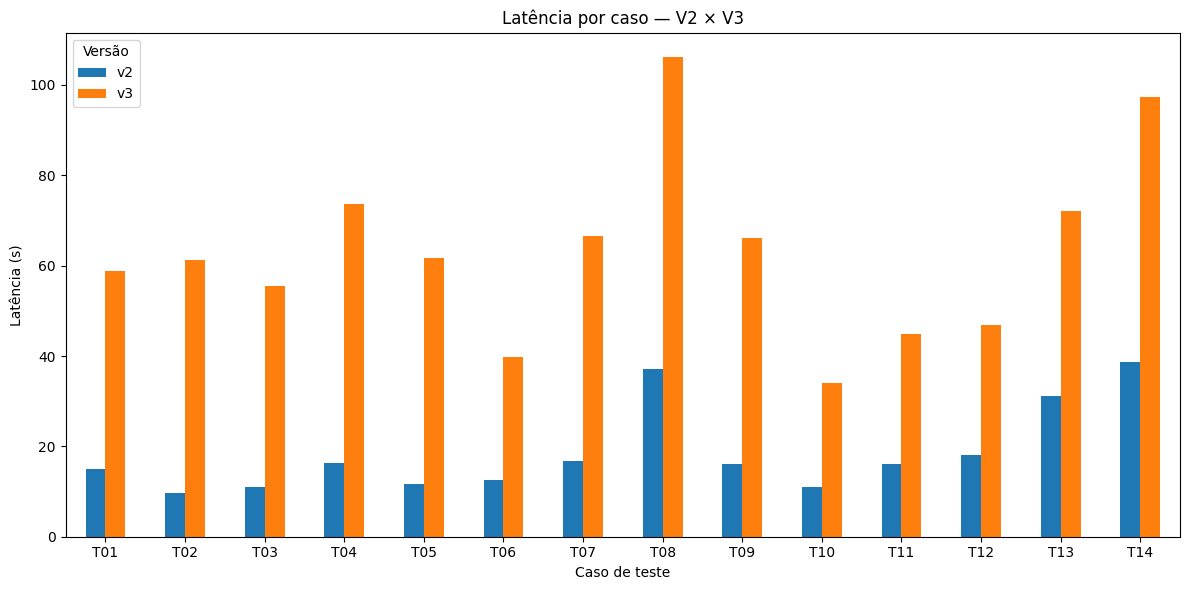

In [191]:
# ============================================================
# H.36 — LATÊNCIA POR CASO — V2 × V3
# ============================================================

import matplotlib.pyplot as plt

df_latencia = (
    df_benchmark
    .pivot(
        index="ID",
        columns="VERSAO",
        values="LATENCIA_S"
    )
    .reindex(
        [f"T{i:02d}" for i in range(1, 15)]
    )
)

ax = df_latencia.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title(
    "Latência por caso — V2 × V3"
)

ax.set_xlabel(
    "Caso de teste"
)

ax.set_ylabel(
    "Latência (s)"
)

ax.legend(
    title="Versão"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()
plt.show()

### Modos de falha observados

A comparação não foi limitada à taxa de aprovação. As respostas e os
rastros de execução foram examinados para identificar modos de falha
introduzidos ou evidenciados pela arquitetura multiagente.

Foram observados:

- **Sobre-abstenção:** em T01 e T02, a V3 recuperou os elementos
  esperados pelo gabarito, mas classificou a informação como
  insuficiente devido a requisitos adicionais de cobertura ou
  exaustividade. Em T01 foram recuperadas 444.266 notificações e,
  em T02, semana 15 e 21.470 notificações, mas ambos os casos foram
  reprovados pelo mecanismo automático devido à marcação de
  informação insuficiente.

- **Perda de informação durante a recuperação/contrato:** em T08,
  o Supervisor reconheceu corretamente a consulta como composta e
  planejou as dimensões relevantes, mas indicadores necessários das
  dimensões temporal e geográfica não foram preservados no contrato
  de evidências.

- **Falha multidimensional:** em T14, a V3 recuperou corretamente
  a evidência clínica referente aos óbitos, mas não recuperou a
  distribuição de sorotipos específica desse subconjunto. A resposta
  final, por isso, recusou a comparação solicitada.

- **Resposta sem suporte explícito nas evidências recuperadas:** em
  T11, a V2 forneceu uma resposta para o estado de São Paulo sem que
  a evidência recuperada sustentasse explicitamente esse total,
  enquanto a V3 reconheceu a insuficiência da evidência disponível.

- **Falha de recuperação na V2:** em T02 e T03, a V2 declarou
  informação insuficiente. A V3 conseguiu recuperar os elementos
  esperados em ambos os casos, embora tenha apresentado
  sobre-abstenção em T02.

Não foram observados erros técnicos de execução nas 28 execuções do
benchmark final. Também não foram observados laços de transferência,
roteamento para agentes não previstos ou execução fora da sequência
definida pela arquitetura.

### Síntese quantitativa

Nos 11 casos com verificação automática, a V2 obteve 7 aprovações
(63,64%) e a V3 obteve 8 aprovações (72,73%). Esses valores representam
o resultado bruto do mecanismo de verificação congelado e devem ser
interpretados em conjunto com a análise qualitativa das respostas e
dos rastros de execução.

A inspeção dos casos mostrou que a taxa automática não captura
integralmente o comportamento das arquiteturas. Em T01 e T02, por
exemplo, a V3 recuperou os elementos esperados pelo gabarito, mas
marcou a informação como insuficiente, caracterizando
sobre-abstenção. Em contrapartida, a V3 apresentou resultados
favoráveis em casos como T03, T11 e T12, nos quais a V2 não atendeu
ao critério automático.

Considerando os 14 casos do experimento, a latência total foi de
261,68 s para a V2 e 885,41 s para a V3. A latência média passou de
18,69 s para 63,24 s, correspondendo a uma razão aproximada de
3,38 vezes. As medianas foram, respectivamente, 16,14 s e 61,52 s.

A V2 realizou 40 chamadas ao modelo ao longo dos 14 casos, média de
2,86 por consulta, enquanto a V3 realizou 42 chamadas, média de 3,00.
A diferença no número de chamadas ao LLM foi, portanto, pequena em
relação à diferença observada de latência. Em relação às ferramentas,
a V2 realizou 16 chamadas, média de 1,14 por consulta, e a V3 realizou
28, média de 2,00.

Os resultados evidenciam um trade-off. Nesta execução, a arquitetura
multiagente apresentou maior taxa bruta de aprovação automática e
tornou explícitas as etapas de planejamento, investigação de
evidências e análise, aumentando a observabilidade do processo.
Entretanto, apresentou latência substancialmente maior e novos modos
de falha, como sobre-abstenção e perda de evidências em consultas
compostas. Considerando o número reduzido de casos e uma única
execução final por consulta, esses resultados devem ser tratados como
evidência descritiva, e não como demonstração de superioridade geral
de uma arquitetura.


In [195]:
# ============================================================
# H.38 — AVALIAÇÃO MANUAL DOS CASOS INTERPRETATIVOS
# ============================================================

avaliacao_manual = pd.DataFrame([
    {
        "CASO": "T09",
        "VERSAO": "v2",
        "C1": True,
        "C2": True,
        "C3": True,
        "C4": True,
        "ATENDIMENTO": "Atende",
        "OBSERVACAO": (
            "Identifica 93,36% de ausência e restringe "
            "a interpretação aos registros com sorotipo informado."
        )
    },
    {
        "CASO": "T09",
        "VERSAO": "v3",
        "C1": True,
        "C2": True,
        "C3": True,
        "C4": True,
        "ATENDIMENTO": "Atende",
        "OBSERVACAO": (
            "Explicita ausência, denominador, escopo temporal "
            "e limitações de comparação entre UFs."
        )
    },

    {
        "CASO": "T13",
        "VERSAO": "v2",
        "C1": True,
        "C2": False,
        "C3": False,
        "C4": True,
        "ATENDIMENTO": "Parcial",
        "OBSERVACAO": (
            "Abstém-se com segurança, mas não explica o subconjunto "
            "para o qual existe evidência de predominância."
        )
    },
    {
        "CASO": "T13",
        "VERSAO": "v3",
        "C1": True,
        "C2": True,
        "C3": True,
        "C4": True,
        "ATENDIMENTO": "Atende",
        "OBSERVACAO": (
            "Rejeita a generalização para todos os casos e explica "
            "que DENV-2 predomina apenas entre registros com "
            "sorotipo informado."
        )
    },

    {
        "CASO": "T14",
        "VERSAO": "v2",
        "C1": True,
        "C2": True,
        "C3": True,
        "C4": True,
        "ATENDIMENTO": "Atende",
        "OBSERVACAO": (
            "Integra febre e DENV-2 no subconjunto de óbitos "
            "e explicita as limitações de cobertura."
        )
    },
    {
        "CASO": "T14",
        "VERSAO": "v3",
        "C1": True,
        "C2": False,
        "C3": True,
        "C4": True,
        "ATENDIMENTO": "Parcial",
        "OBSERVACAO": (
            "Recupera corretamente a dimensão clínica, mas não "
            "preserva a evidência de sorotipo específica dos óbitos."
        )
    }
])

display(avaliacao_manual)

,CASO,VERSAO,C1,C2,C3,C4,ATENDIMENTO,OBSERVACAO
0,T09,v2,True,True,True,True,Atende,"Identifica 93,36% de ausência e restringe a in..."
1,T09,v3,True,True,True,True,Atende,"Explicita ausência, denominador, escopo tempor..."
2,T13,v2,True,False,False,True,Parcial,"Abstém-se com segurança, mas não explica o sub..."
3,T13,v3,True,True,True,True,Atende,Rejeita a generalização para todos os casos e ...
4,T14,v2,True,True,True,True,Atende,Integra febre e DENV-2 no subconjunto de óbito...
5,T14,v3,True,False,True,True,Parcial,"Recupera corretamente a dimensão clínica, mas ..."


# I. Novos modos de falha

A inspeção das respostas e dos traces mostrou que a decomposição
multiagente tornou algumas falhas mais localizáveis, mas também
introduziu novos comportamentos. Não houve erro técnico de execução
nas 28 execuções do benchmark.

| Modo de falha | Ocorreu? | Caso e evidência do trace |
|---|---|---|
| Roteamento para o agente errado | Não observado | O fluxo permaneceu fixo e os agentes previstos foram executados na ordem definida. |
| Agente respondendo fora do escopo | Não observado como modo dominante | O Supervisor não produziu resposta factual e o Analista permaneceu dependente do contrato. |
| Pergunta composta atendida por um só agente | Não | T08 foi reconhecido pelo Supervisor como consulta composta com dimensões temporal, geográfica e clínica. |
| Achado correto perdido na agregação | Parcialmente | Em T08, indicadores temporais e geográficos relevantes não chegaram adequadamente ao contrato; a perda ocorreu antes do Analista. Em T14, a evidência virológica específica dos óbitos não foi preservada. |
| Laço de transferências sem convergência | Não | A arquitetura foi deliberadamente acíclica; não há retorno do Analista ao Agente de Evidências. |
| Plano que ignora parte da pergunta | Não em T08 | O Supervisor identificou as três dimensões; a falha ocorreu posteriormente na recuperação/seleção das evidências. |
| Sobre-abstenção | Sim | T01 e T02: a V3 recuperou os elementos esperados pelo gabarito, mas marcou a informação como insuficiente. |
| Objetivo marcado como atendido com evidência pouco específica | Sim | Em T08, o contrato marcou os três objetivos como atendidos apesar de não preservar indicadores necessários das dimensões temporal e geográfica. |
| Resposta sem suporte explícito nas evidências recuperadas | Sim, na V2 | T11: a V2 forneceu uma resposta para o estado de São Paulo, enquanto a V3 explicitou ausência de evidência estadual suficiente no material recuperado. |
| Falha multidimensional | Sim | Em T14, a V3 preservou a evidência clínica, mas não recuperou/preservou adequadamente a evidência de sorotipo específica do subconjunto de óbitos. |

Esses resultados mostram que a rastreabilidade da V3 ajudou a
distinguir falhas de planejamento, recuperação, construção do contrato
e interpretação final. Entretanto, maior observabilidade não implica
necessariamente ausência de falhas: a decomposição também tornou
visíveis problemas de sobre-abstenção e perda de informação entre
etapas.


# J. Análise arquitetural

### J.1 Limitações resolvidas e limitações remanescentes

A divisão de responsabilidades aumentou principalmente a **observabilidade** do processo e tornou explícita a separação entre planejamento, recuperação de evidências e interpretação final. Essa estrutura permitiu localizar com maior precisão em qual etapa determinadas falhas ocorreram.

Em T11, por exemplo, a V3 distinguiu a evidência disponível para o município de São Paulo da informação solicitada para o estado e optou pela abstenção. Em T13, rejeitou a generalização da predominância de DENV-2 para todos os casos, explicando que a evidência disponível se restringia aos registros com sorotipo informado. A V3 também apresentou resultados automáticos favoráveis em T03 e T12, casos nos quais a V2 não atendeu ao critério de verificação.

A divisão de responsabilidades, entretanto, não eliminou falhas. Em T08, o Supervisor reconheceu a consulta como composta e elaborou objetivos para as dimensões envolvidas, mas informações necessárias das dimensões temporal e geográfica não foram preservadas no contrato de evidências. Em T14, a evidência clínica relativa aos óbitos foi recuperada, mas a evidência virológica específica desse subconjunto não chegou adequadamente à resposta. Também foi observada sobre-abstenção em T01 e T02: a V3 recuperou os elementos esperados pelo gabarito, mas ainda classificou a informação como insuficiente.

### J.2 Custo e latência

Considerando os 14 casos, a V2 totalizou 261,68 segundos e a V3 885,41 segundos. A latência média passou de 18,69 segundos na V2 para 63,24 segundos na V3, correspondendo a aproximadamente **3,38 vezes** a latência média da versão anterior. As medianas foram de 16,14 e 61,52 segundos, respectivamente.

A V2 realizou 40 chamadas ao LLM, com média de 2,86 por consulta, enquanto a V3 realizou 42 chamadas, média de 3,00. Assim, a diferença no número de chamadas ao modelo foi pequena quando comparada ao aumento observado na latência. A V3 também realizou 28 chamadas de ferramentas, contra 16 na V2, correspondendo a médias de 2,00 e 1,14 chamadas por consulta.

Esses resultados indicam que a decomposição multiagente introduziu custo operacional adicional. Entretanto, o experimento não foi desenhado para atribuir causalmente a diferença de latência a um único componente. Uma avaliação futura deveria medir separadamente recuperação, inferência, transferência de contexto e processamento de cada agente.

### J.3 Um agente poderia voltar a ser etapa de fluxo?

O Supervisor e o Agente de Evidências apresentam responsabilidades, critérios de sucesso e decisões observáveis que justificam sua separação experimental. Entretanto, operações como validação estrutural do contrato, cálculo de cobertura e verificações determinísticas não necessitam de autonomia e devem permanecer como etapas convencionais do fluxo.

Da mesma forma, a ontologia foi mantida como recurso semântico utilizado pela arquitetura, e não como um agente. Essa decisão evita atribuir agência a um componente cuja função é fornecer conceitos, relações e restrições semânticas.

### J.4 Avaliação da hipótese

A hipótese foi **parcialmente sustentada**. A V3 aumentou a rastreabilidade do processo: os traces permitiram distinguir falhas de planejamento, recuperação, construção do contrato e interpretação final. Também foram observados comportamentos desejáveis de controle de escopo em T11 e T13.

Nesta execução, a V3 apresentou ainda maior taxa bruta de aprovação nos casos automáticos: 8 de 11 casos (72,73%), contra 7 de 11 (63,64%) na V2. Esse resultado, contudo, não é suficiente para concluir superioridade geral da arquitetura multiagente, pois o conjunto contém apenas 11 casos automáticos, cada consulta foi executada uma única vez nesta comparação e foram observados novos modos de falha.

Em particular, a V3 apresentou sobre-abstenção em T01 e T02, perda de informação em consulta composta em T08 e falha de integração multidimensional em T14. Além disso, sua latência média foi aproximadamente 3,38 vezes maior.

Assim, o experimento fornece evidência favorável à hipótese quanto à **rastreabilidade e observabilidade** e, nesta execução, também apresenta maior taxa bruta de aprovação automática. Entretanto, não fornece evidência suficiente para afirmar que a V3 seja globalmente mais correta, robusta ou eficiente que a V2.

### Observação sobre variabilidade

Durante a preparação da versão final do experimento, uma nova execução
completa do notebook produziu diferenças em alguns resultados em
relação à execução exploratória anterior. A análise apresentada nesta
entrega utiliza exclusivamente os resultados da execução final
preservada no notebook.

Essa observação reforça uma limitação do desenho experimental:
uma única execução por caso não permite estimar a estabilidade das
respostas produzidas por componentes baseados em LLM. Em trabalhos
futuros, cada caso deverá ser executado múltiplas vezes, permitindo
medir não apenas desempenho médio, mas também variabilidade e
consistência entre execuções.

### Pergunta obrigatória — qual versão levar para uso real?

Se fosse necessário selecionar uma das arquiteturas para avançar em direção a um cenário de uso real, eu levaria a **V3 para uma próxima etapa de validação controlada**, principalmente por sua maior rastreabilidade, explicitação do escopo das evidências e capacidade de tornar observáveis as decisões intermediárias. Nesta execução, ela também apresentou maior taxa bruta de aprovação automática e comportamento adequado em casos importantes de controle de escopo, como T11 e T13.

Essa escolha, entretanto, **não significa que a V3 esteja pronta para implantação em produção**. A maior latência, a sobre-abstenção observada e as perdas de evidência em consultas compostas e multidimensionais ainda precisam ser investigadas.

Para sustentar uma decisão de implantação seriam necessárias evidências adicionais: um conjunto maior e mais diverso de consultas; múltiplas execuções de cada caso para estimar variabilidade; avaliação independente da fidelidade das respostas às evidências; maior cobertura de consultas compostas, pressupostos falsos e informação ausente; e medições controladas de custo e latência. Também seria necessário avaliar sistematicamente a estabilidade dos resultados entre execuções, uma vez que sistemas baseados em LLM podem apresentar variação mesmo quando submetidos ao mesmo conjunto de testes.


## Conclusão do experimento

O experimento mostra que decompor o sistema em agentes especializados não produz automaticamente maior acurácia. A principal contribuição observada da v3 foi tornar o processo mais auditável: o plano, as evidências, as limitações e a etapa em que uma informação se perdeu ficaram explícitos. Em contrapartida, a arquitetura apresentou maior latência, sobre-abstenção e perdas de evidência em algumas consultas multidimensionais.

Assim, os resultados devem ser interpretados como evidência exploratória sobre **trade-offs arquiteturais**, e não como demonstração de superioridade de uma versão. O benchmark pequeno, com execução única por caso, é adequado para identificar comportamentos e modos de falha, mas não para estimar desempenho populacional ou estabilidade estatística.


---

# Checklist antes da entrega

- [x] Estrutura herdada reunida no início, sem alterações não declaradas.
- [x] Limitação da v2 apontada com evidência, e hipótese definida antes da avaliação final.
- [x] Pelo menos dois agentes, cada um com escopo, ferramentas/insumos, instrução e critério próprios.
- [x] Padrão de organização escolhido e justificado pelo problema.
- [x] Contrato entre agentes descrito, incluindo o que cada um enxerga do contexto.
- [x] Skills descartadas com justificativa e planejamento explícito adotado.
- [x] Trace responde a caminho, perda de informação e custo/latência.
- [x] Métricas de custo por etapa e totais registradas.
- [x] v2 reexecutada na mesma sessão e com o mesmo modelo da v3.
- [x] Comparação por caso acompanhada de plano/trace nos casos diagnósticos.
- [x] Novos modos de falha verificados.
- [x] Pergunta obrigatória respondida.
- [x] Benchmark final concluído sem erros técnicos e resultados salvos em checkpoint.
- [x] Nenhuma chave de API armazenada no notebook.

**Observação para submissão:** o notebook deve ser salvo com as saídas do benchmark e do gráfico H.36 visíveis. Não é necessário executar novamente as chamadas ao modelo se as saídas finais já estiverem preservadas.
